In [1]:
# ... existing code ...
# Read the binary file
with open('mmapped_impl_test.bin', 'rb') as f:
    # Reading the file produces a bytes object.
    # Converting it to a list creates an array of integers (0s and 1s).
    data_array = list(f.read())

# Verify the data
print(f"Read {len(data_array)} bytes")
print(f"First 10 values: {data_array[:10]}")

Read 343067 bytes
First 10 values: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [3]:

def observe_slice(start, end):
    slice_to_observe = data_array[start:end]
    plt.plot([i * 20 / 1000.0 for i in range(0, len(slice_to_observe))], slice_to_observe)
    plt.xlabel('Approximate Time (ms)')


In [4]:
starts = []
ends = []

start_index = 0
last_one = 0
i = 0
while start_index < len(data_array):
    while start_index < len(data_array) and data_array[start_index] != 1:
        start_index += 1

    if start_index == len(data_array):
        break
    starts.append(start_index)
    last_one = start_index
    for i in range(start_index, len(data_array)):
        if data_array[i] == 1:
            last_one = i

        if i - last_one > 3500:
            ends.append(last_one)
            break
    start_index = i + 1



In [5]:
len(starts), len(ends)

(4, 4)

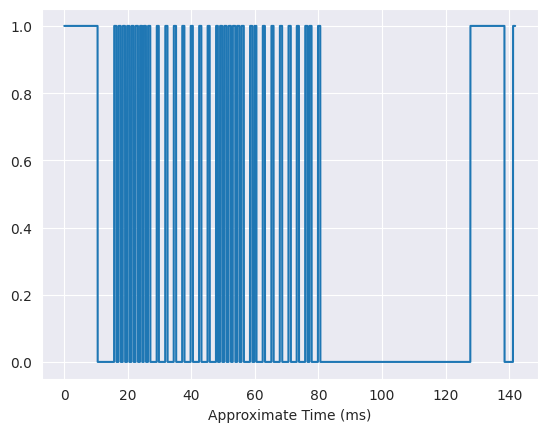

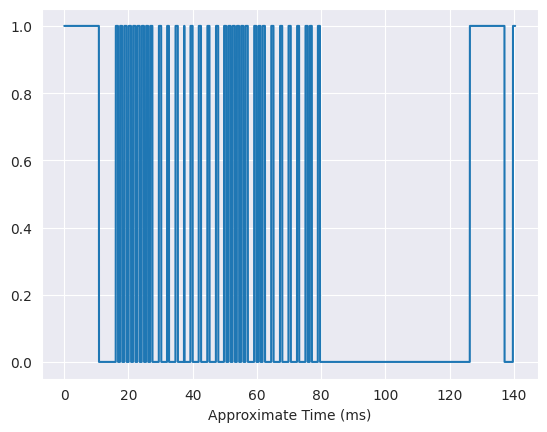

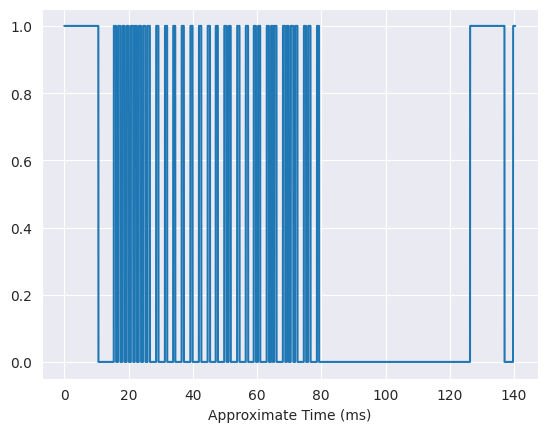

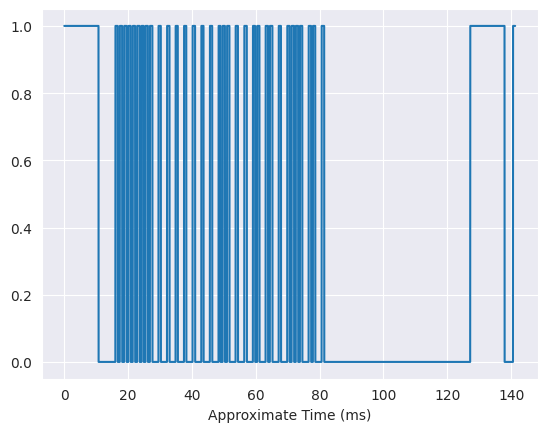

In [6]:
for i in range(len(starts)):
    observe_slice(starts[i], ends[i])
    plt.show()

In [7]:
pulses = []

for i in range(0, len(starts), 1):
    last = 0
    count = 0
    for d in range(starts[i], ends[i]):
        if last == 0 and data_array[d] == 1:
            count += 1
        last = data_array[d]
    pulses.append(count)

In [8]:
pulses

[36, 36, 36, 36]

In [22]:
with open('button_signals.bin', 'rb') as f:
    # Reading the file produces a bytes object.
    # Converting it to a list creates an array of integers (0s and 1s).
    signal_array = f.read()


In [23]:
total_signals = int.from_bytes(signal_array[:8], byteorder="big", signed=True)
total_signals

34

In [24]:
import struct

In [25]:
pulse_length, = struct.unpack('>Q', signal_array[:8])
vals = struct.unpack('>' + ''.join(['Q' for i in range(pulse_length * 2)]), signal_array[8:8 + 16 * pulse_length])

In [26]:
[(vals[i], vals[i + 1]) for i in range(0, len(vals), 2)]

[(4126, 4477),
 (589, 533),
 (607, 537),
 (573, 521),
 (602, 536),
 (604, 537),
 (586, 521),
 (600, 543),
 (687, 473),
 (543, 1660),
 (618, 1644),
 (584, 1675),
 (589, 1661),
 (603, 1642),
 (603, 1671),
 (573, 1674),
 (588, 1660),
 (466, 525),
 (602, 529),
 (573, 536),
 (601, 536),
 (606, 519),
 (584, 536),
 (589, 1674),
 (584, 528),
 (600, 1659),
 (573, 1671),
 (606, 1754),
 (500, 1661),
 (570, 1666),
 (598, 1648),
 (602, 520),
 (602, 1654),
 (591, 5000)]

In [27]:
class Signal:
    def __init__(self, high, low):
        self.high = high
        self.low = low
    def __str__(self):
        return f"Signal(high={self.high}us, low={self.low}us)"
    def __repr__(self):
        return str(self)


In [28]:
i = 0
raw_signals = []
while i < len(signal_array):
    pulse_length, = struct.unpack('>Q', signal_array[i:i +8])
    i = i + 8
    data = struct.unpack('>' + ''.join(['Q' for i in range(pulse_length * 2)]), signal_array[i:i + 8 * pulse_length * 2])
    raw_signals.append(list(data))
    i = i + 8 * pulse_length * 2

In [29]:
signals = [[Signal(s[i], s[i + 1]) for i in range(0, len(s), 2)] for s in raw_signals]

<BarContainer object of 34 artists>

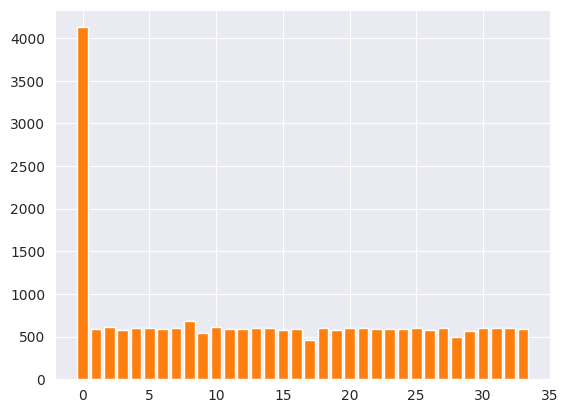

In [30]:
plt.bar([i for i in range(len(signals[0]))], [s.high for s in signals[0]])
plt.bar([i for i in range(len(signals[1]))], [s.high for s in signals[0]])

In [31]:
series = []
for i in range(len(signals)):
    for j in range(len(signals[i])):
        s = signals[i][j]
        series.append(pd.Series({"Pulse Set Id": i, "Pulse Index": j, "High Duration": s.high, "Low Duration": s.low }))
df  = pd.DataFrame(columns=["Pulse Set Id", "Pulse Index", "High Duration", "Low Duration"], data=series)
df["Expected Button Group"] = df["Pulse Set Id"].apply(lambda x: int(x / 4))

In [32]:
df


,Pulse Set Id,Pulse Index,High Duration,Low Duration,Expected Button Group
0,0,0,4126,4477,0
1,0,1,589,533,0
2,0,2,607,537,0
3,0,3,573,521,0
4,0,4,602,536,0
...,...,...,...,...,...
5979,175,29,607,1650,43
5980,175,30,608,1653,43
5981,175,31,577,1666,43
5982,175,32,590,1646,43


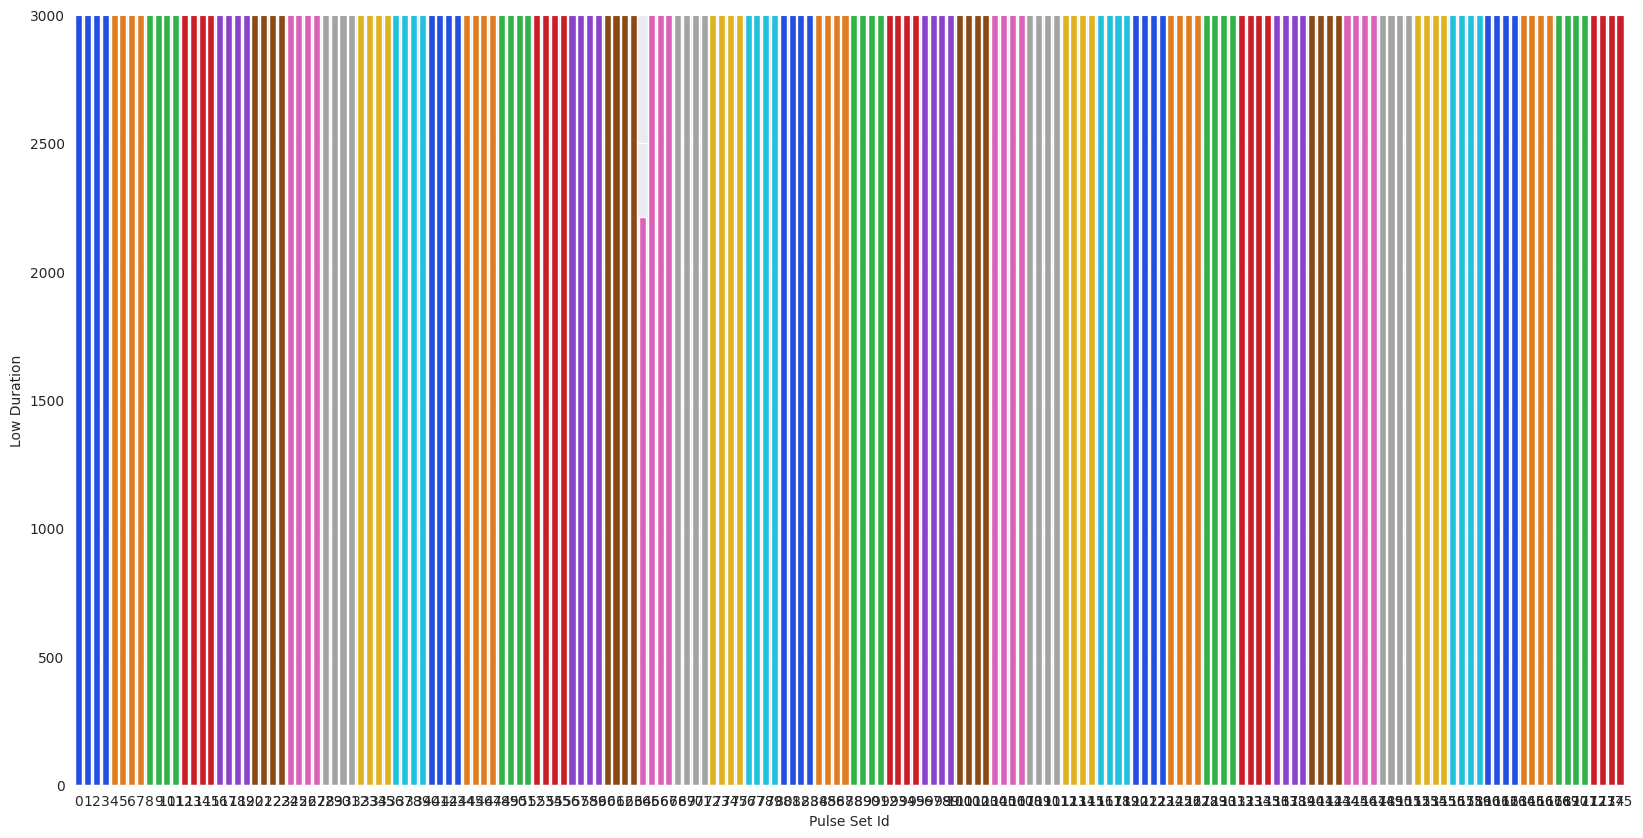

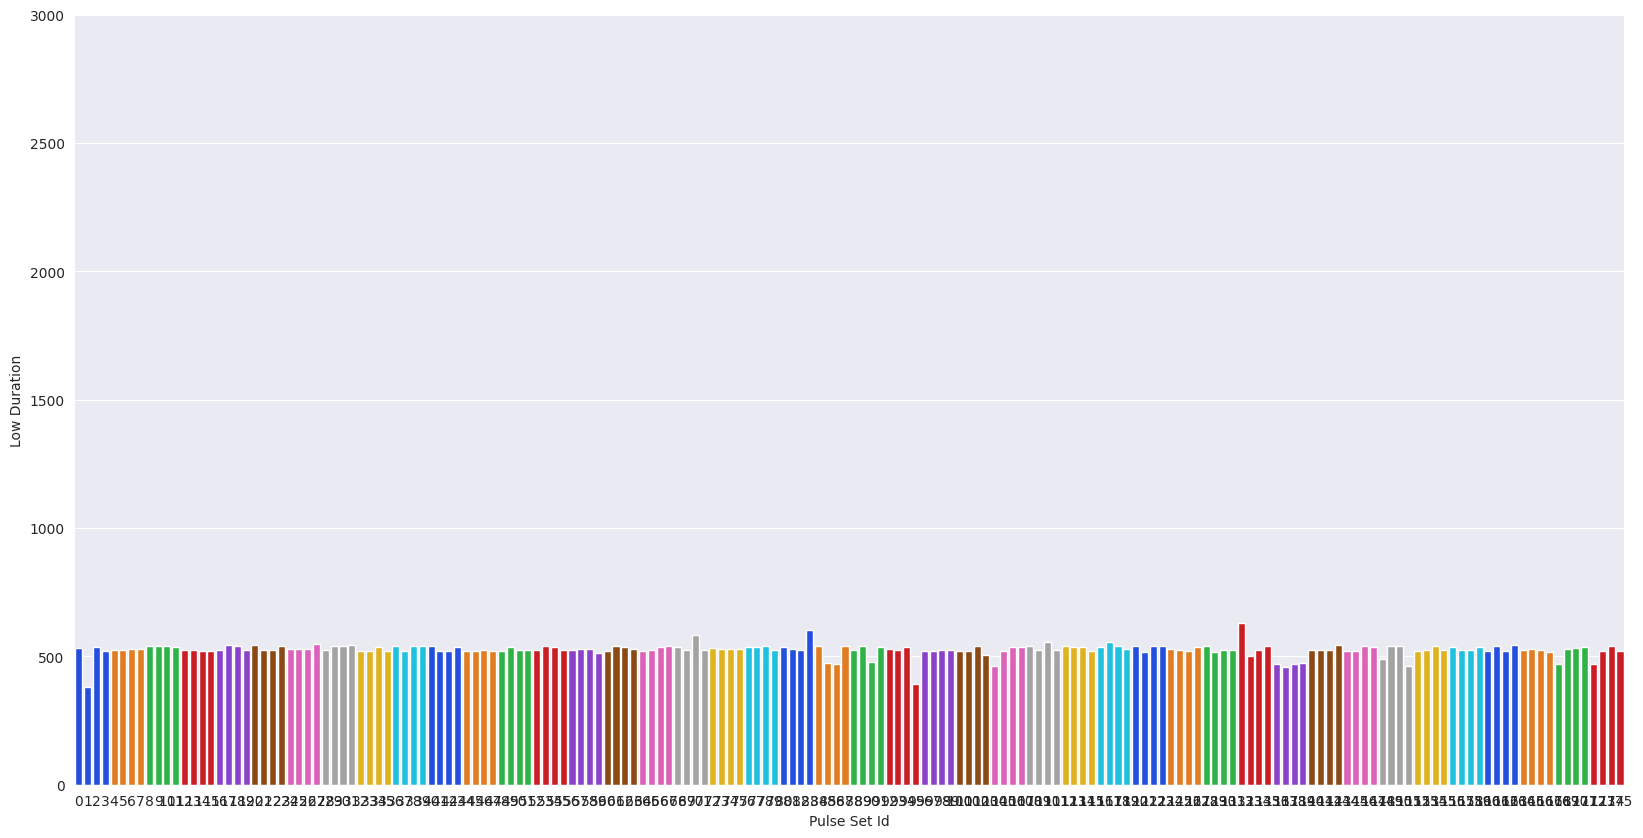

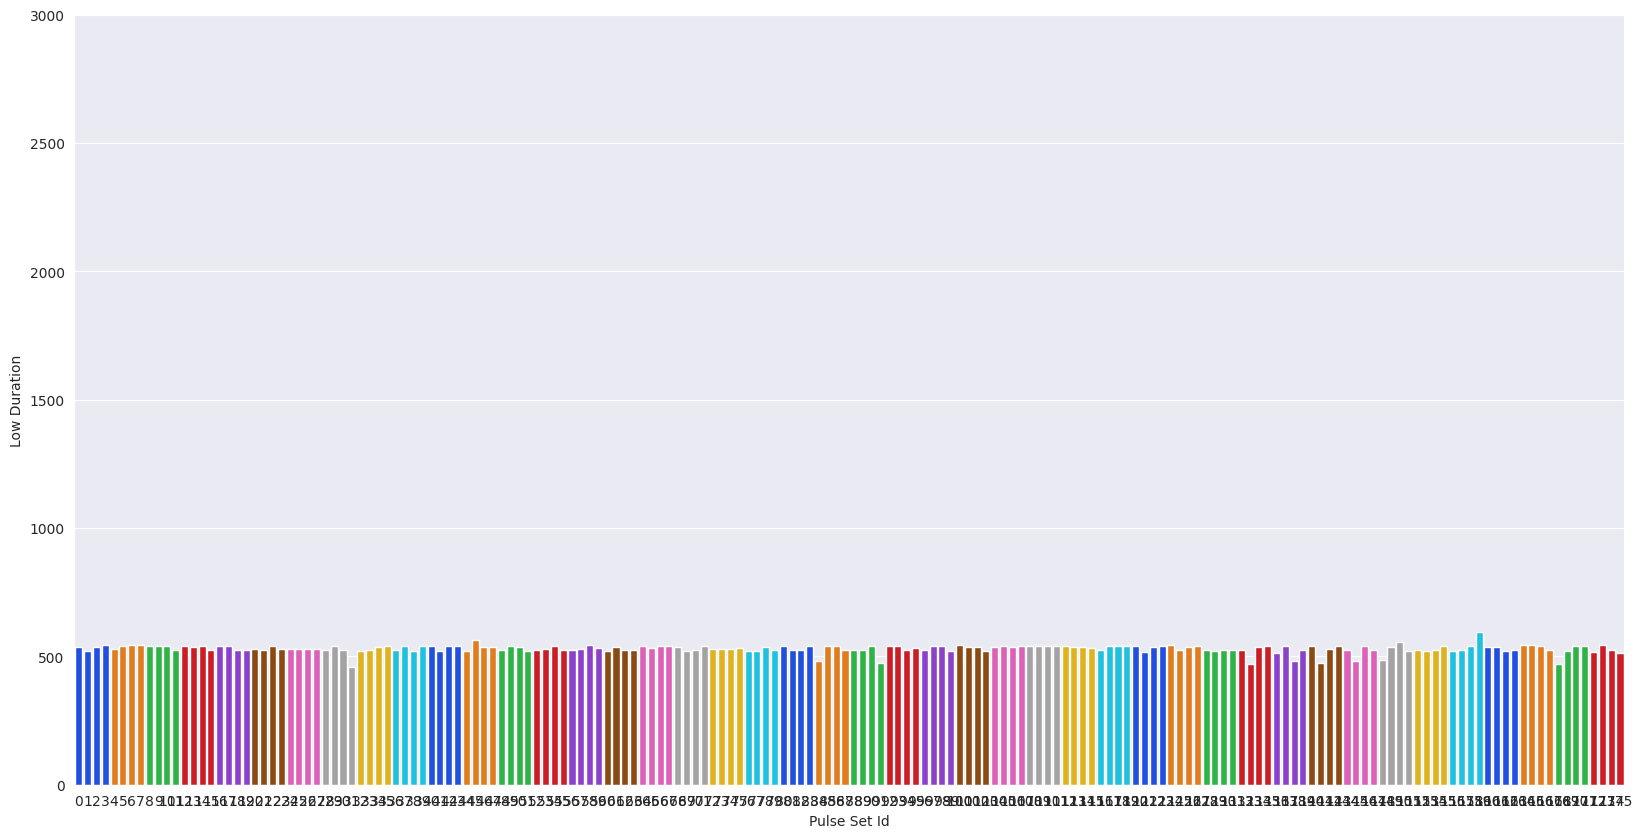

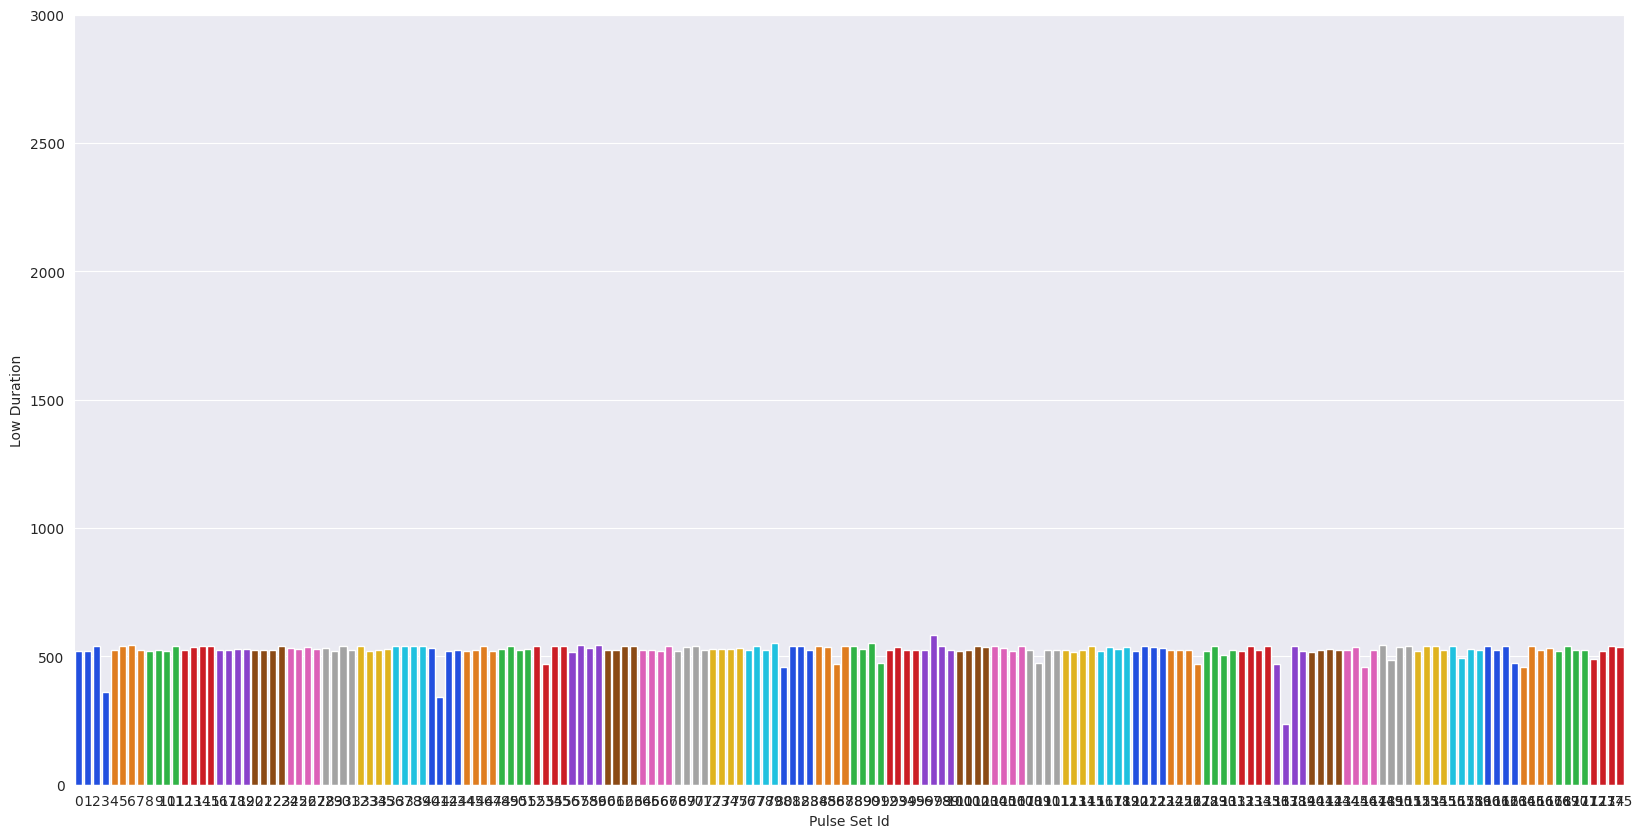

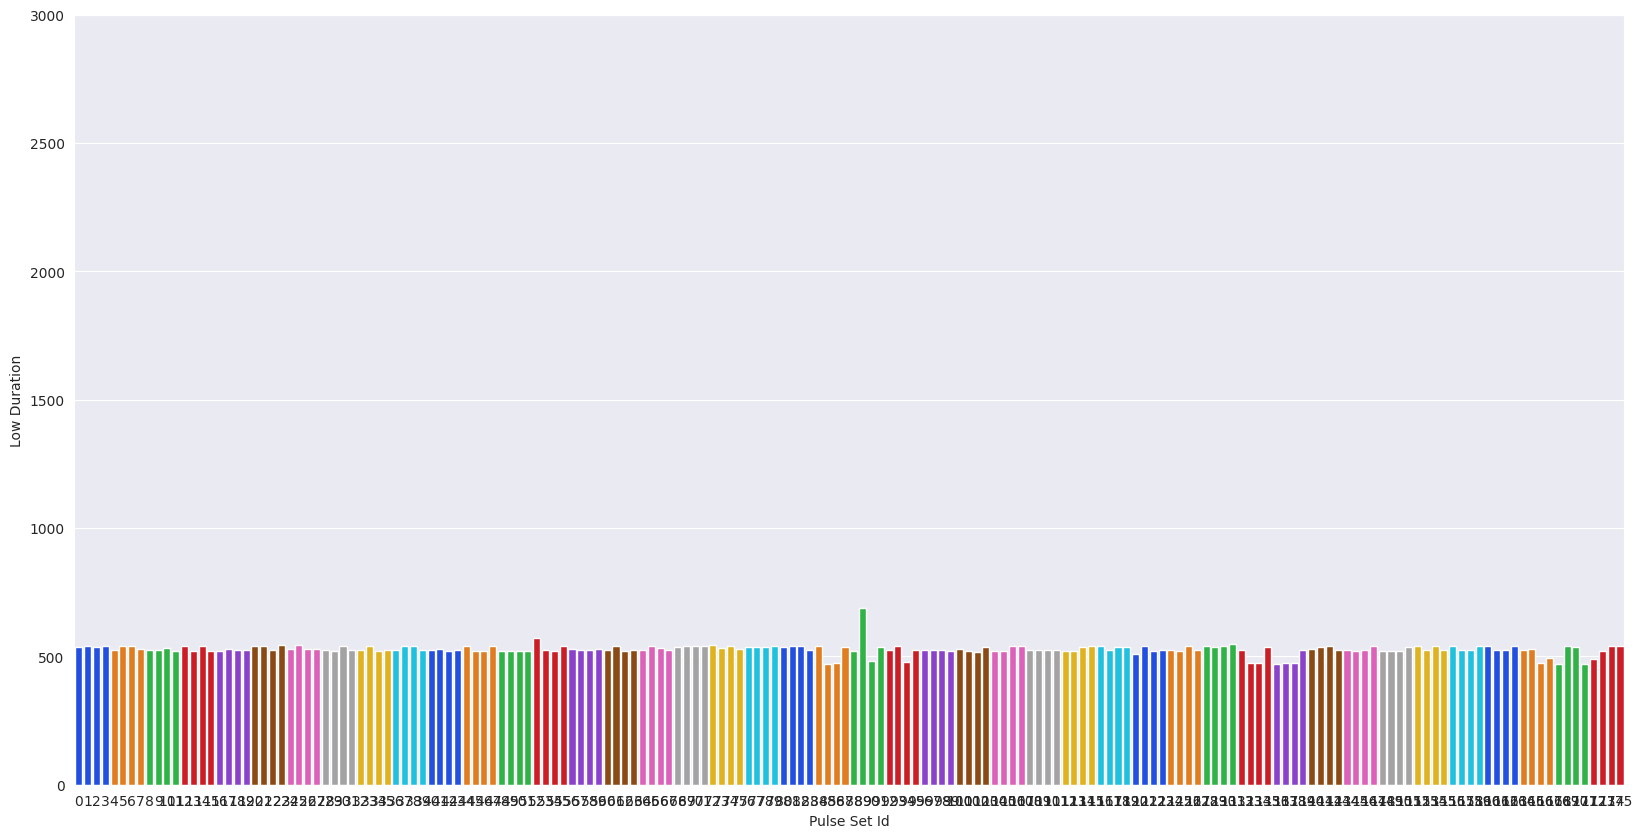

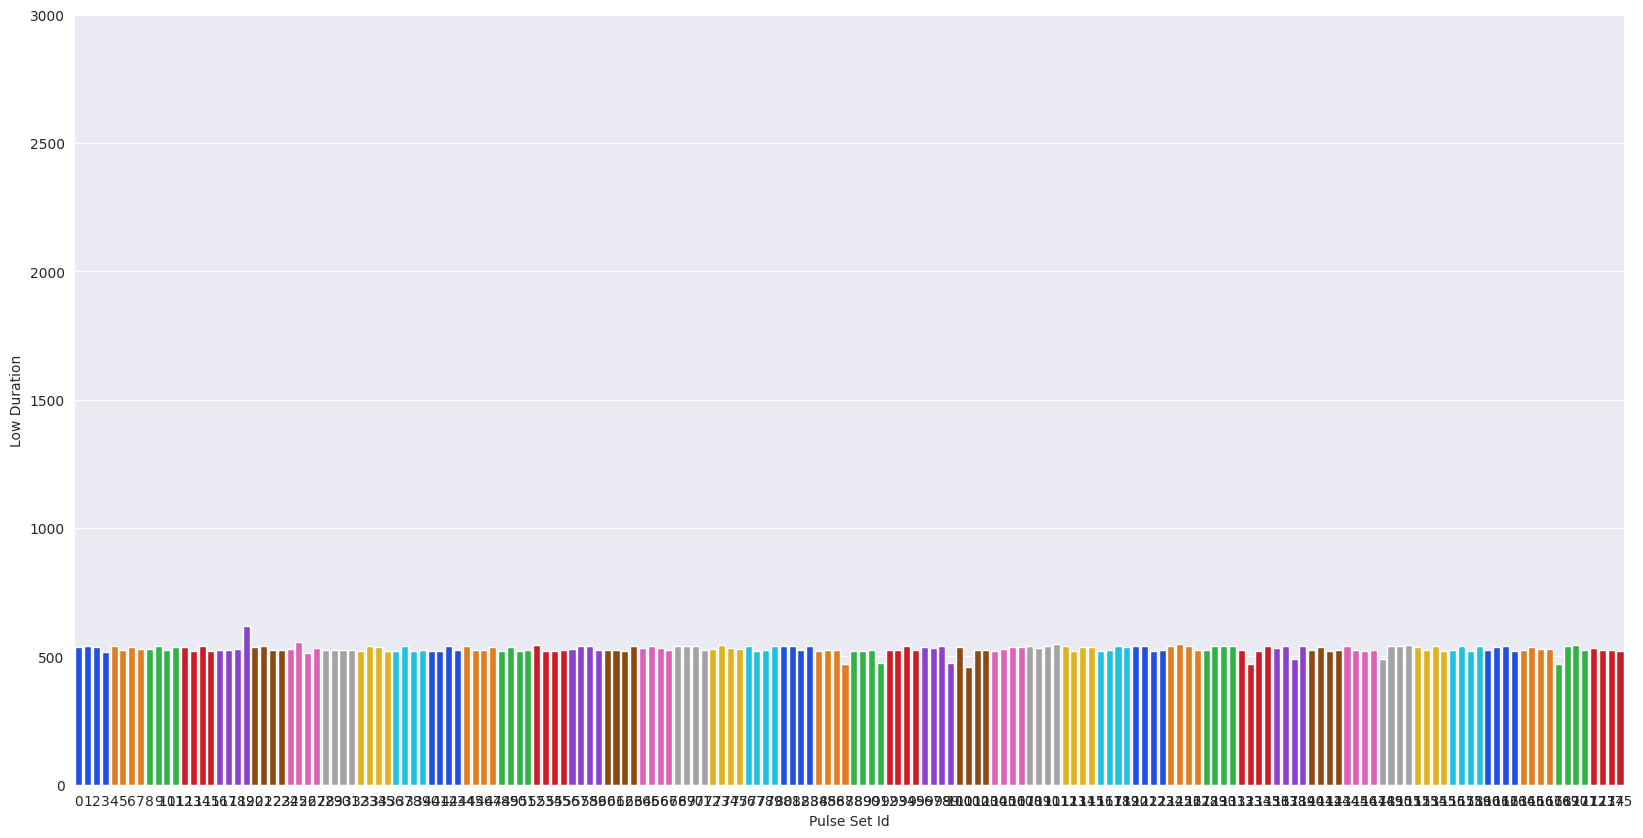

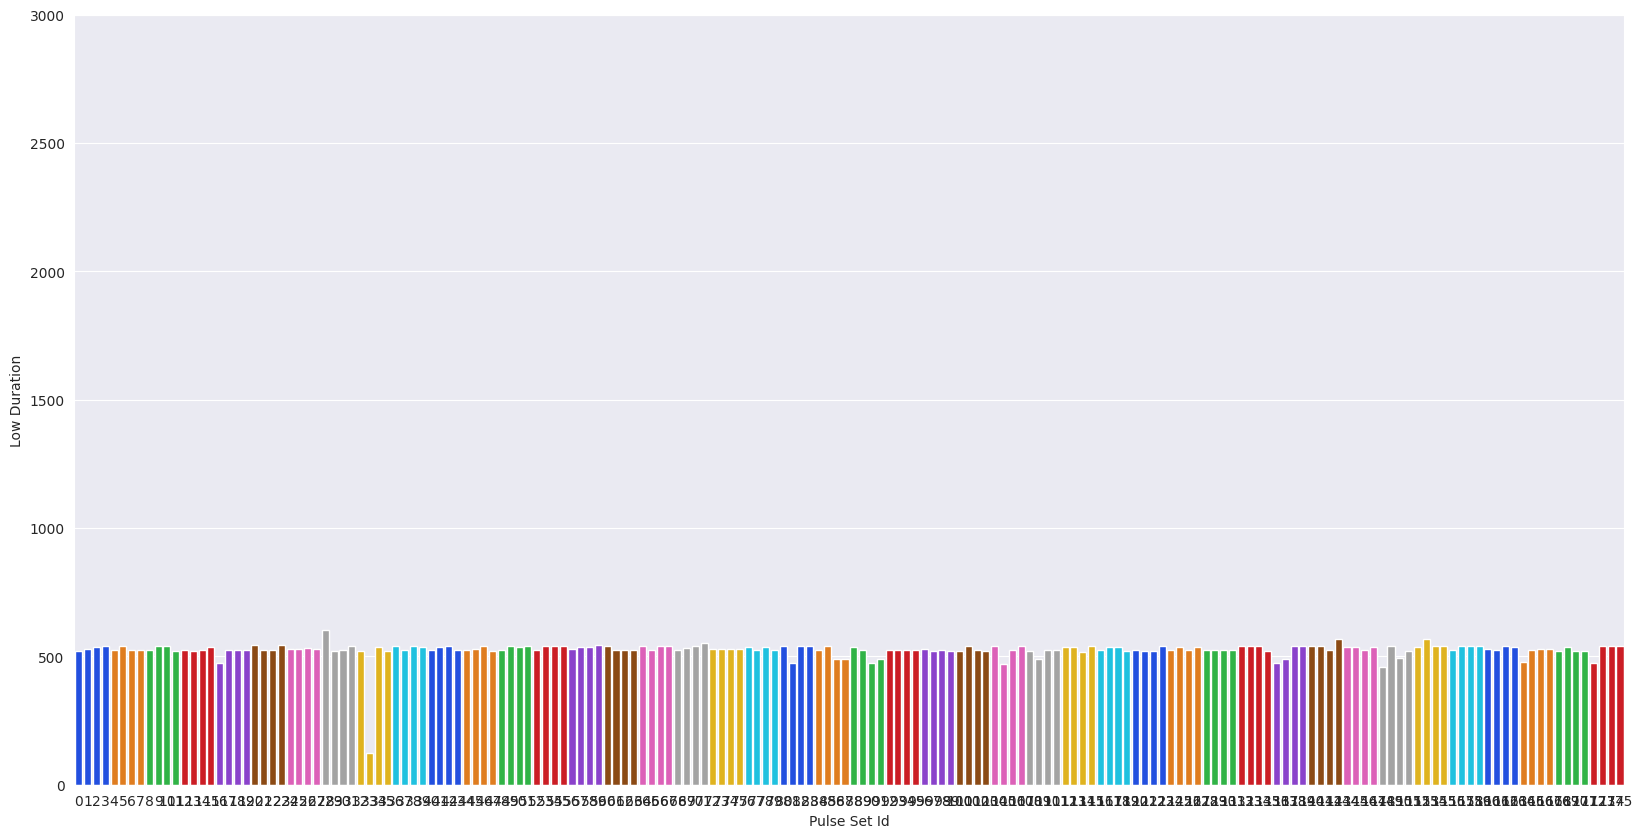

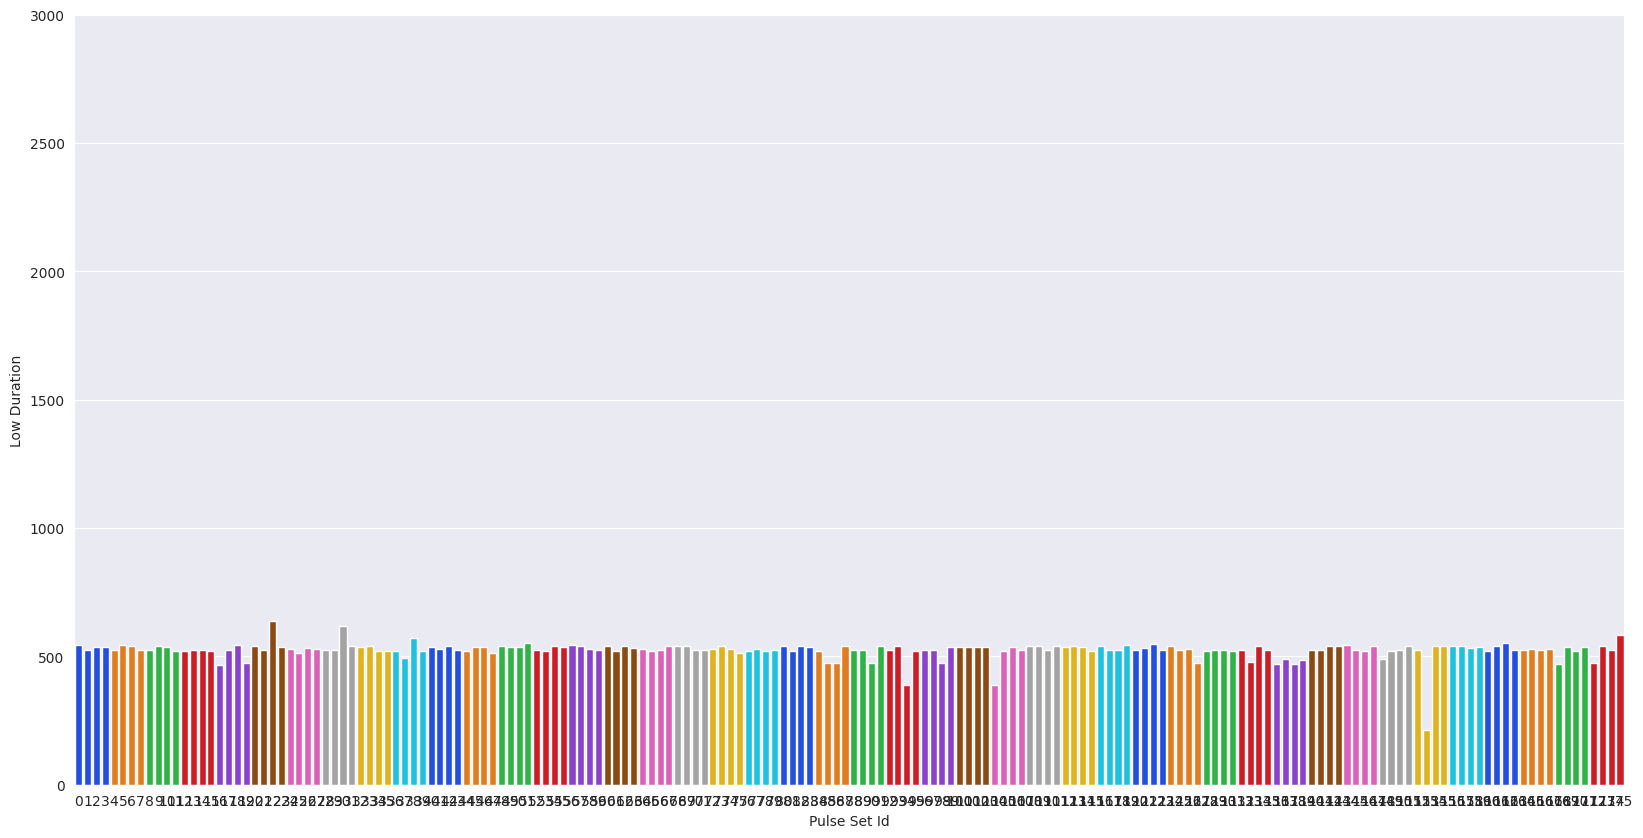

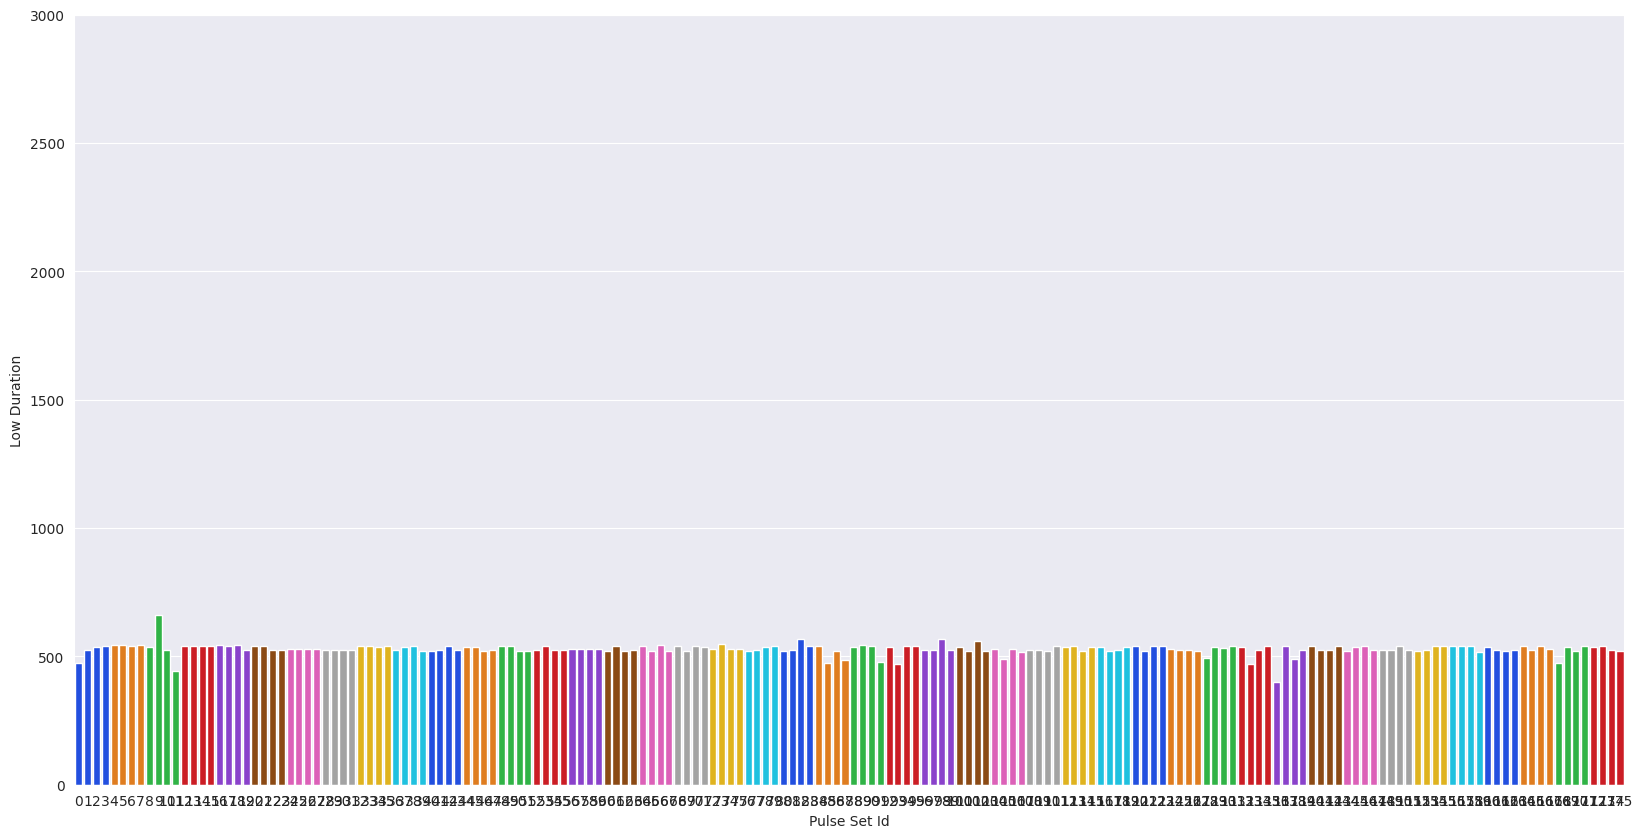

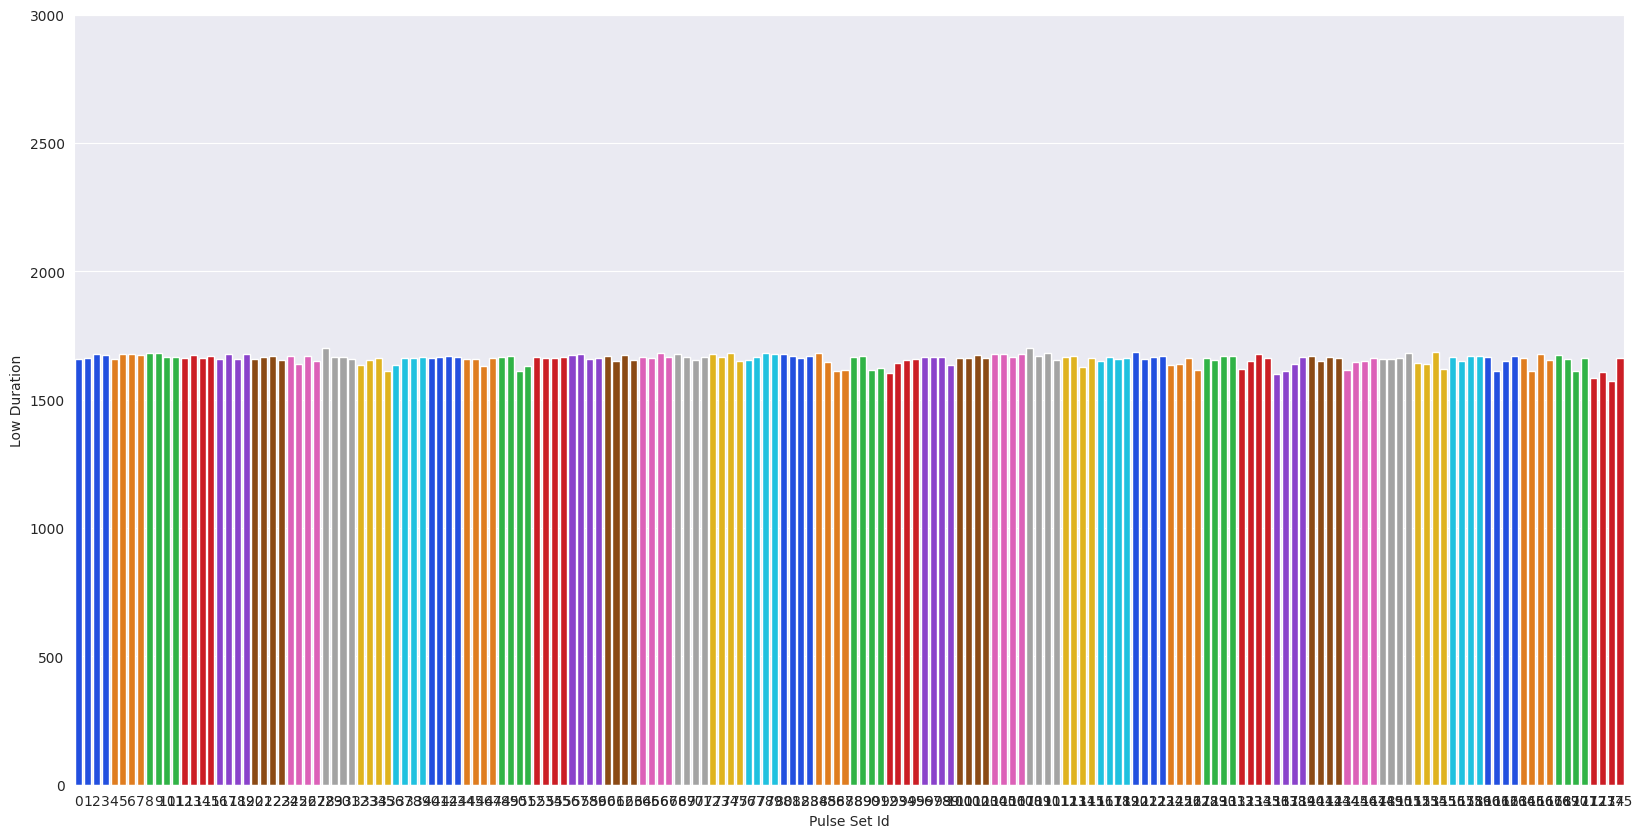

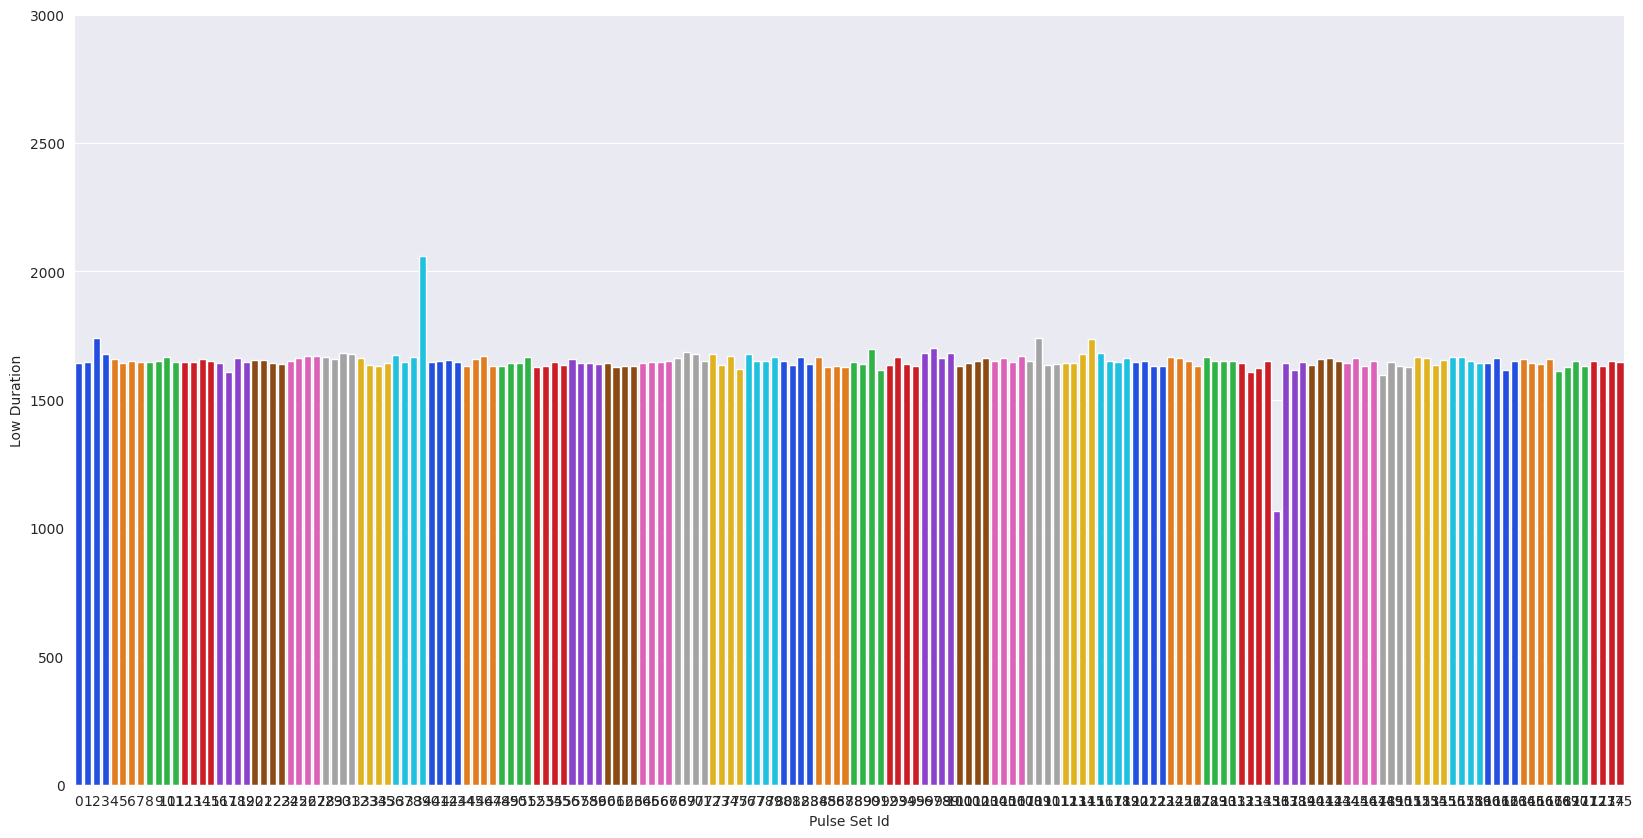

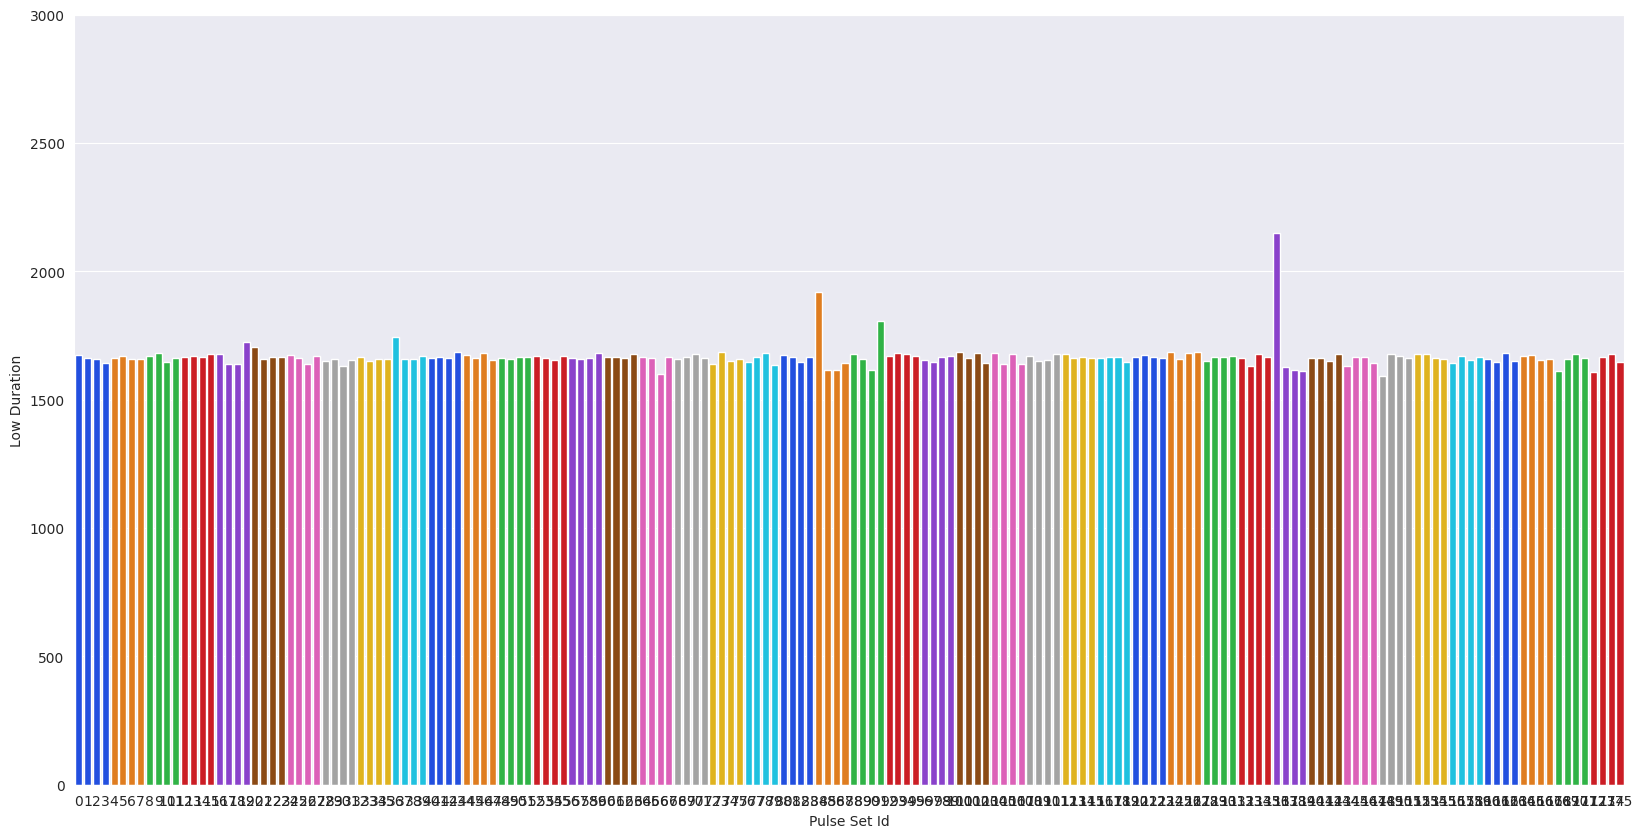

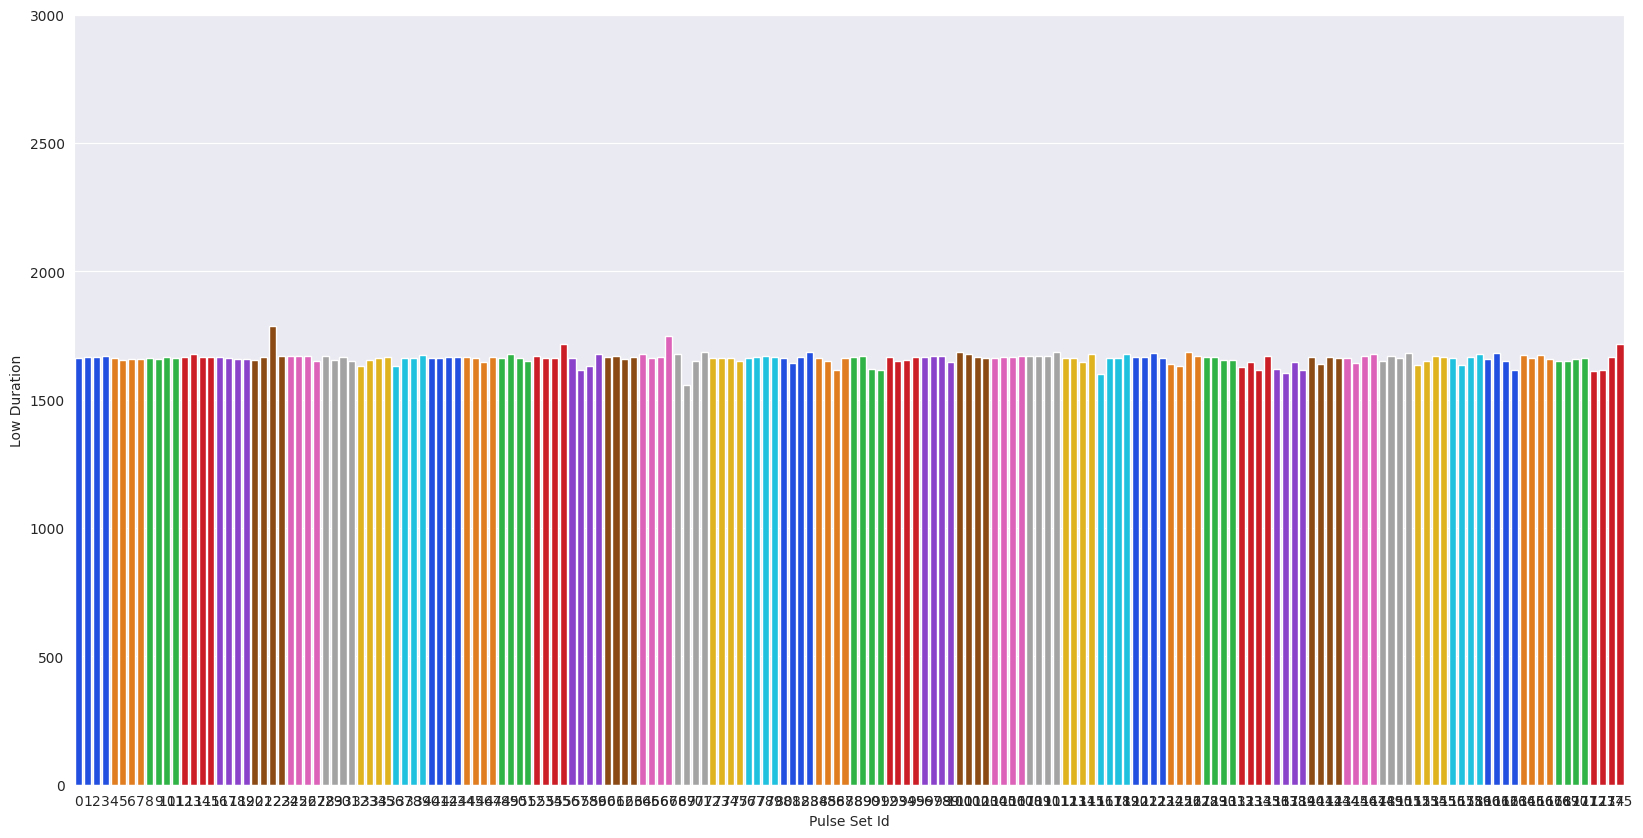

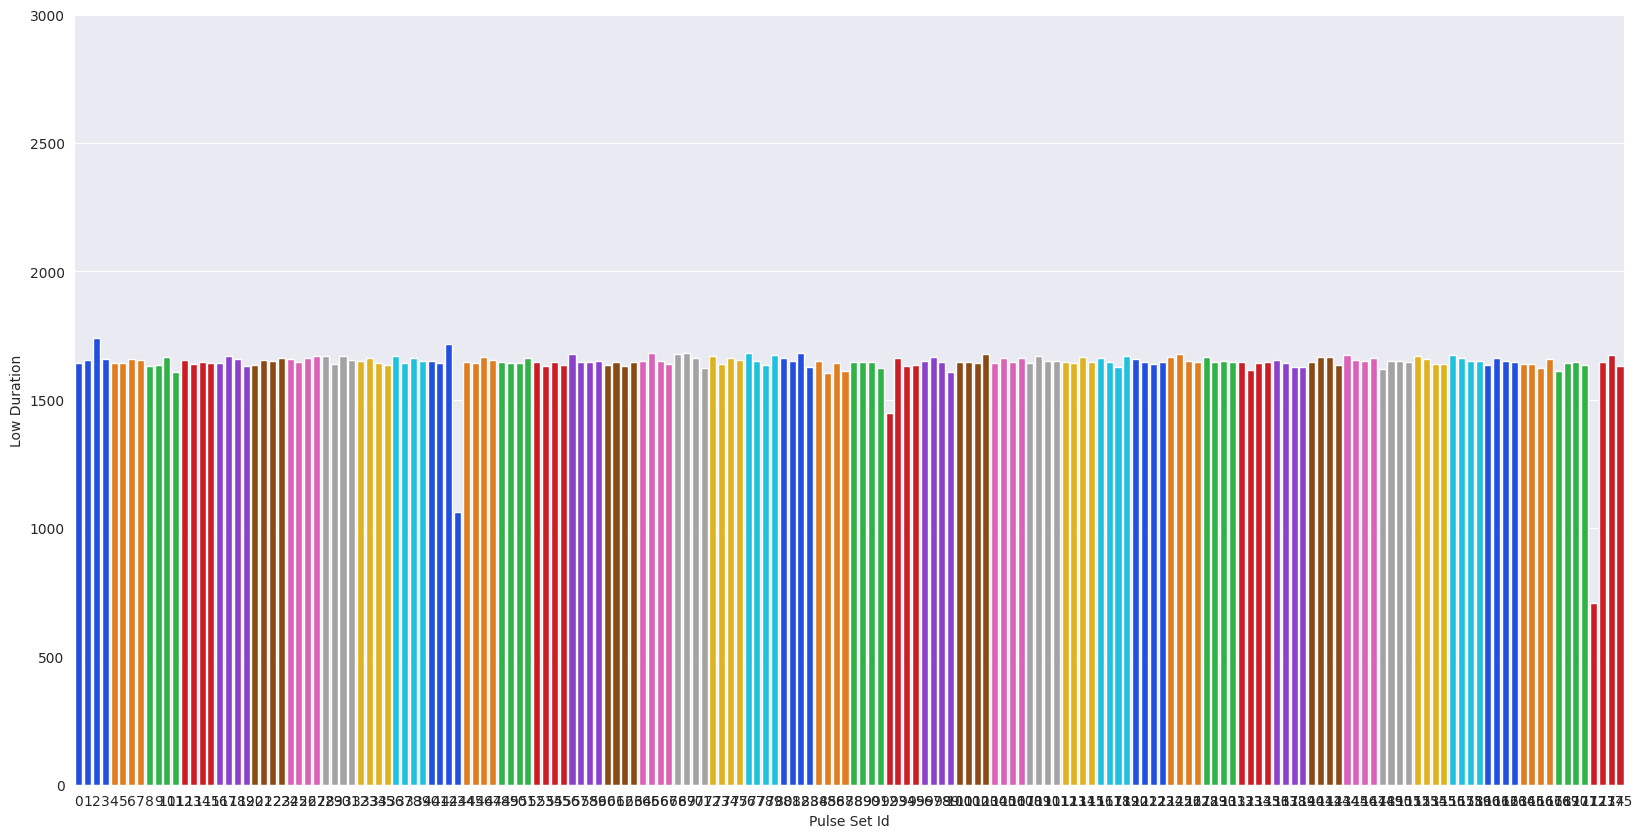

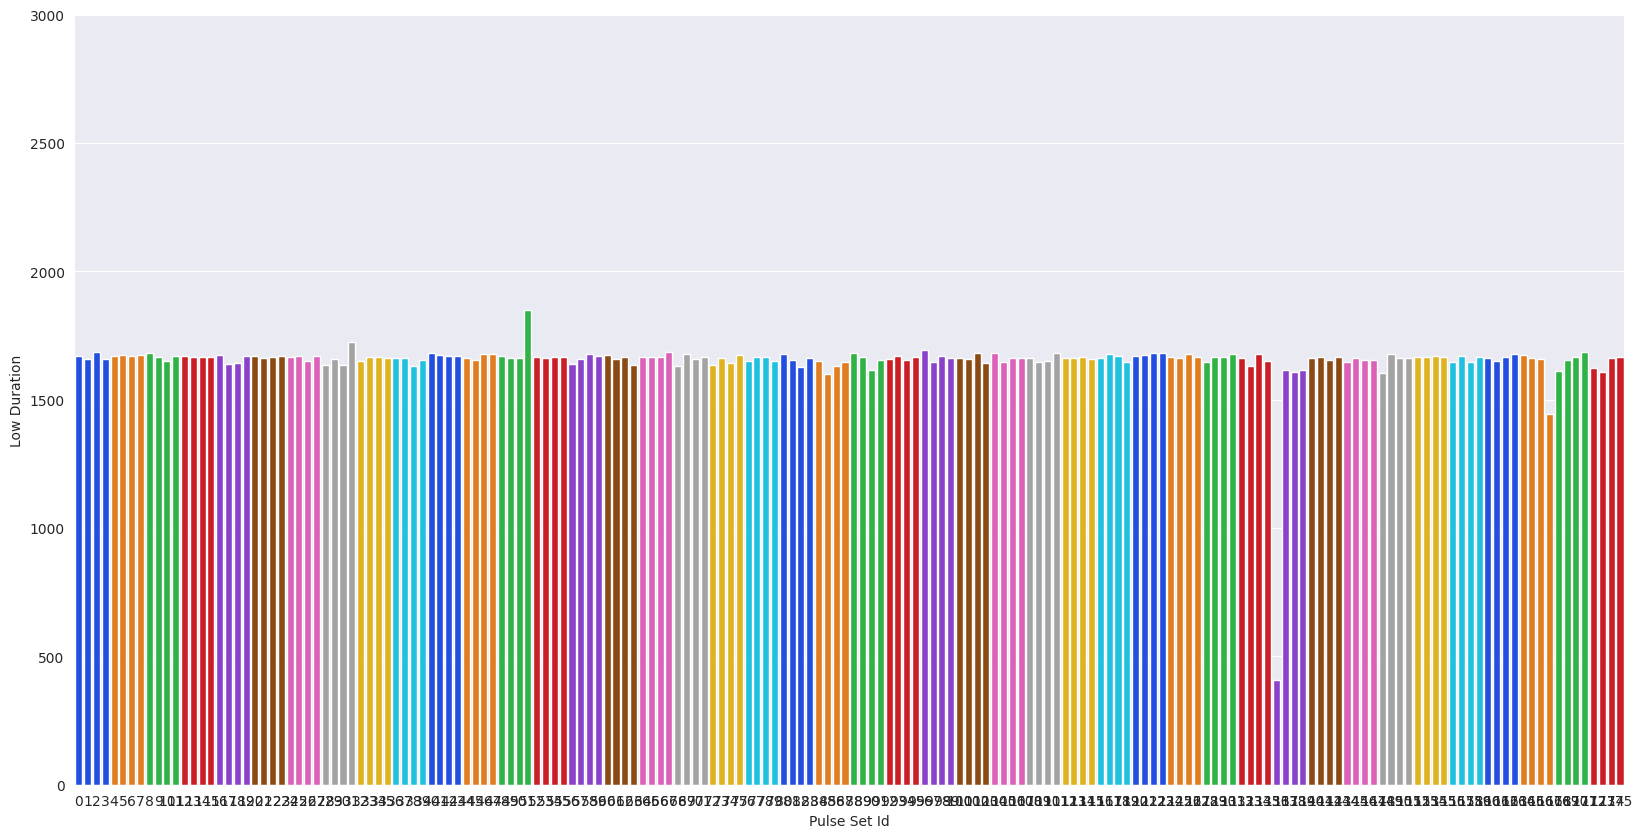

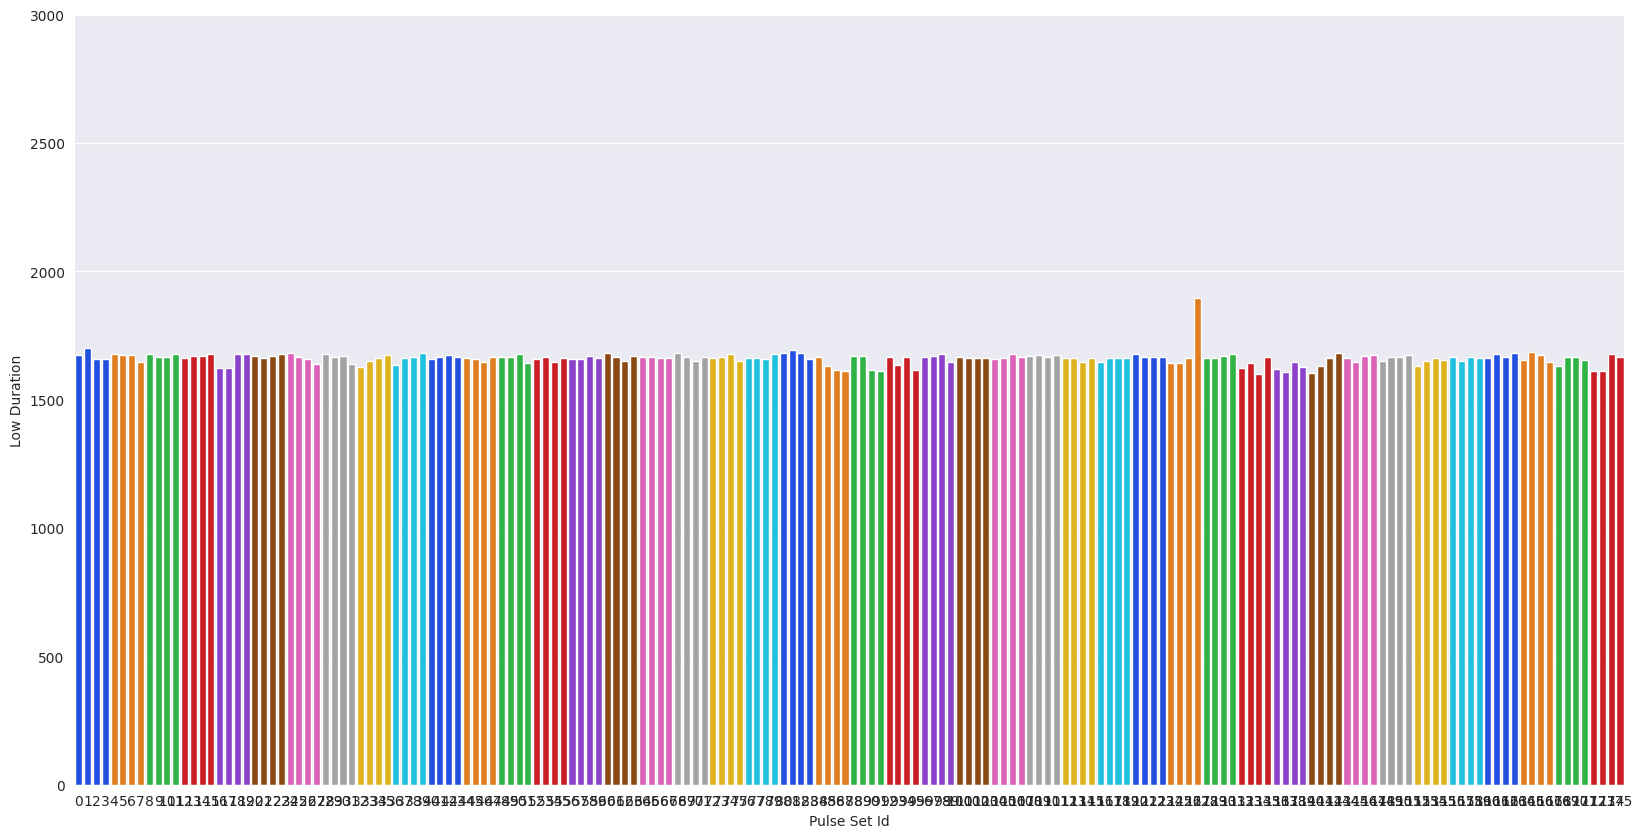

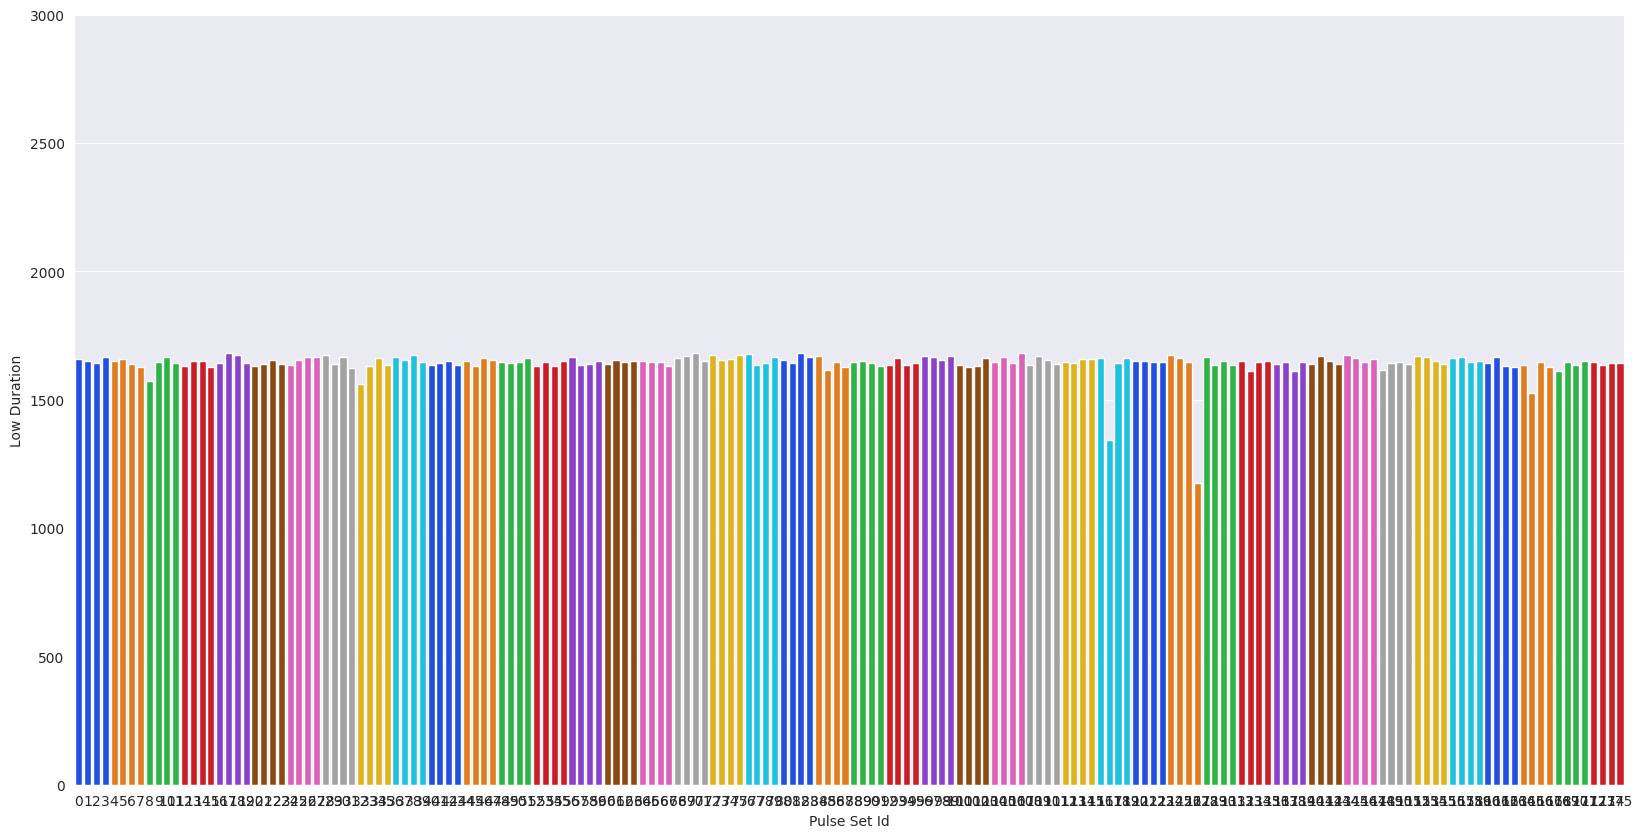

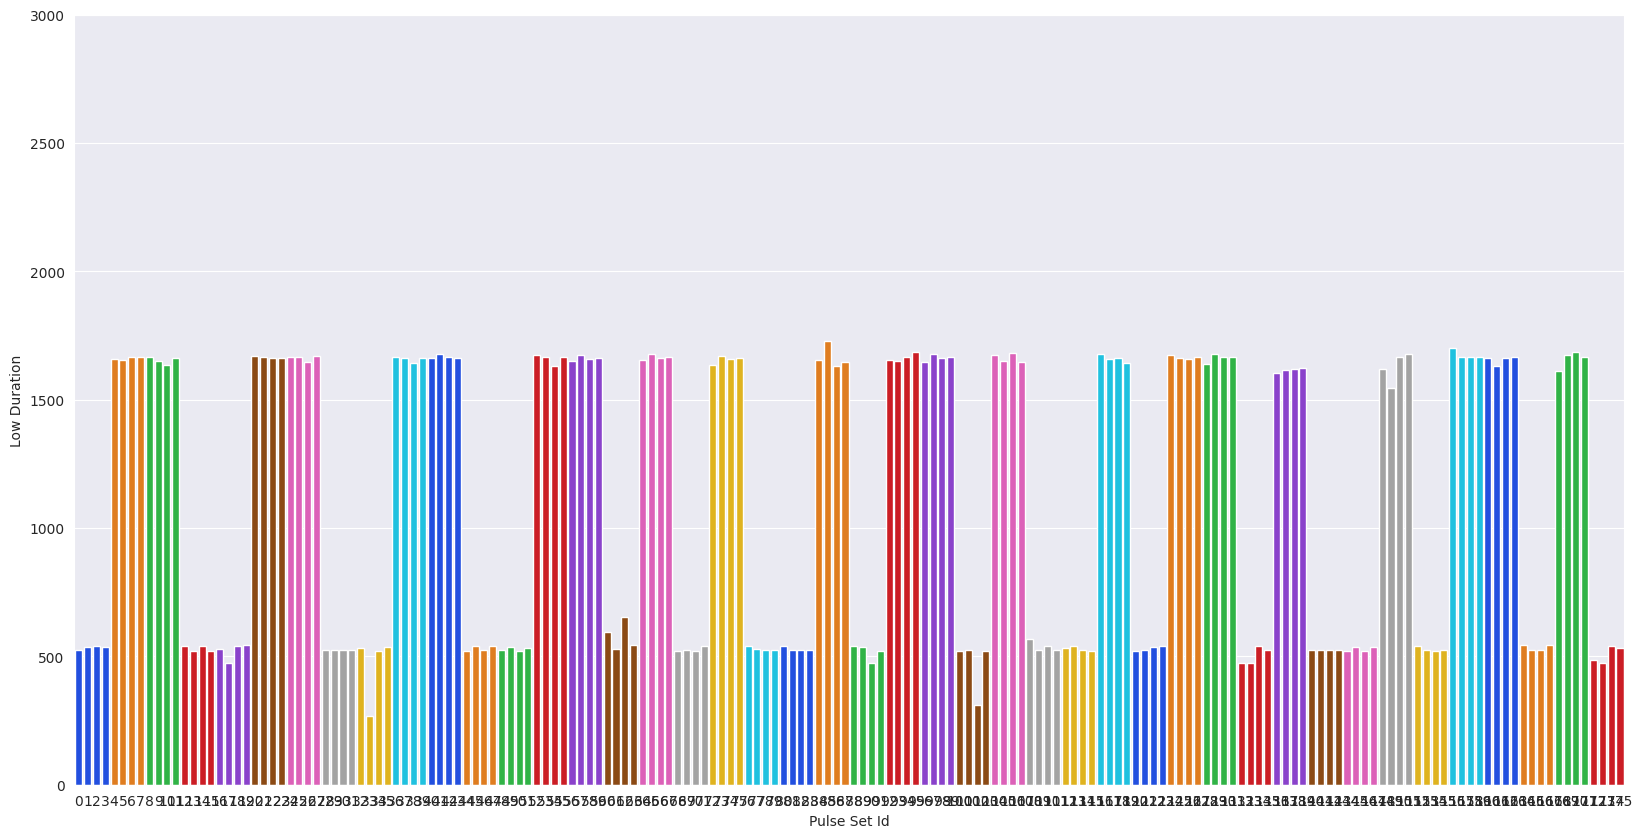

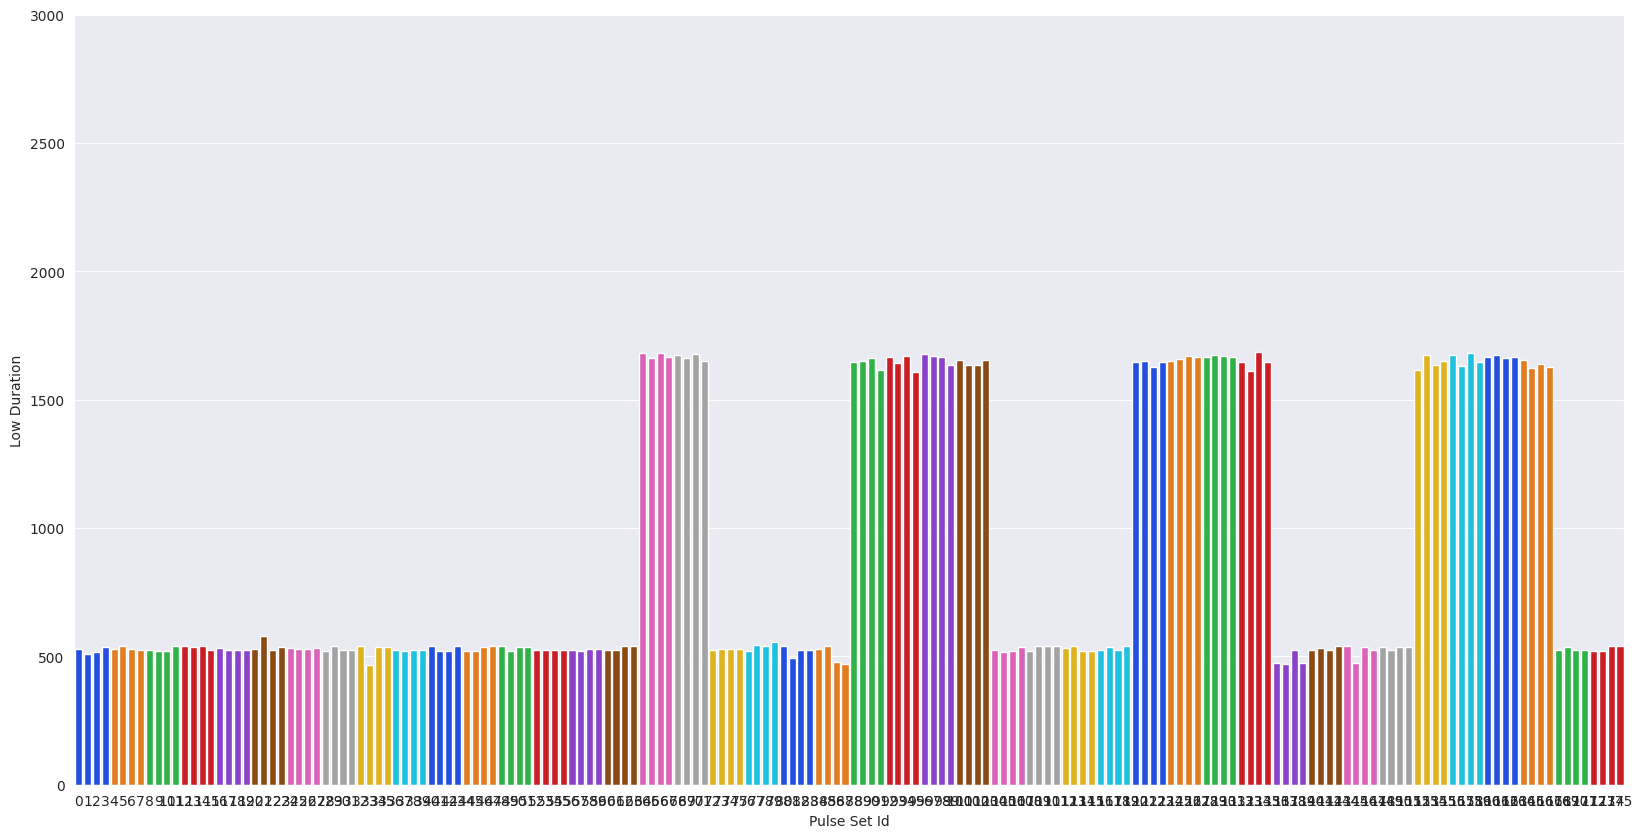

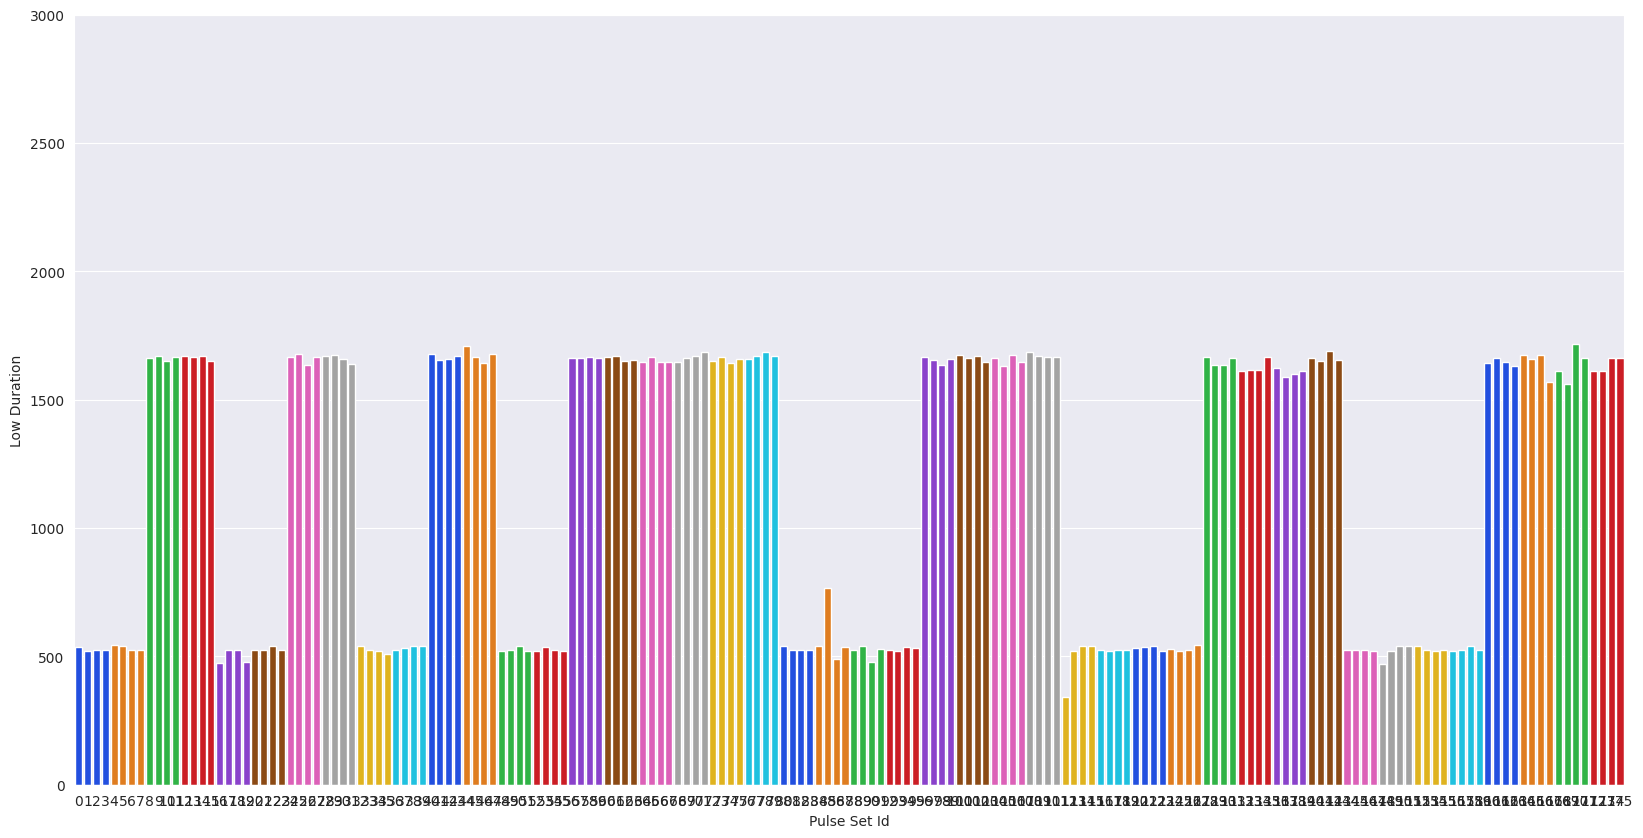

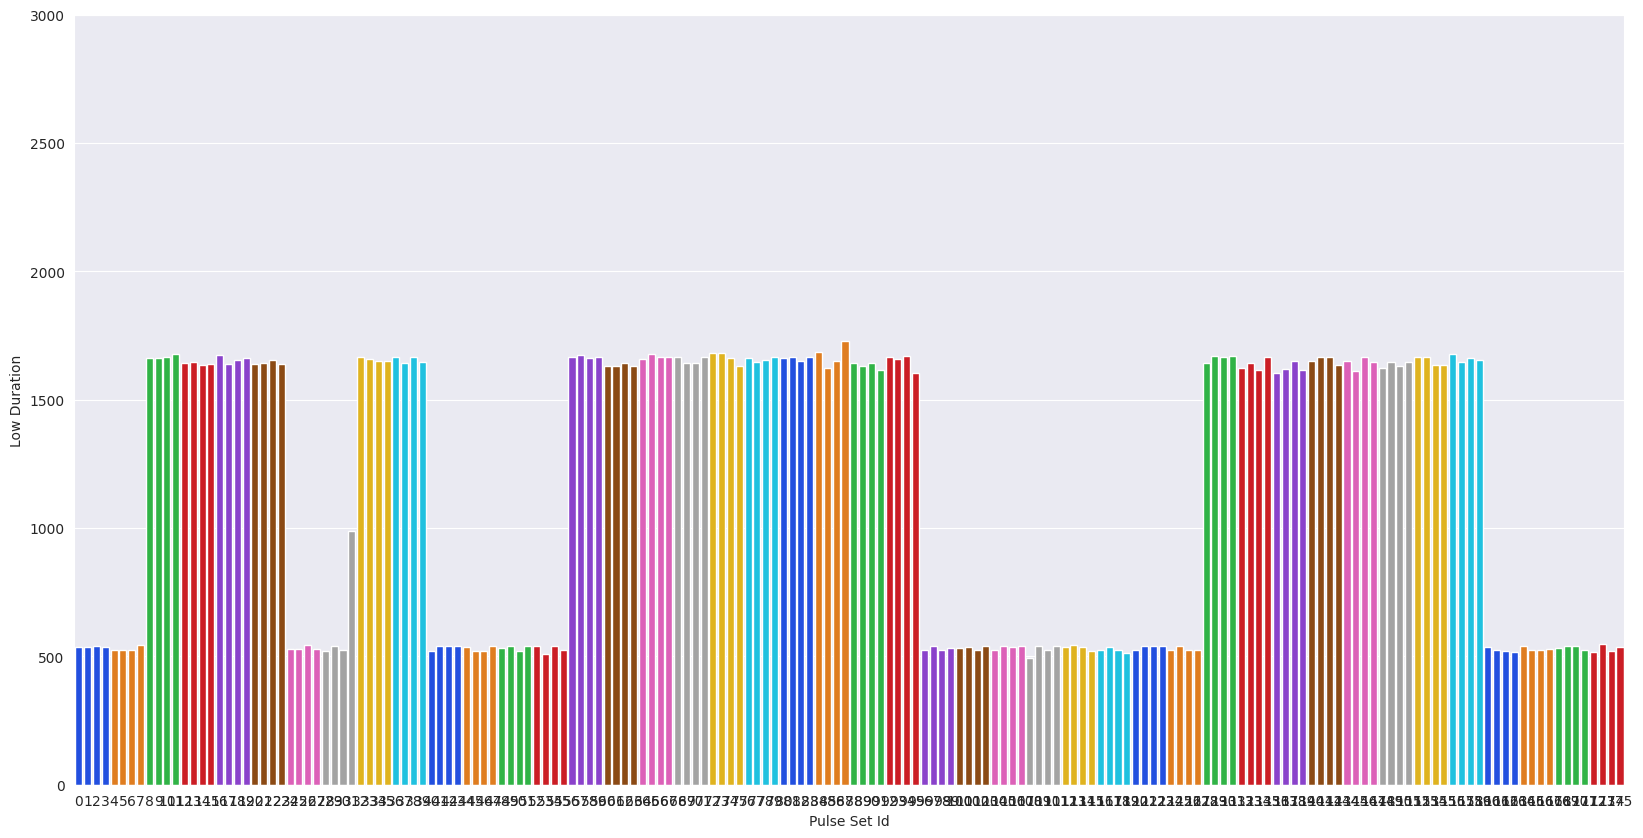

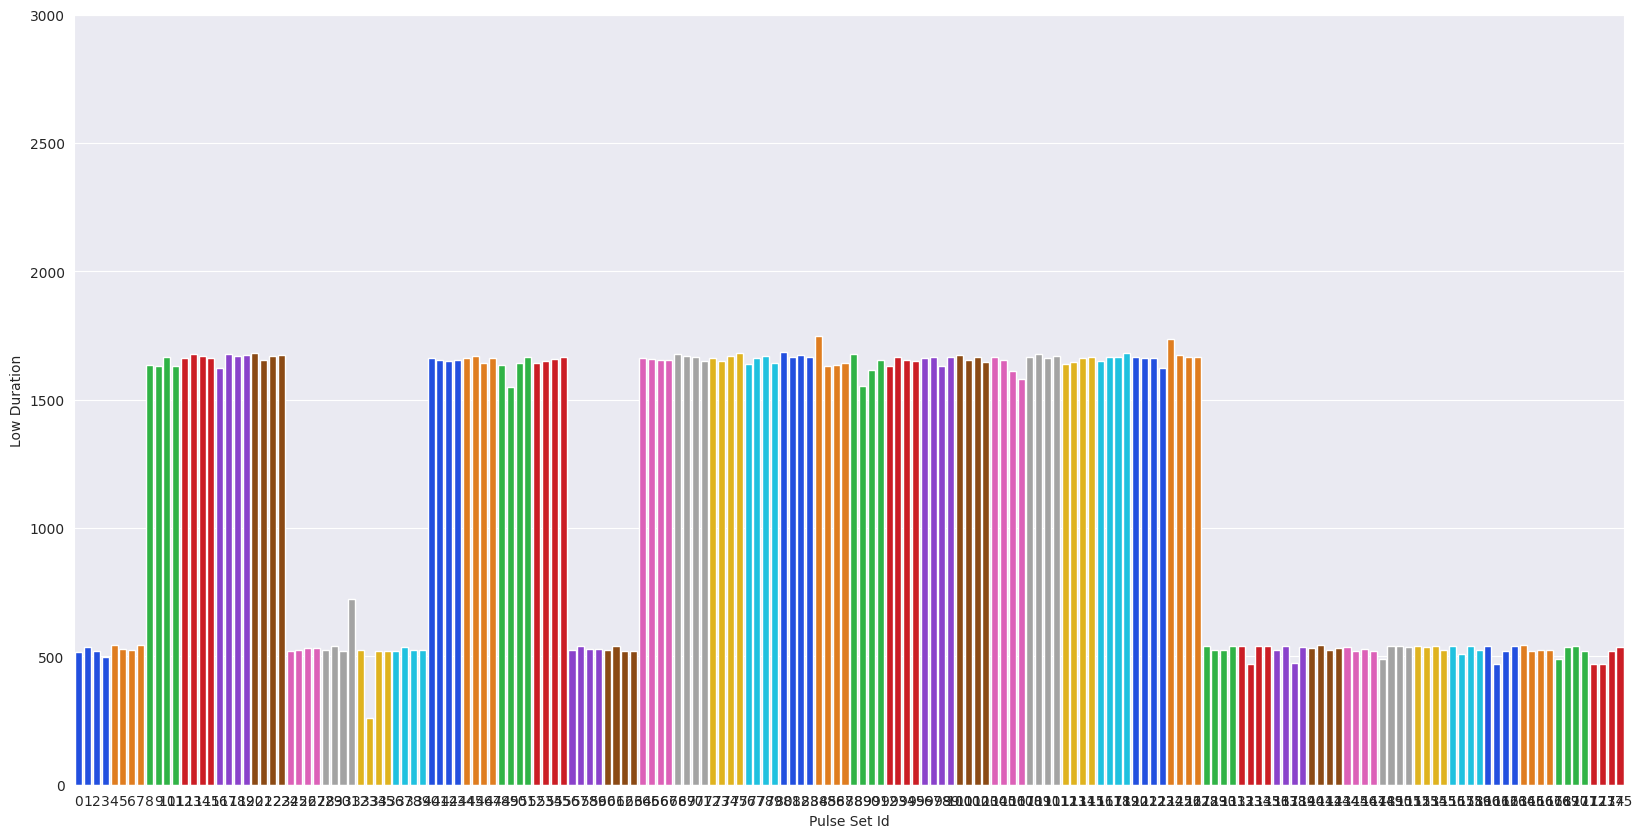

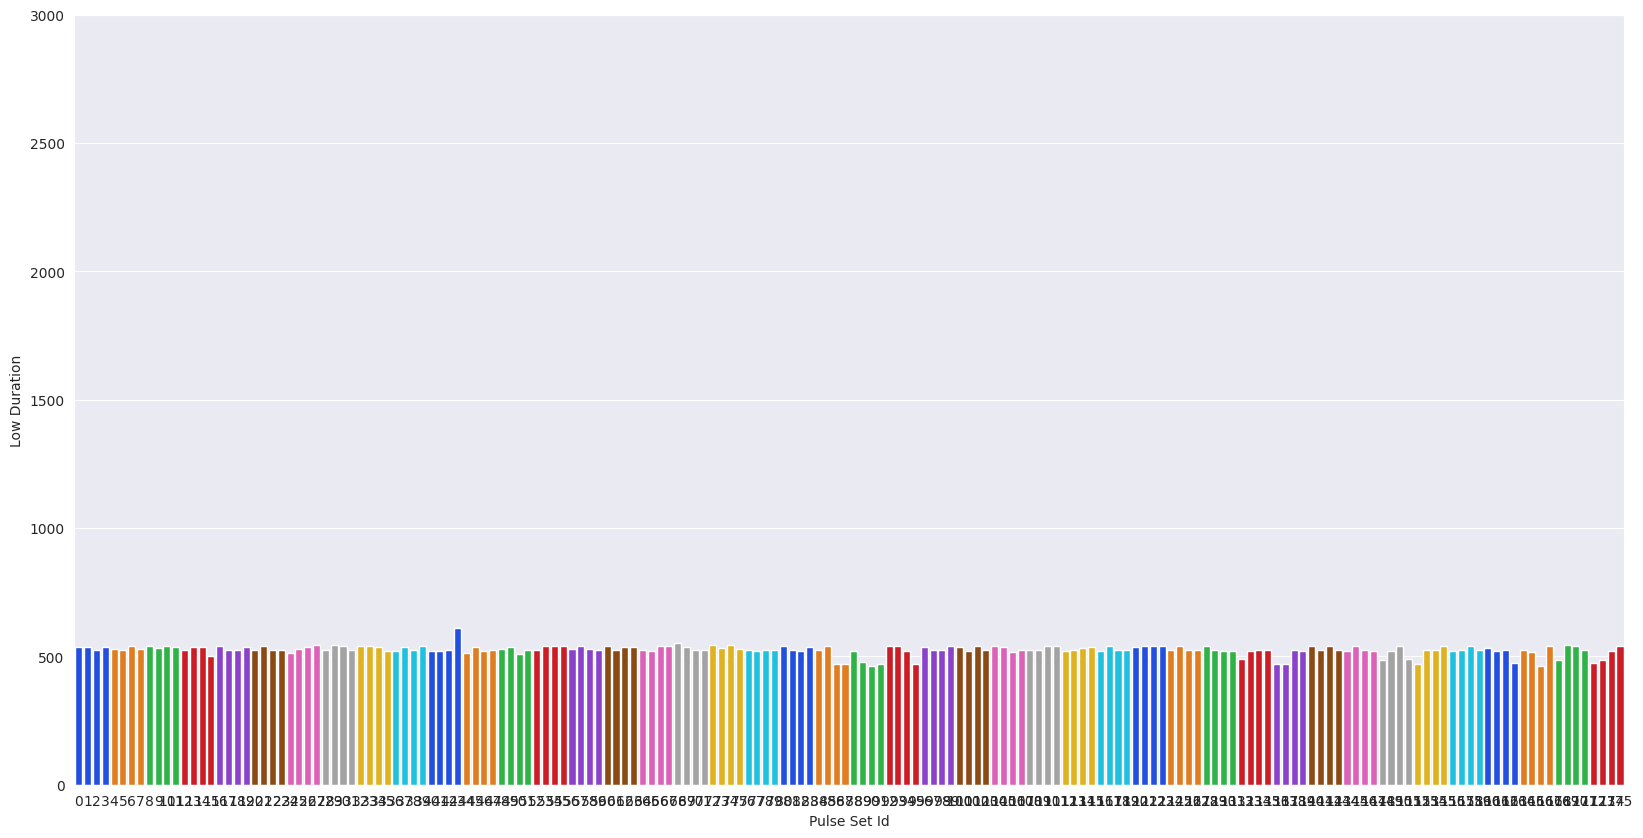

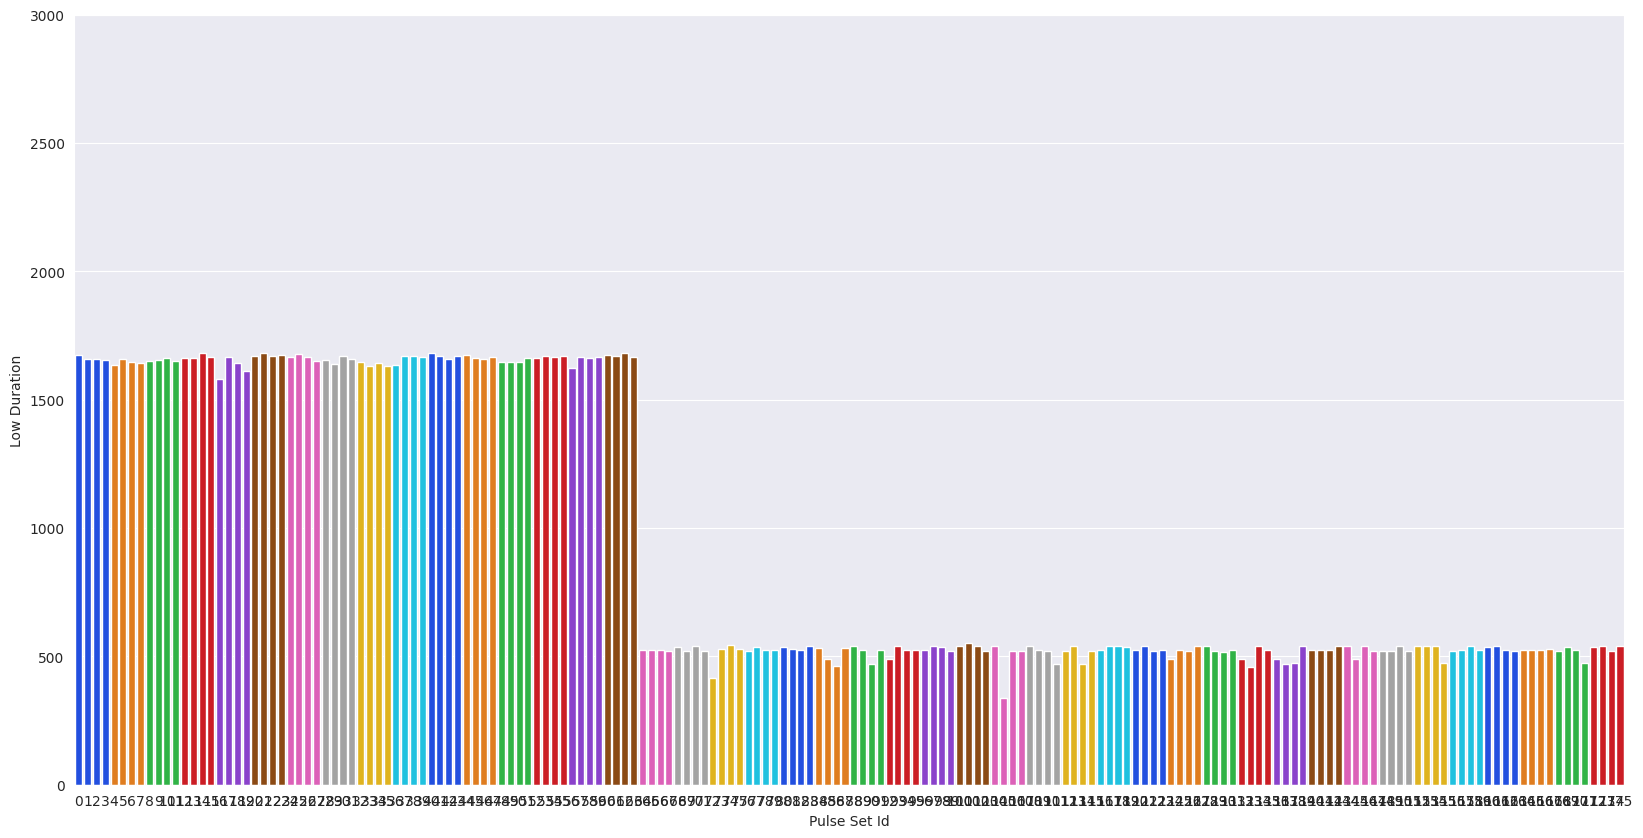

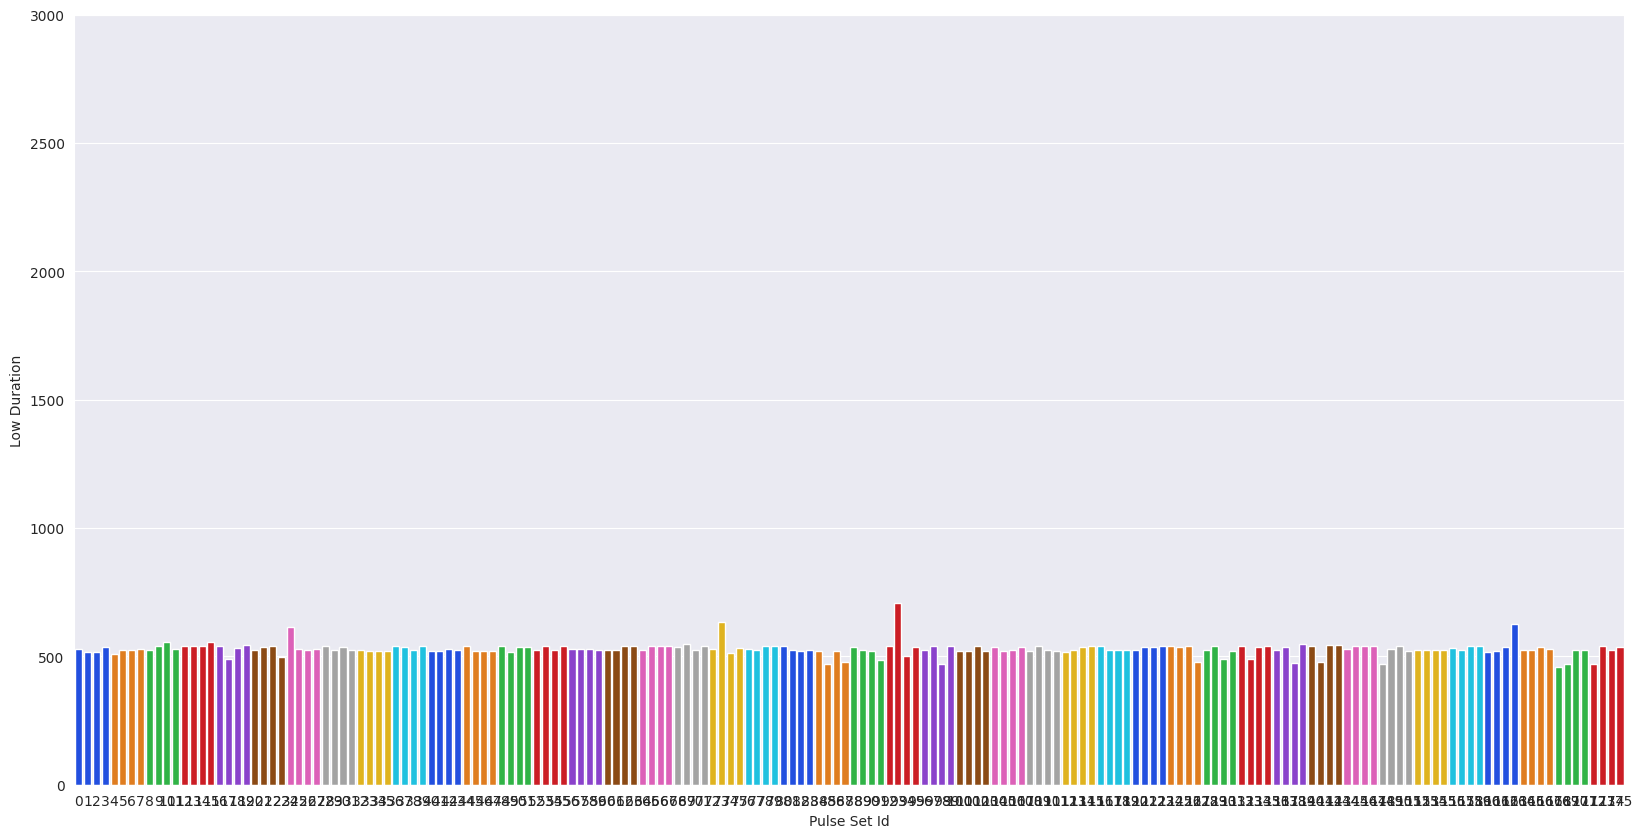

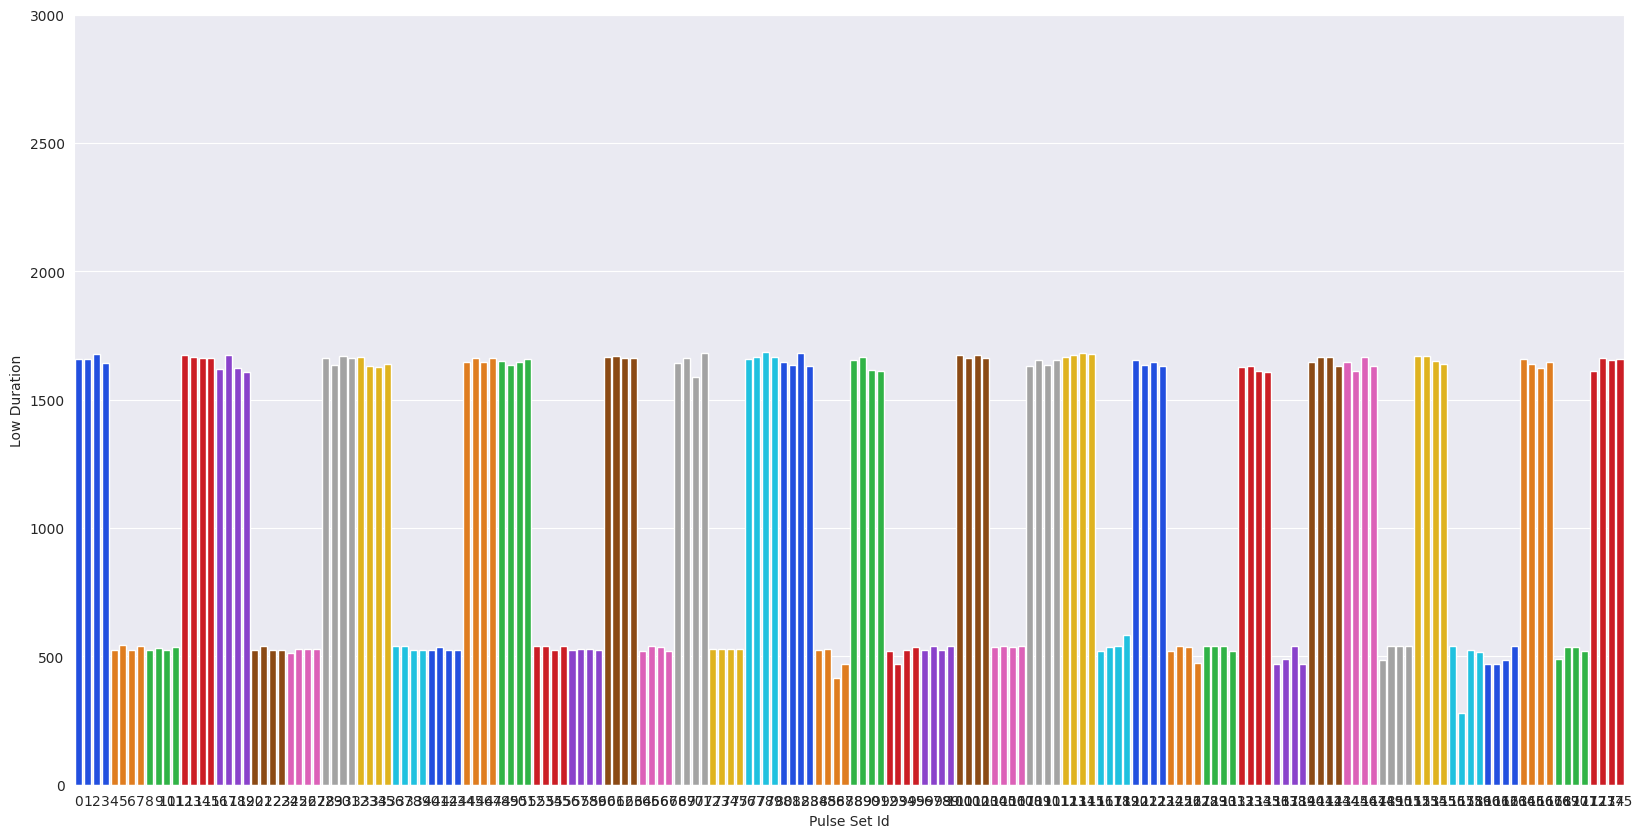

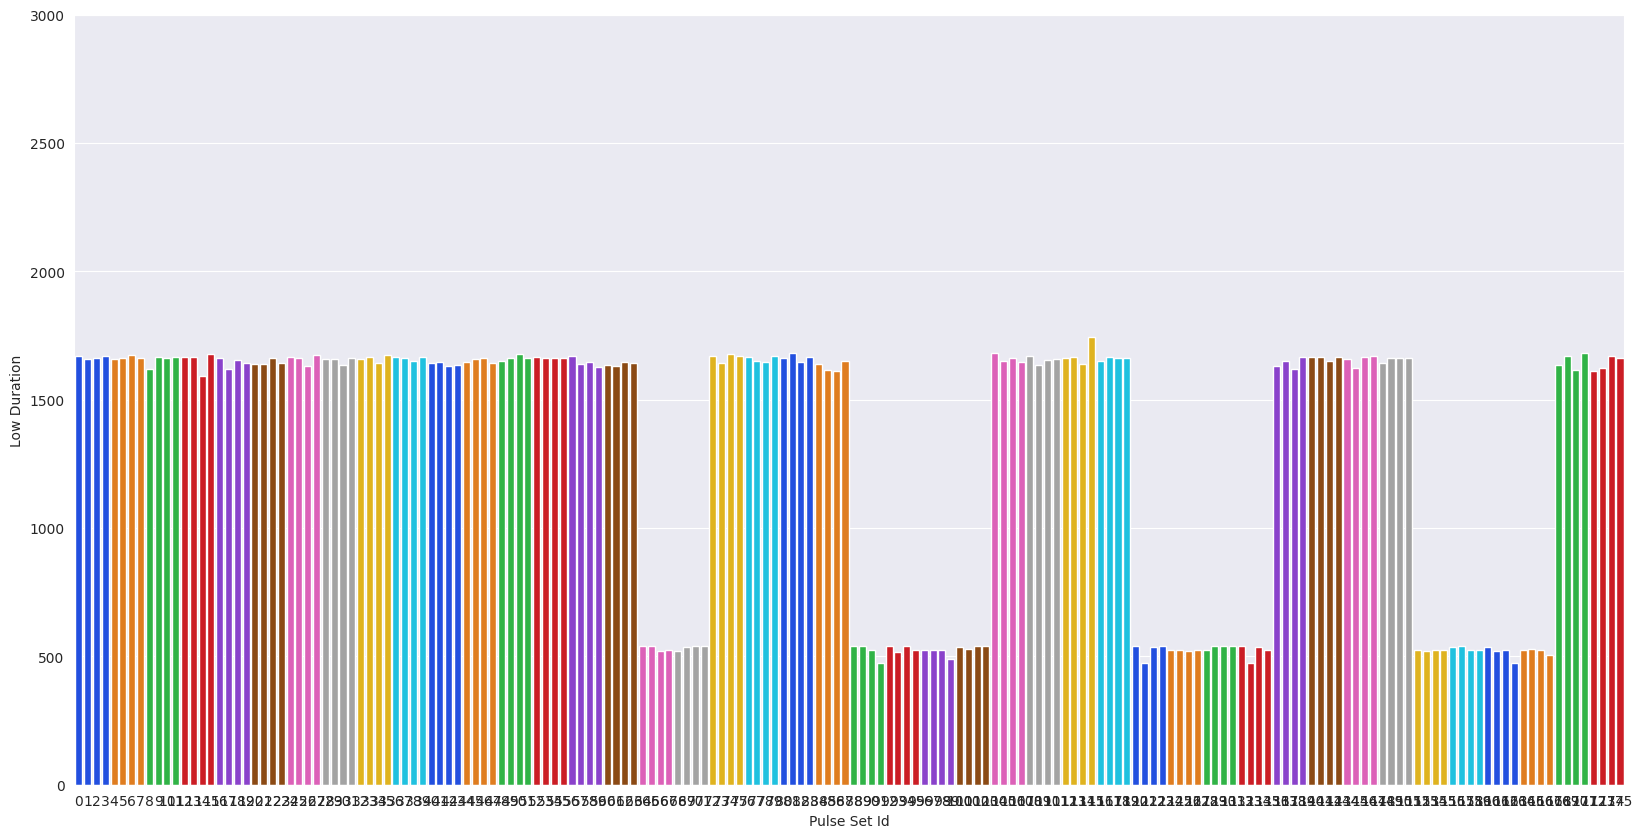

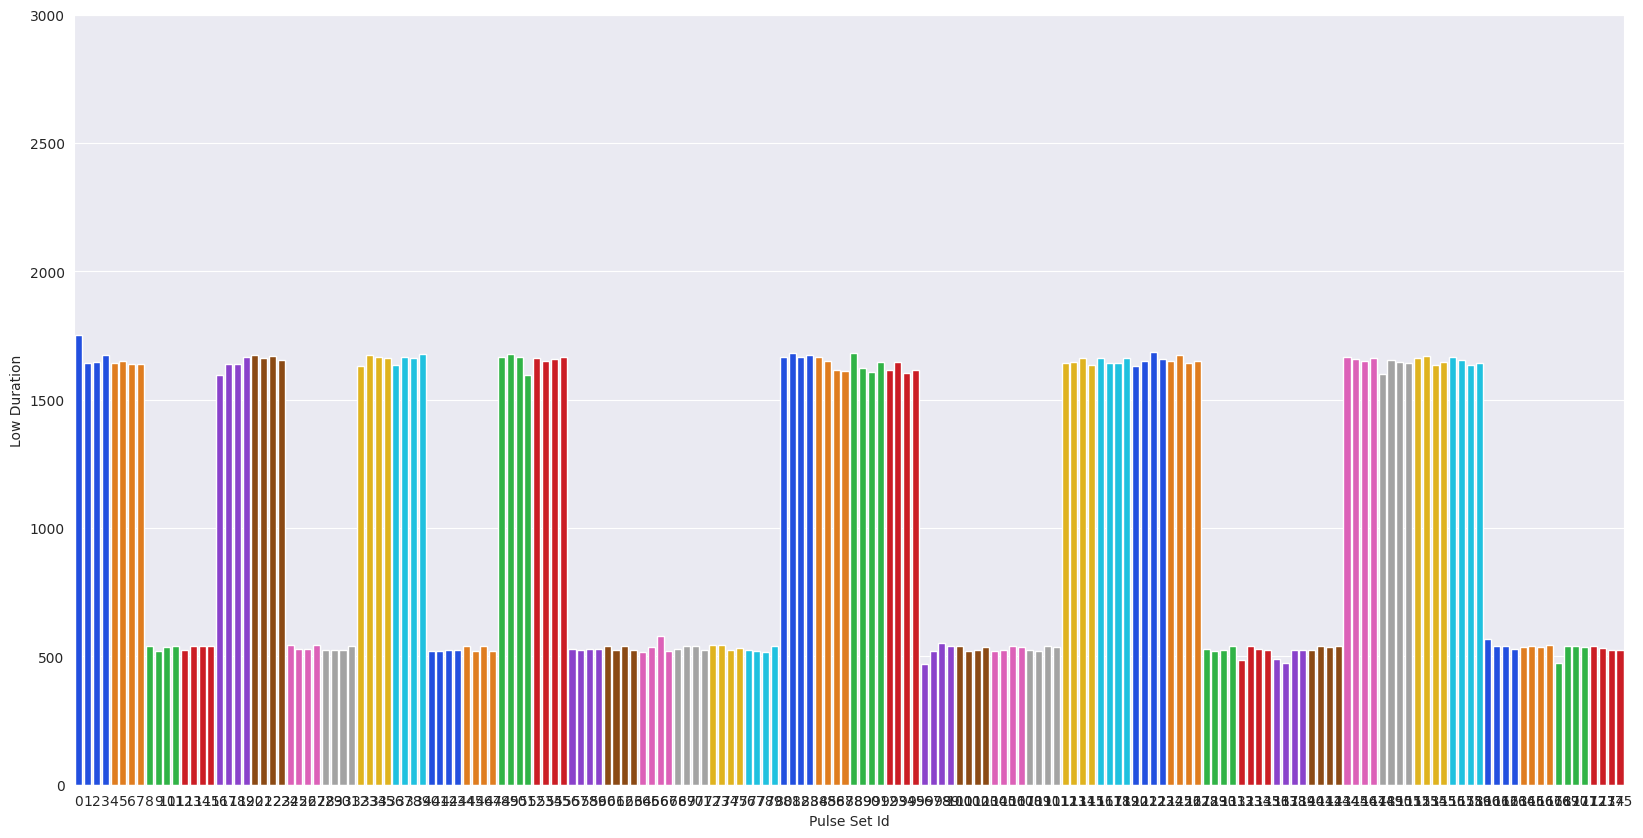

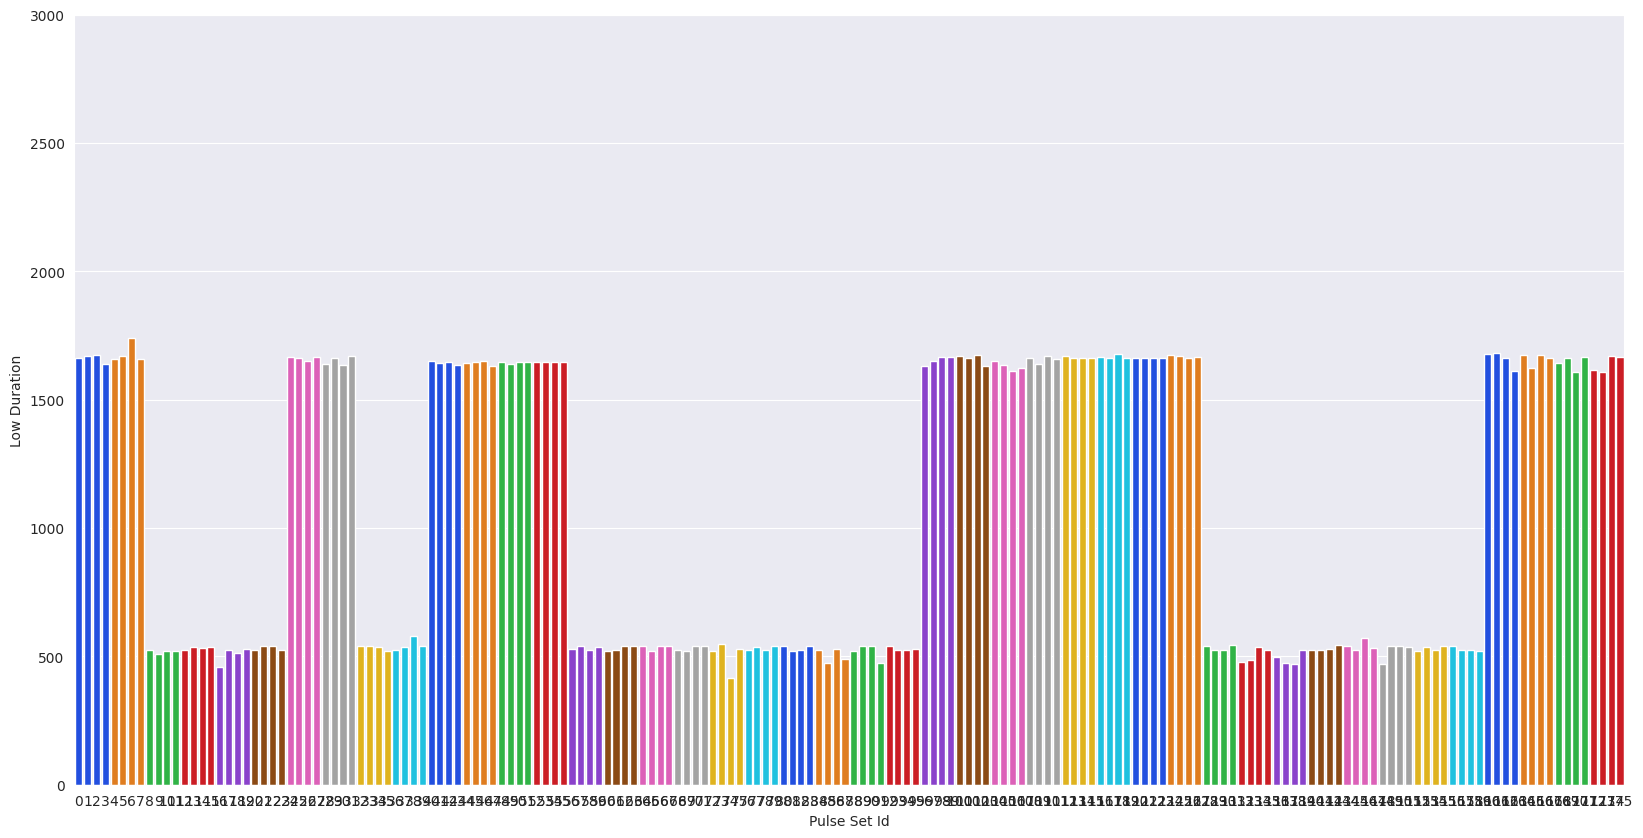

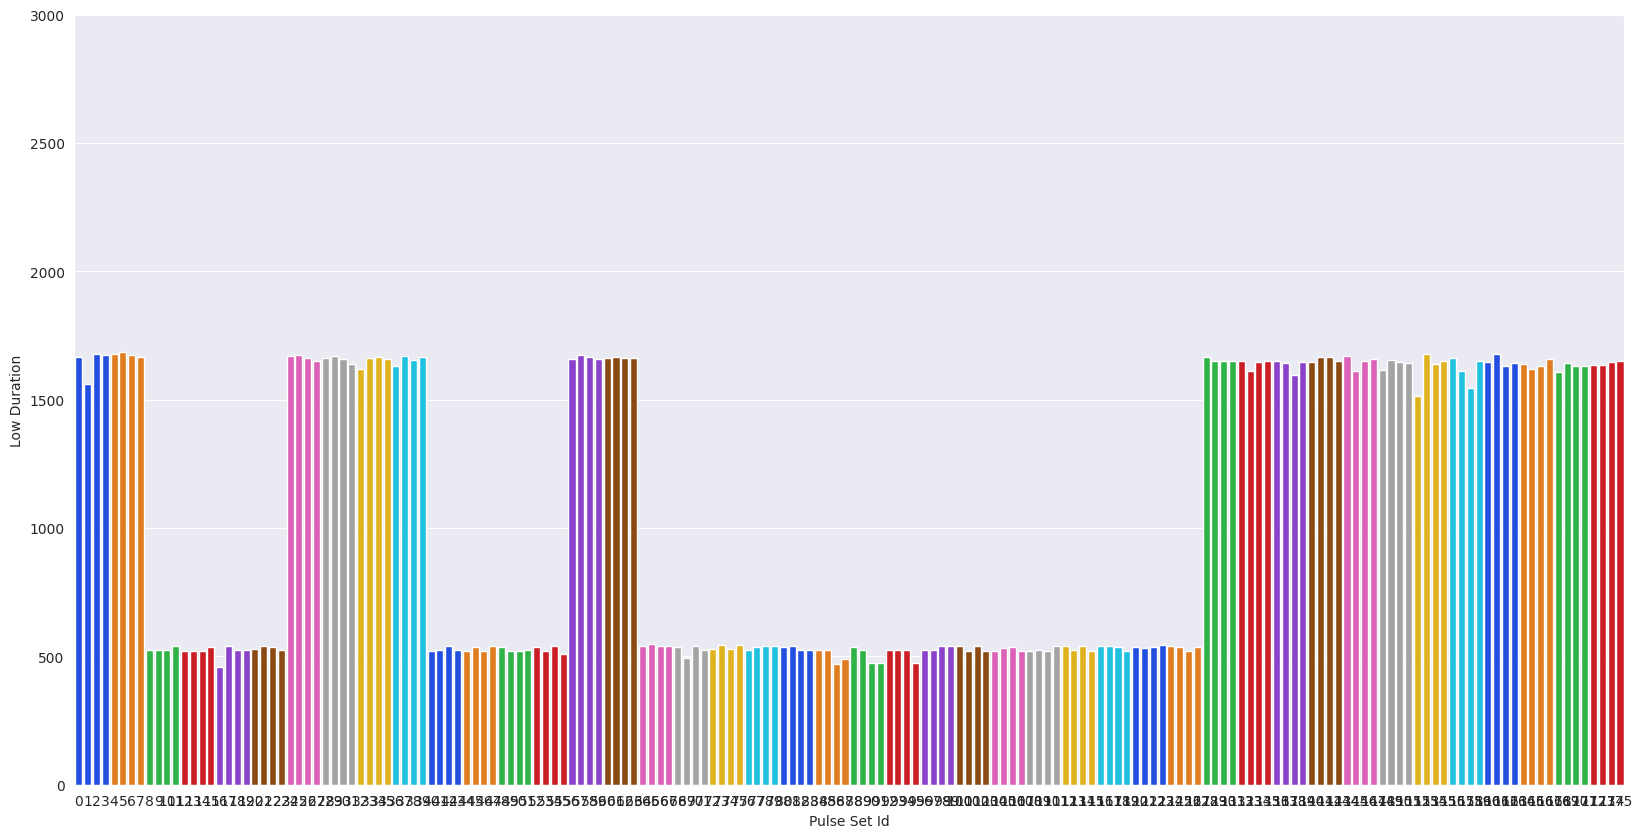

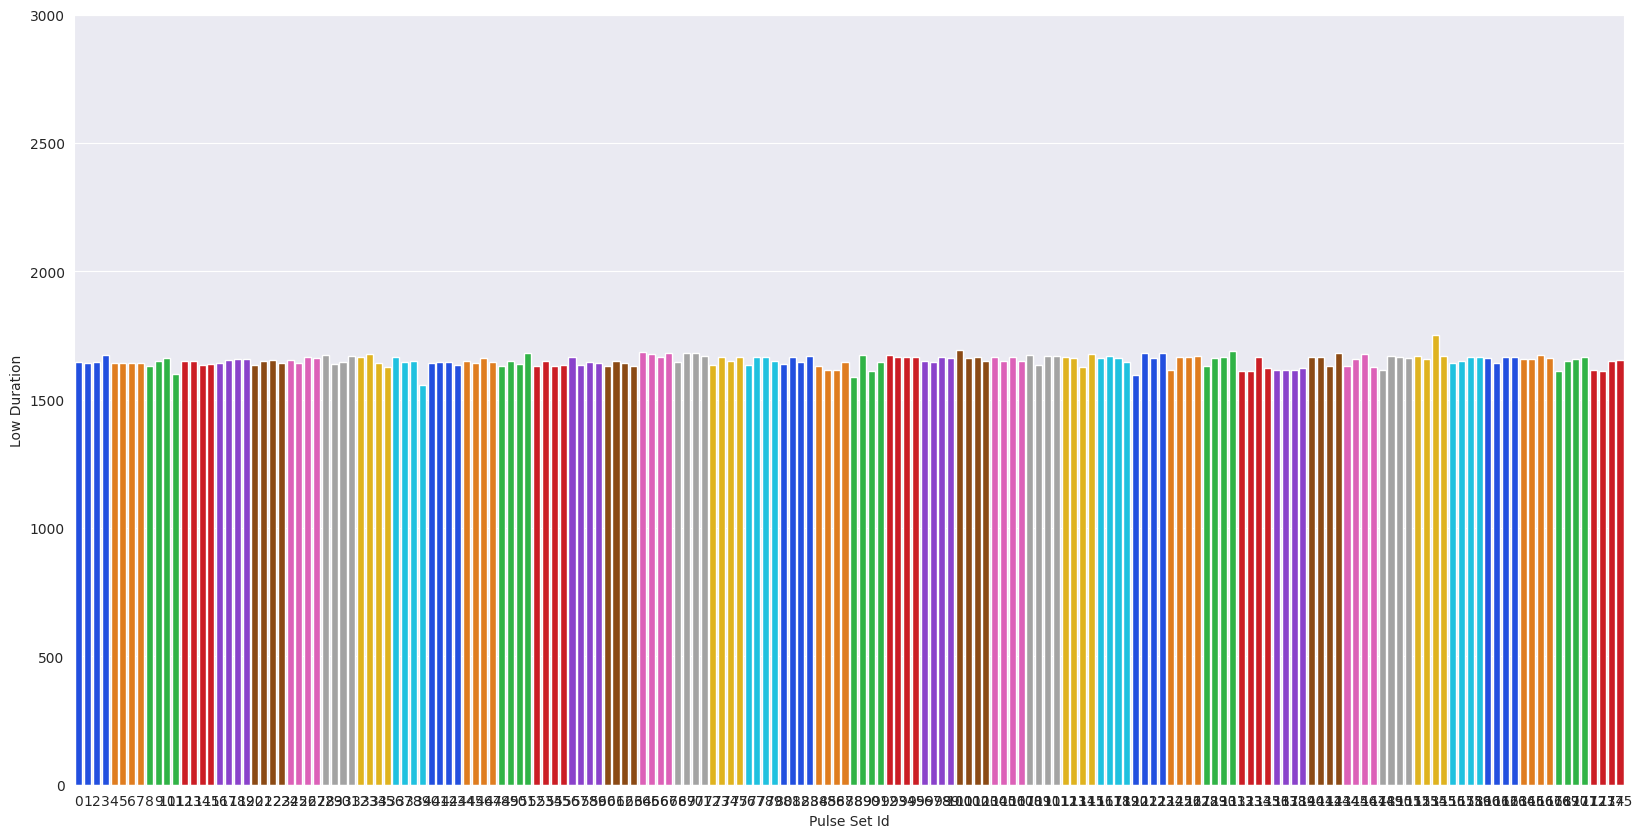

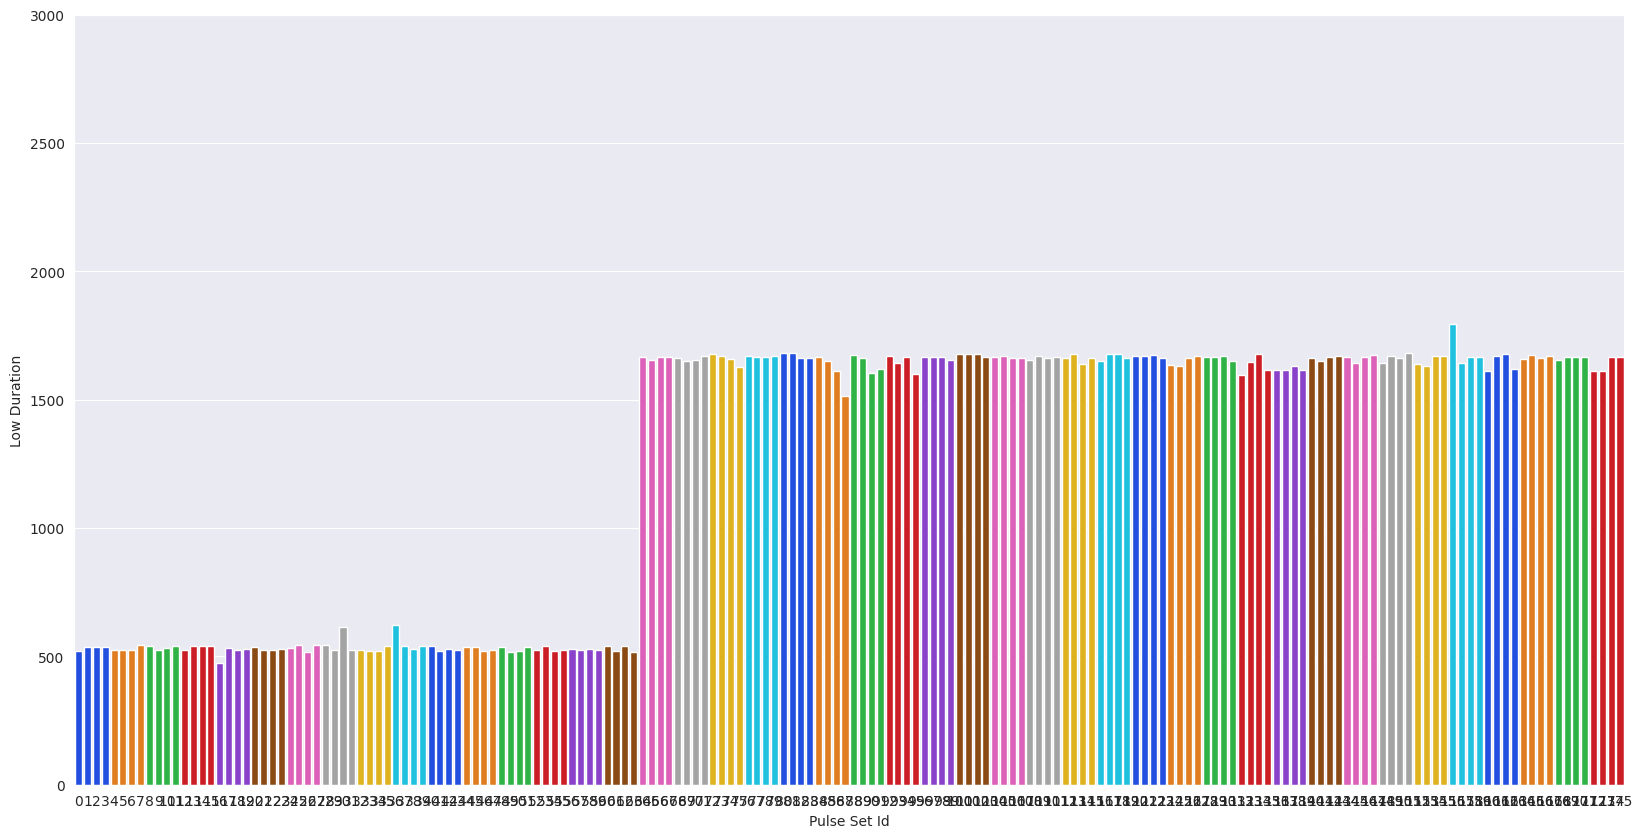

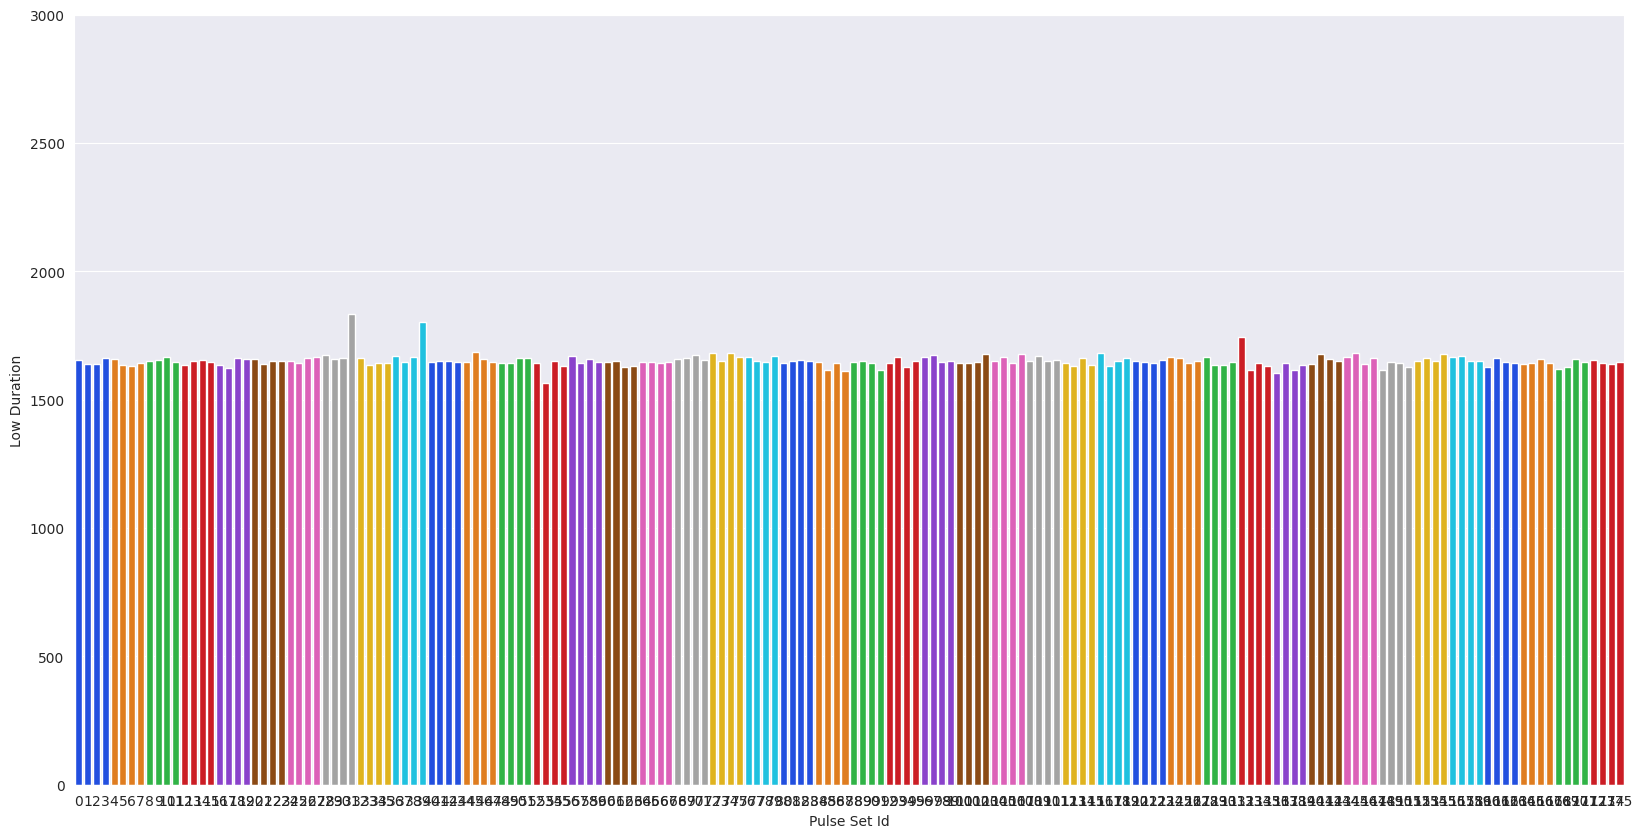

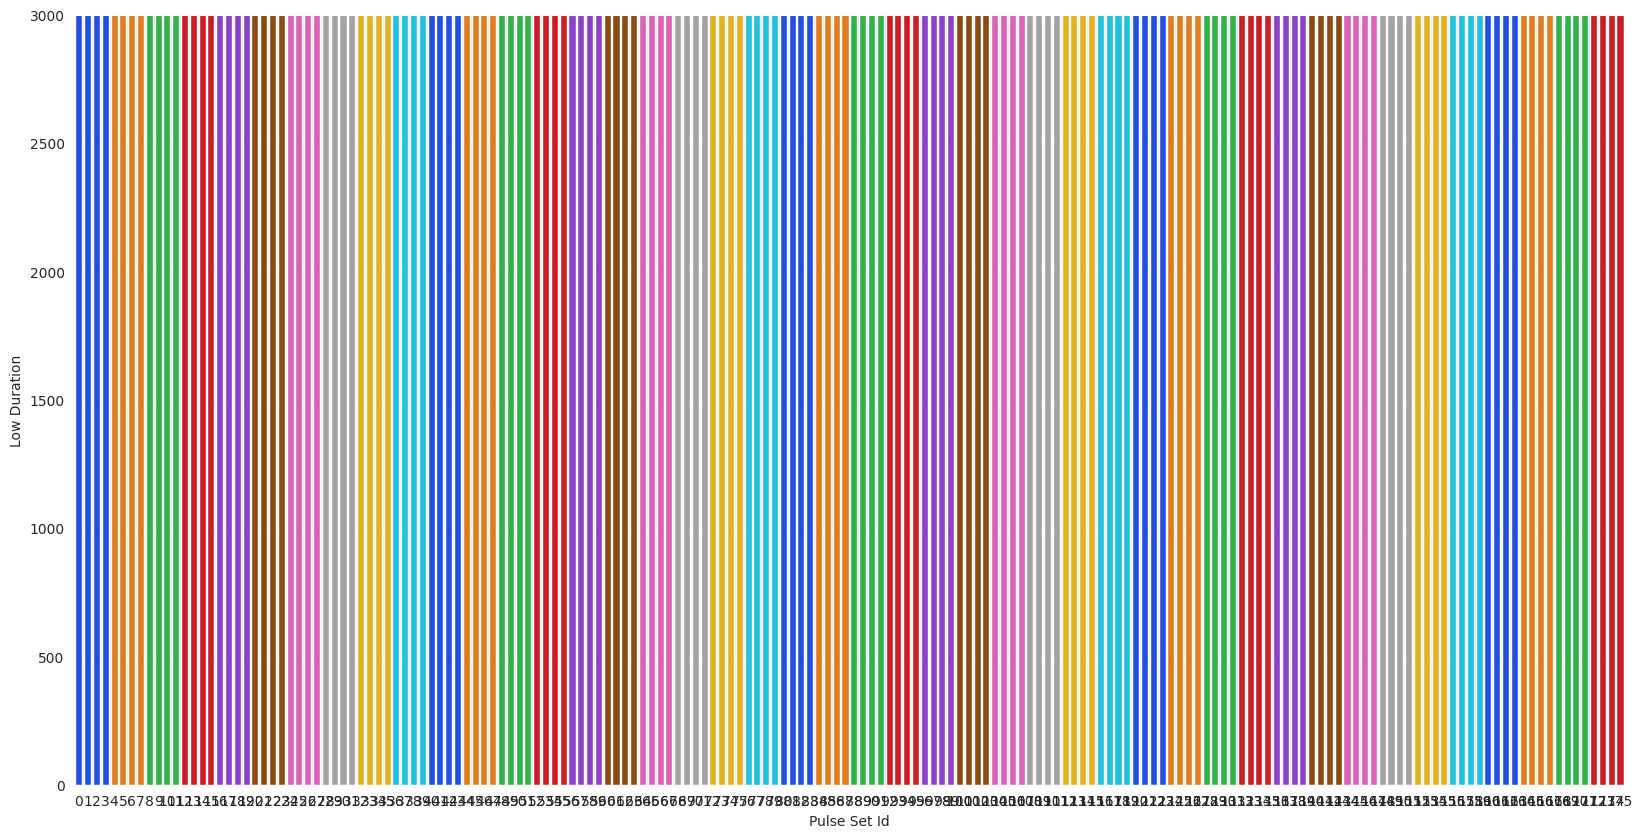

In [37]:

for i in df["Pulse Index"].unique():
    plt.figure(figsize=(20, 10))
    sns.barplot(df[df["Pulse Index"].apply(lambda x: x == i)], x="Pulse Set Id", y="Low Duration", hue="Expected Button Group", palette="bright")
    plt.gca().set_ylim(0, 3000)
    plt.gca().get_legend().remove()
    plt.show()

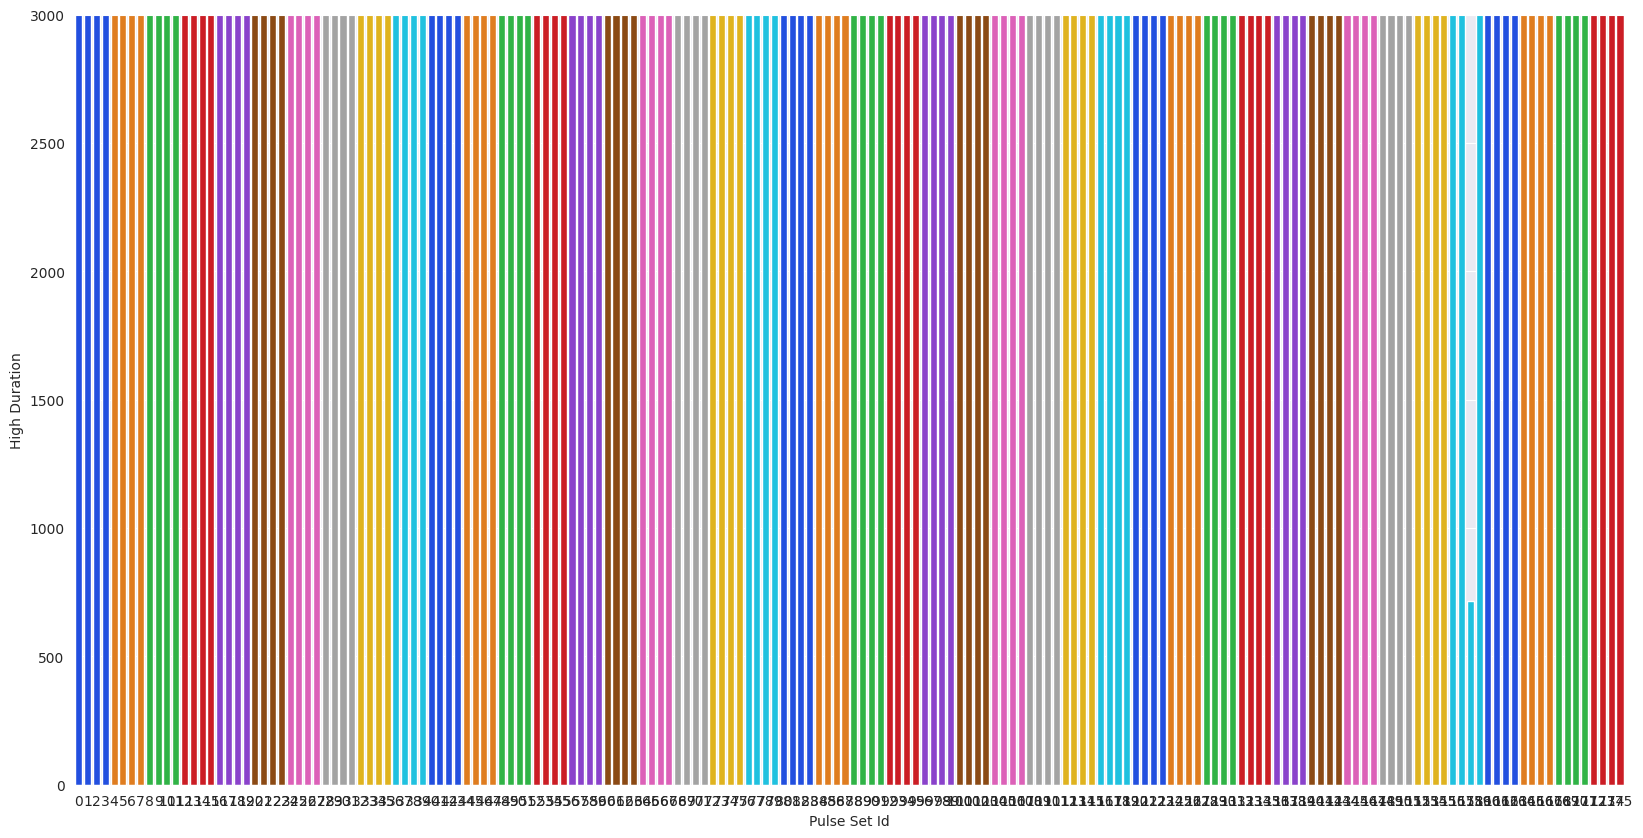

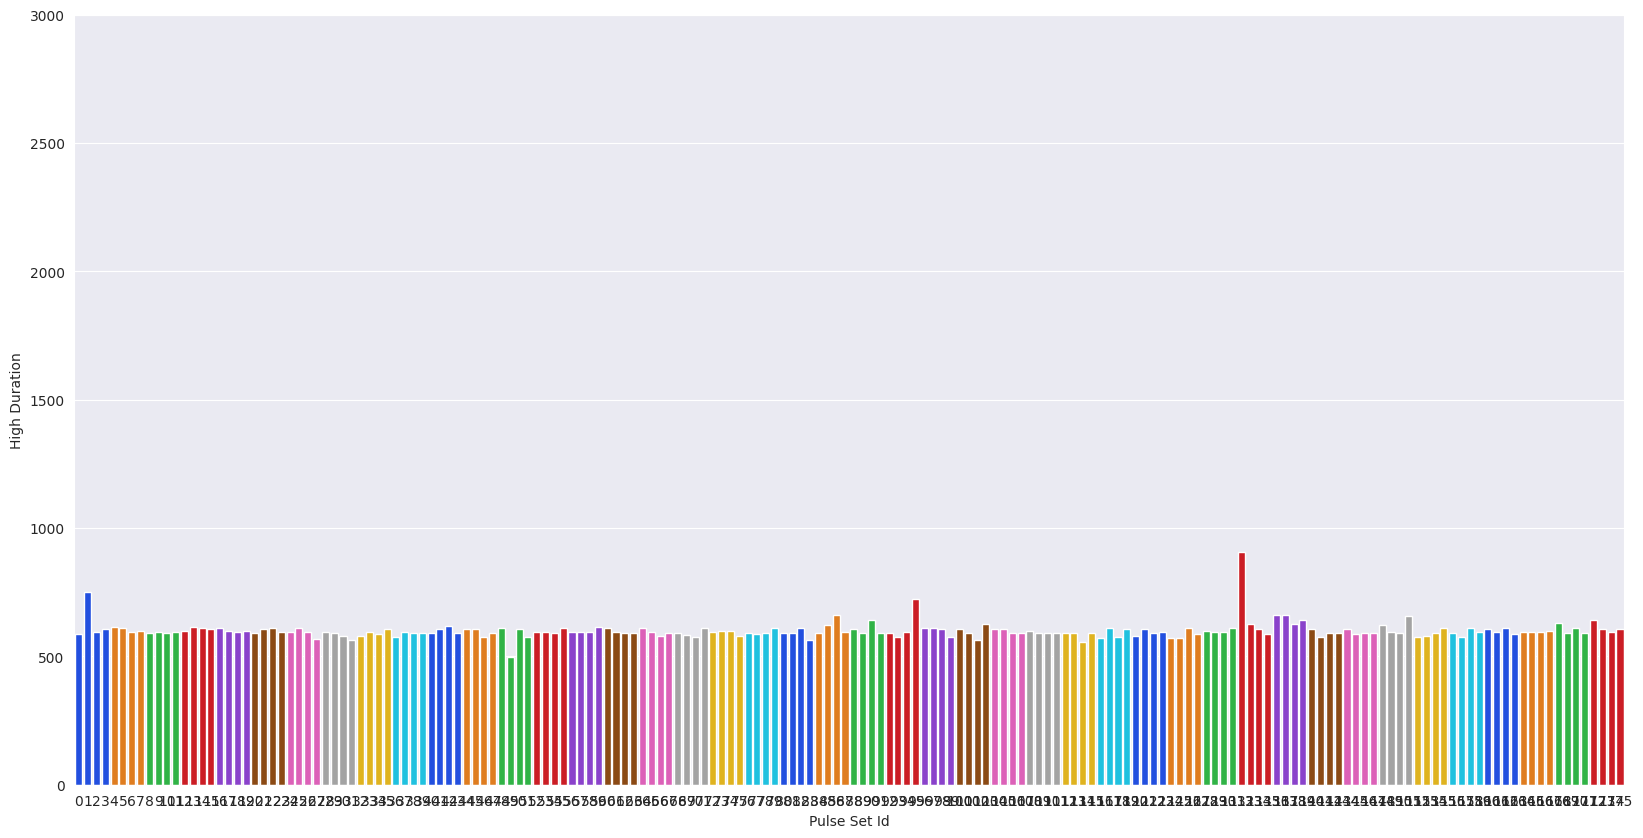

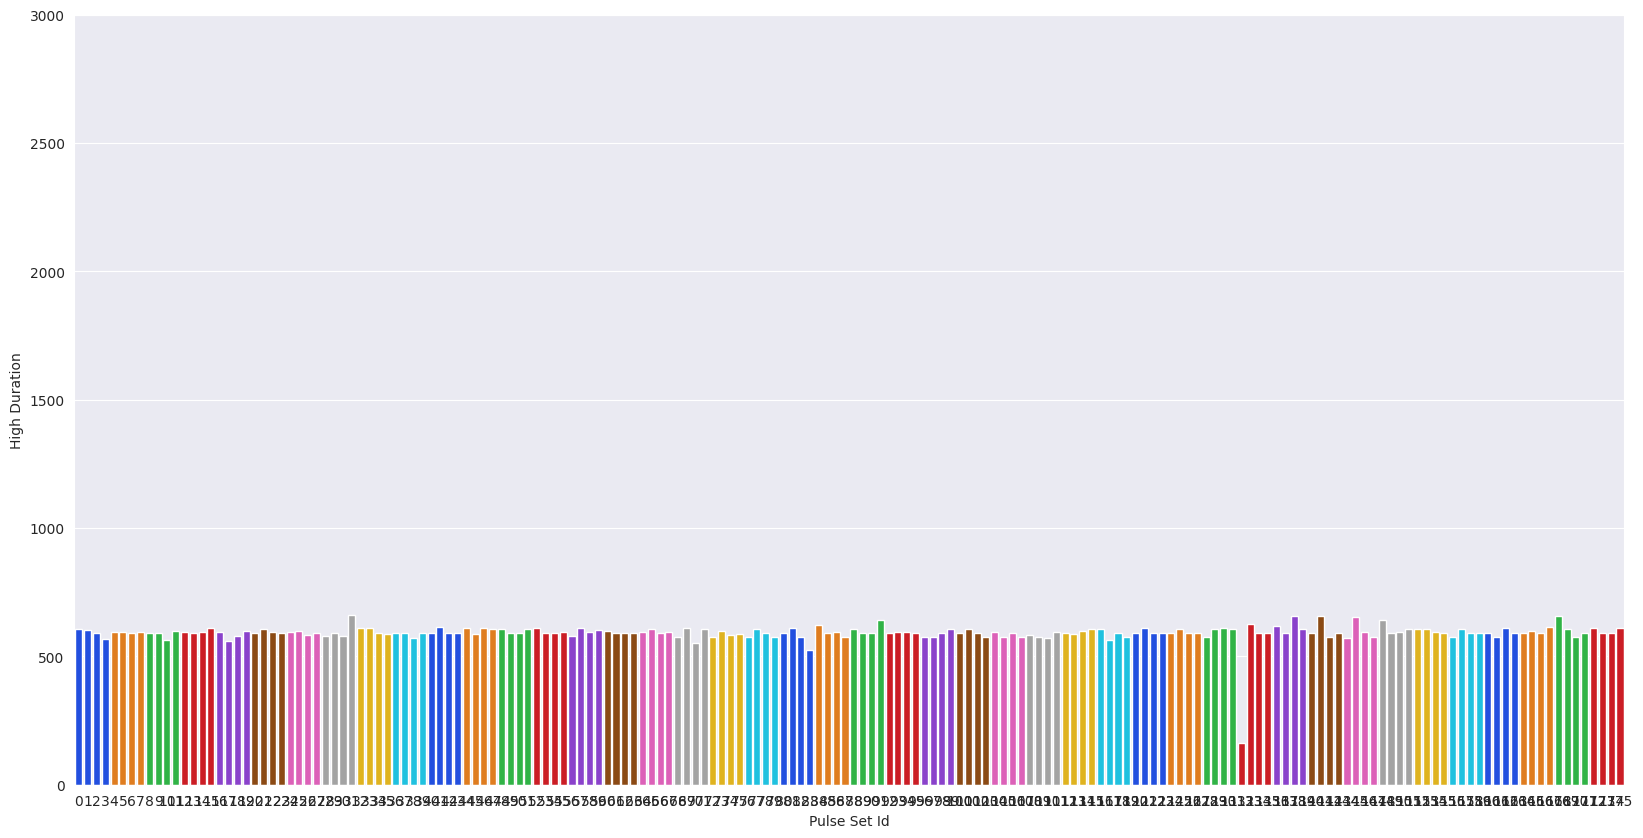

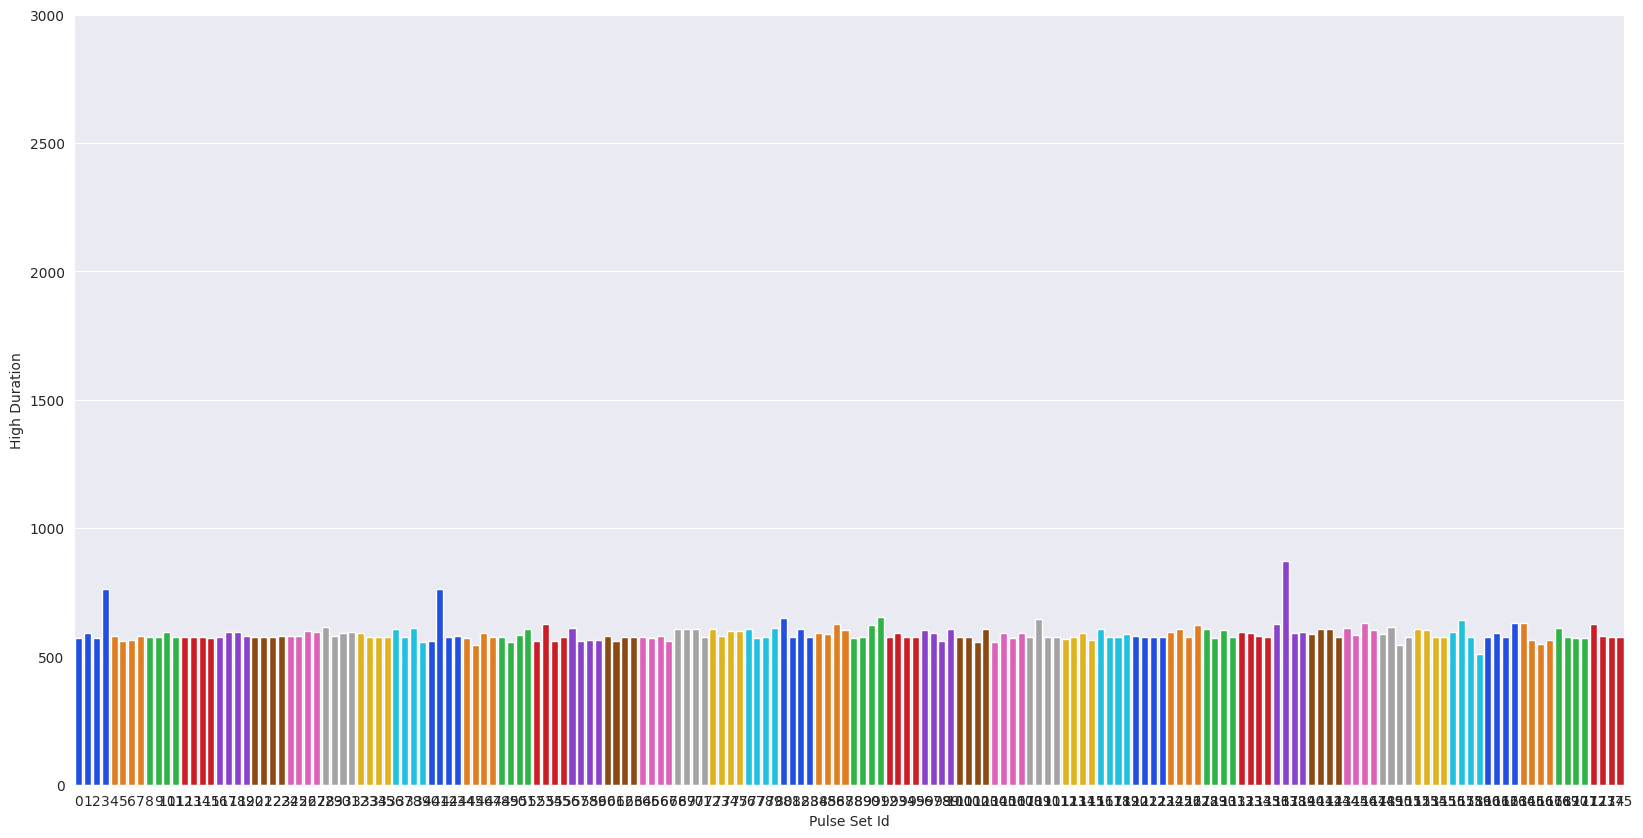

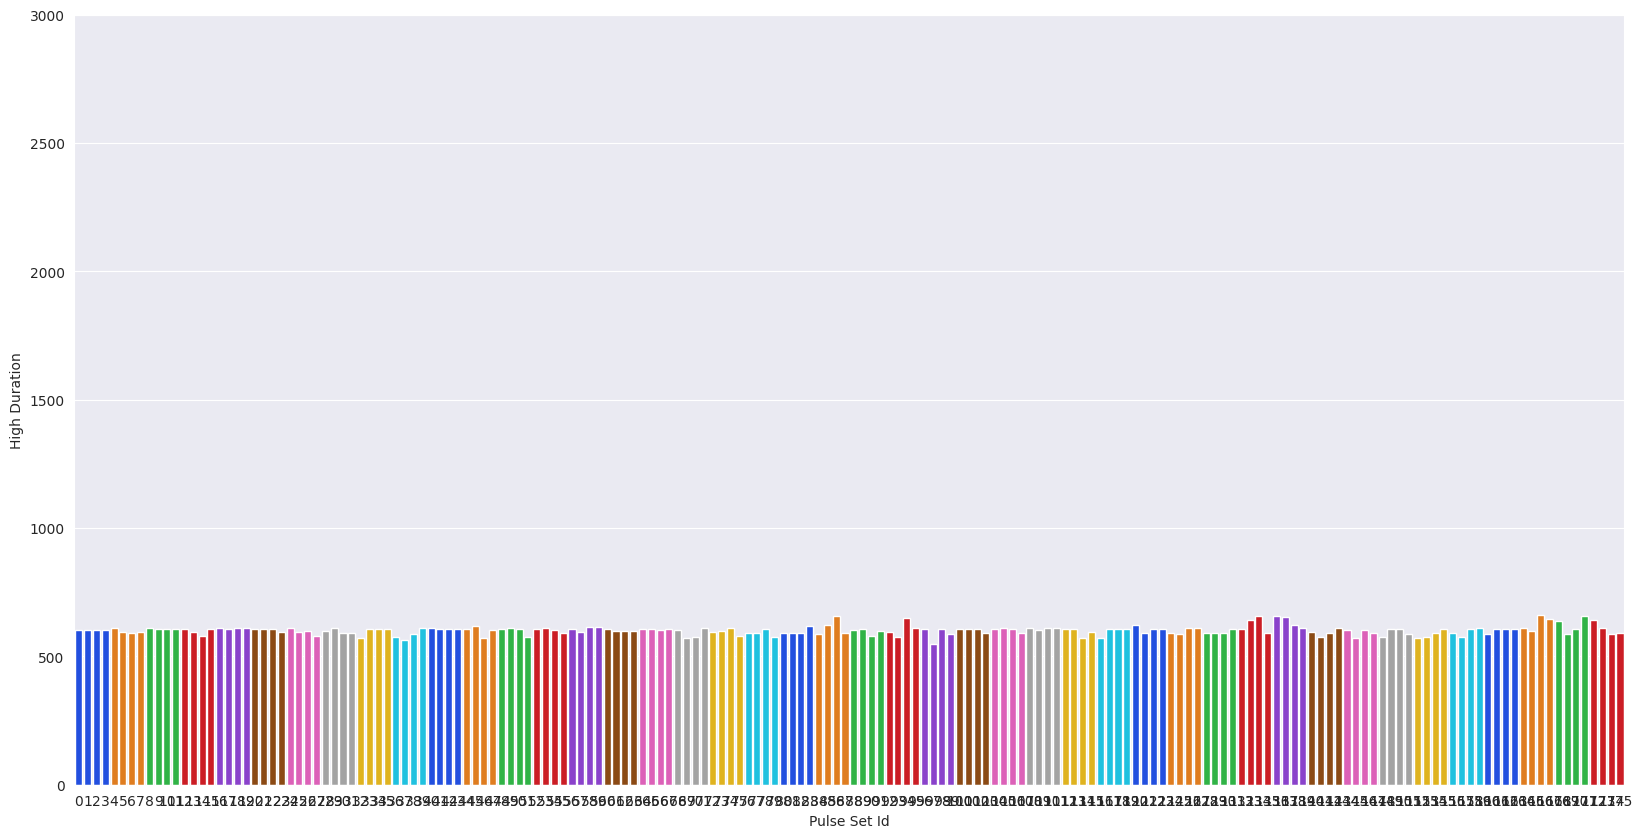

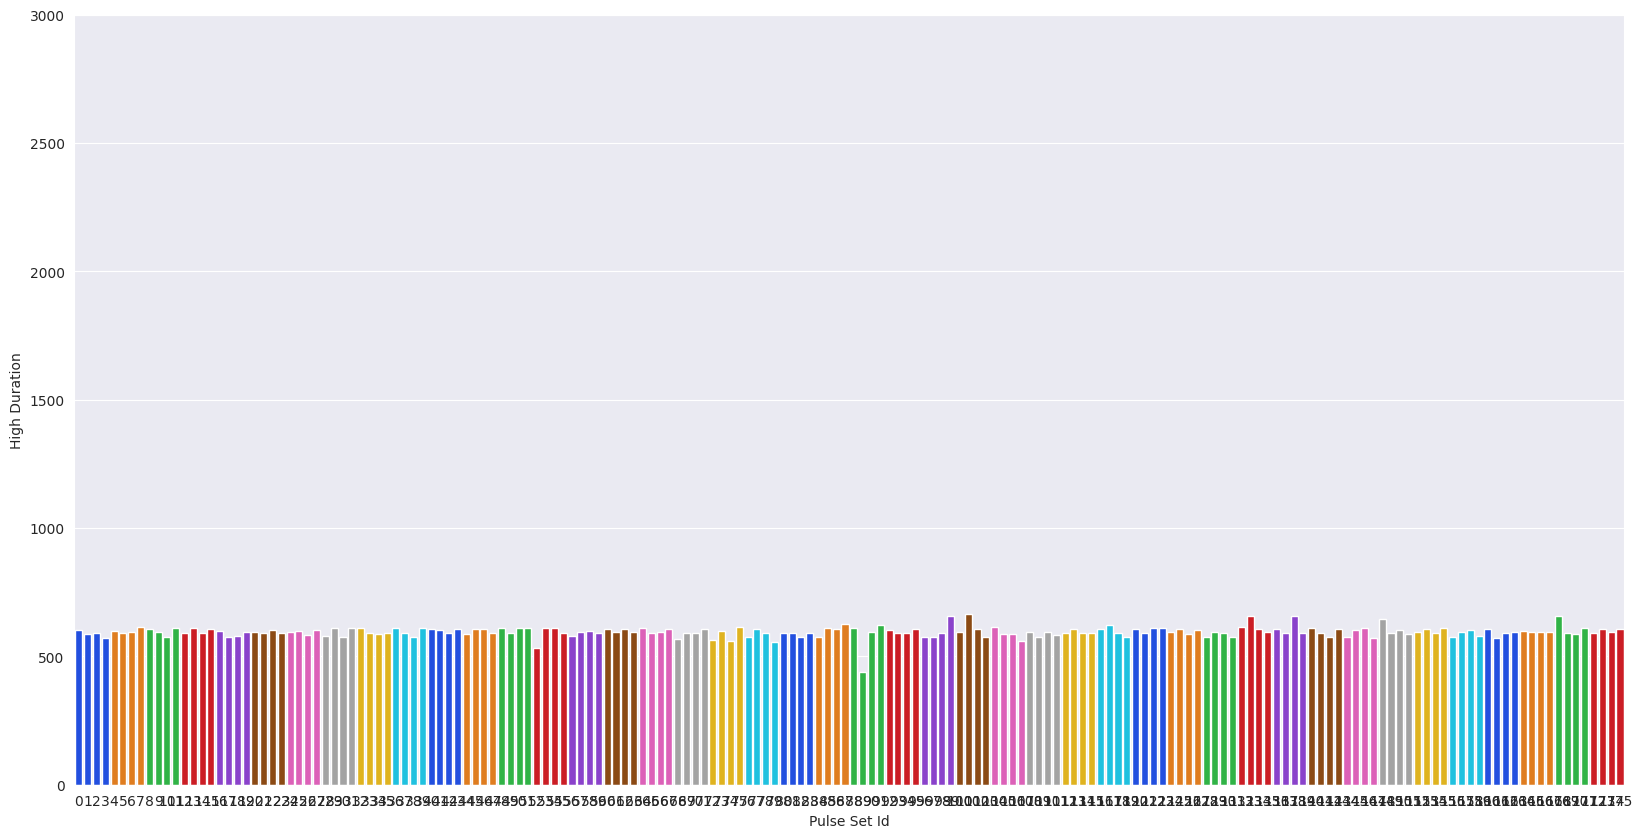

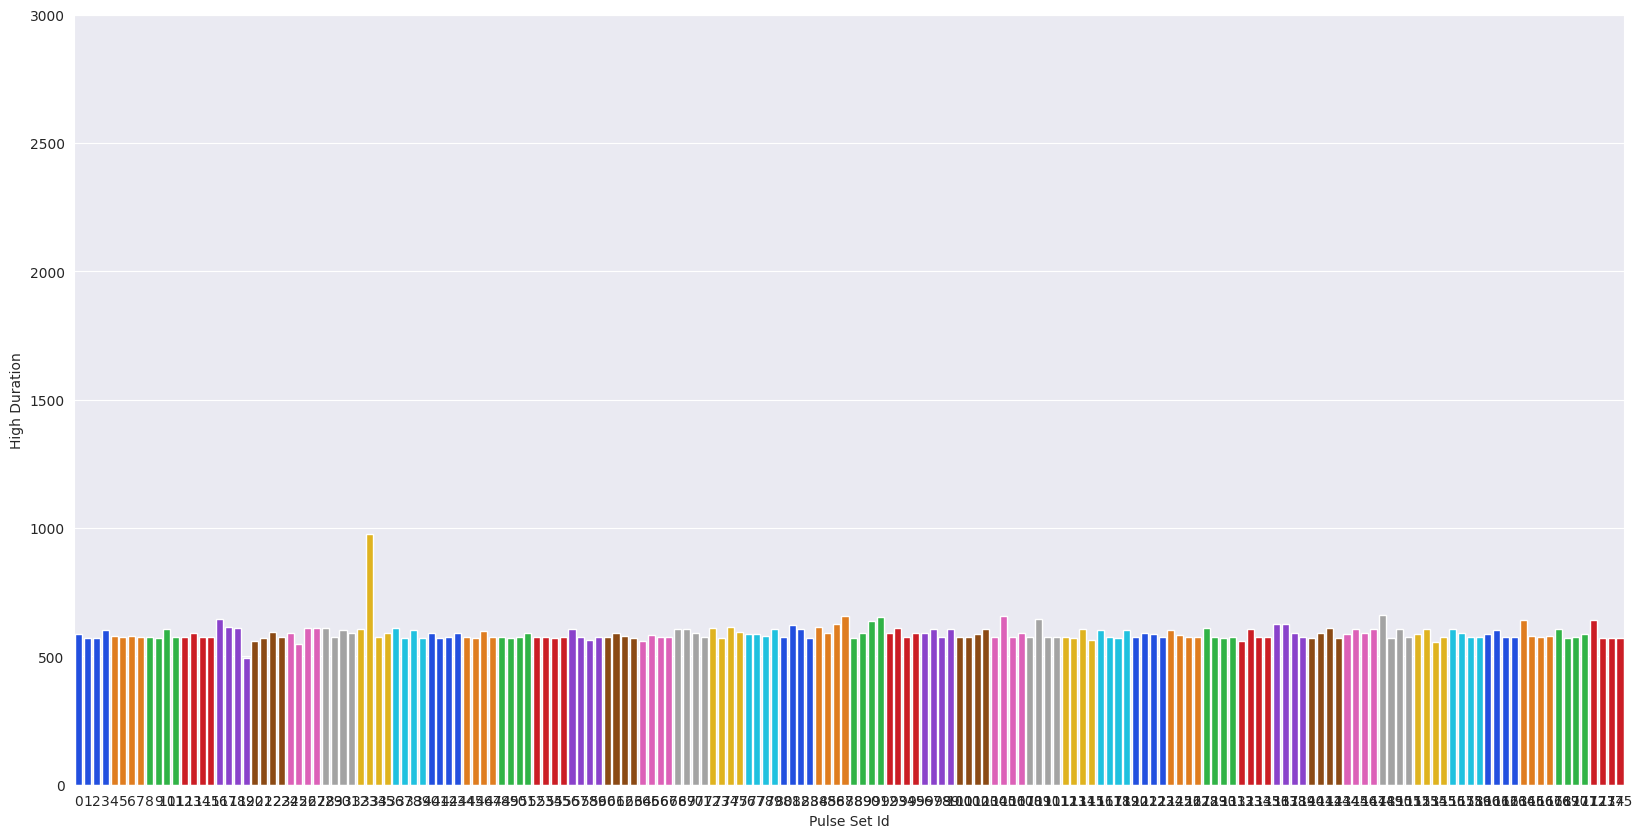

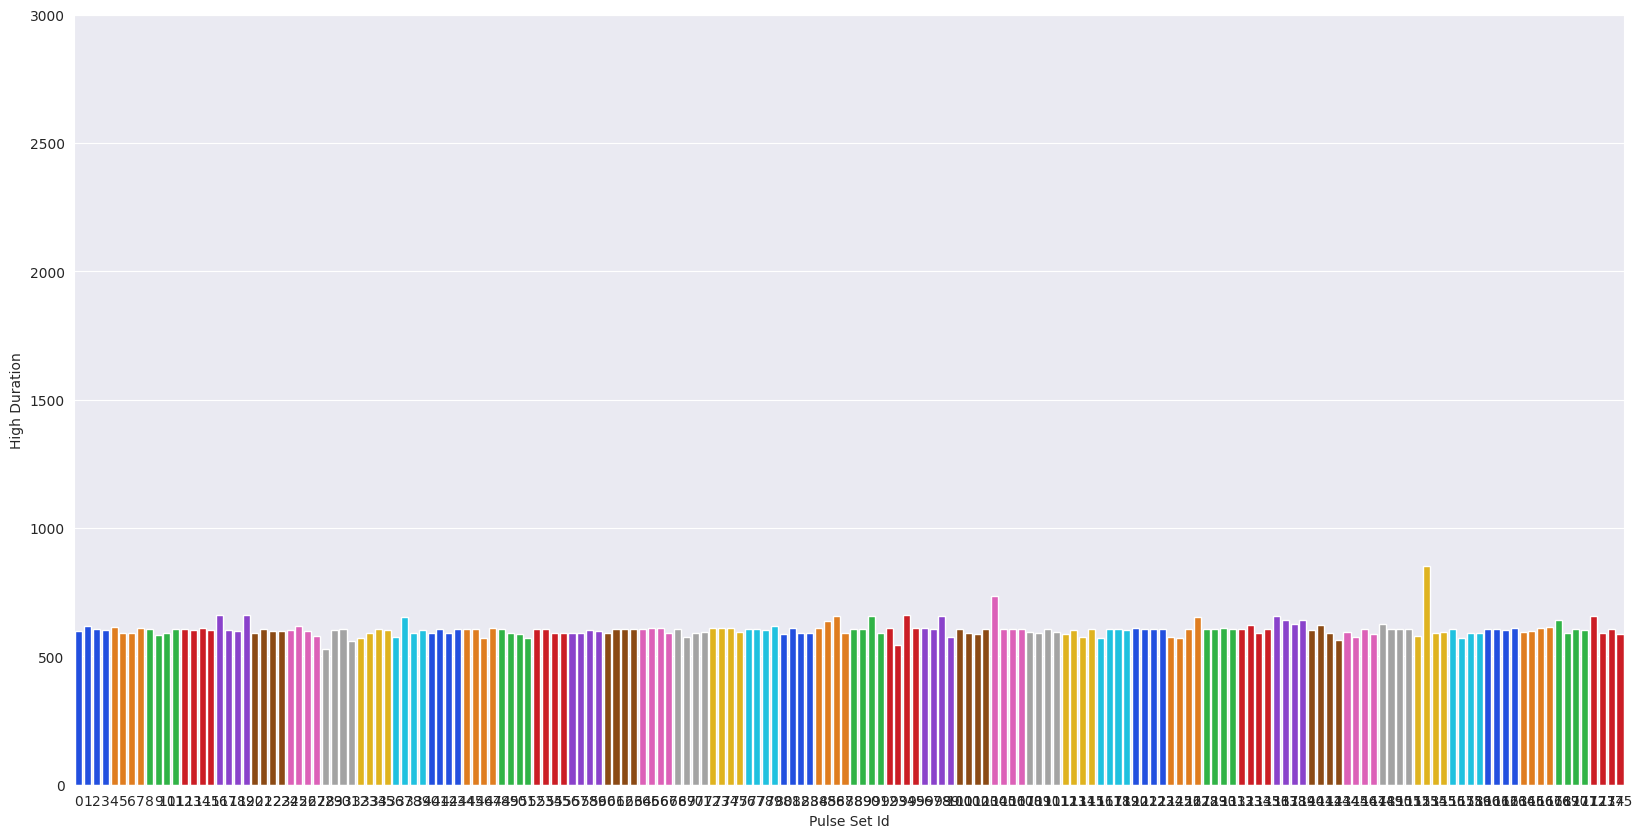

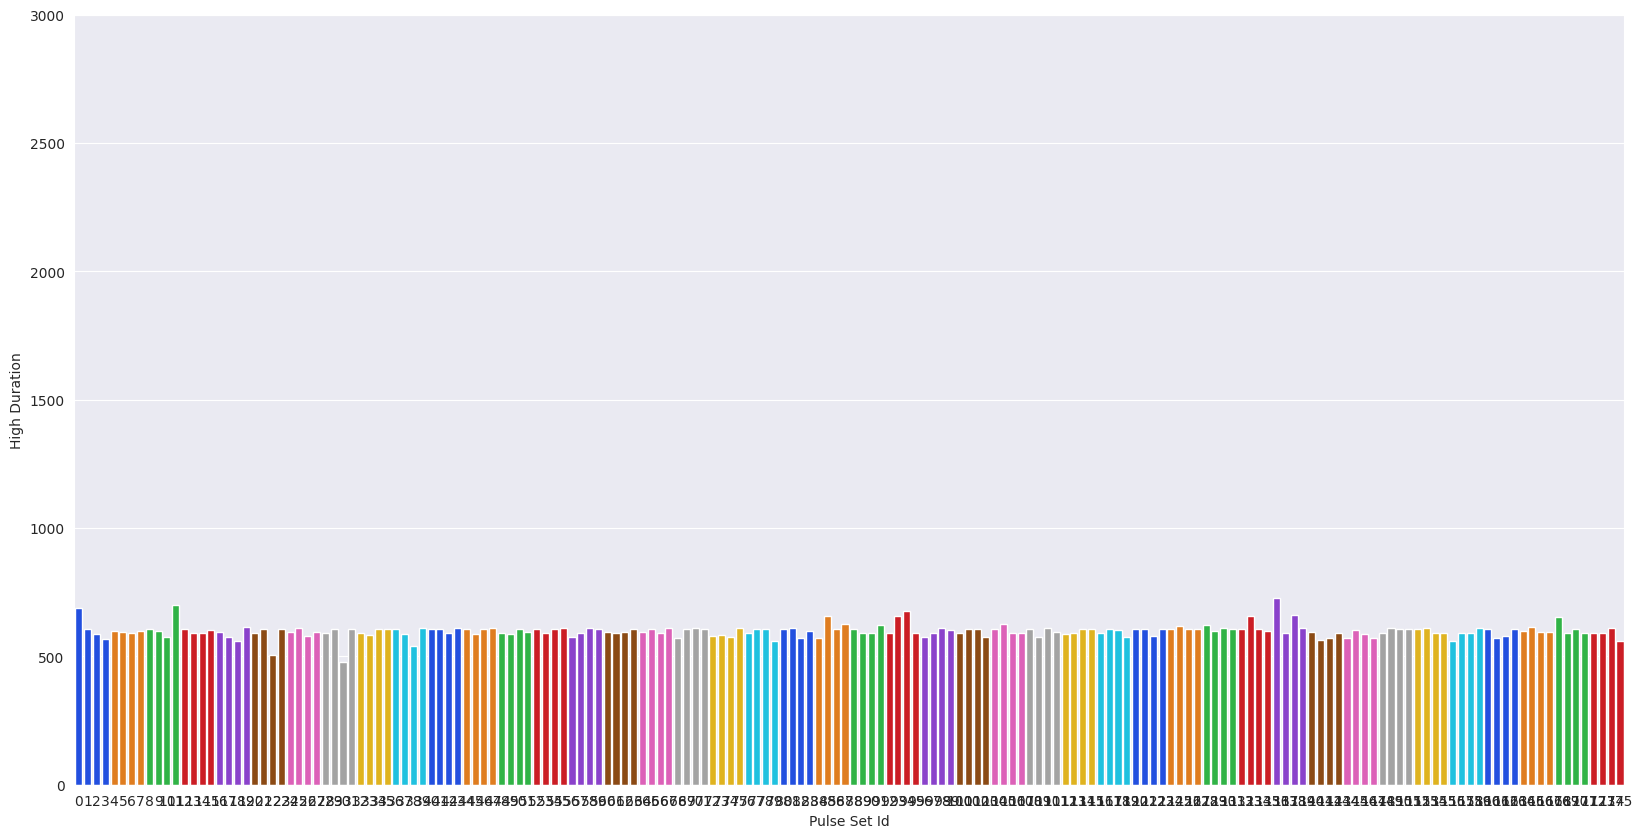

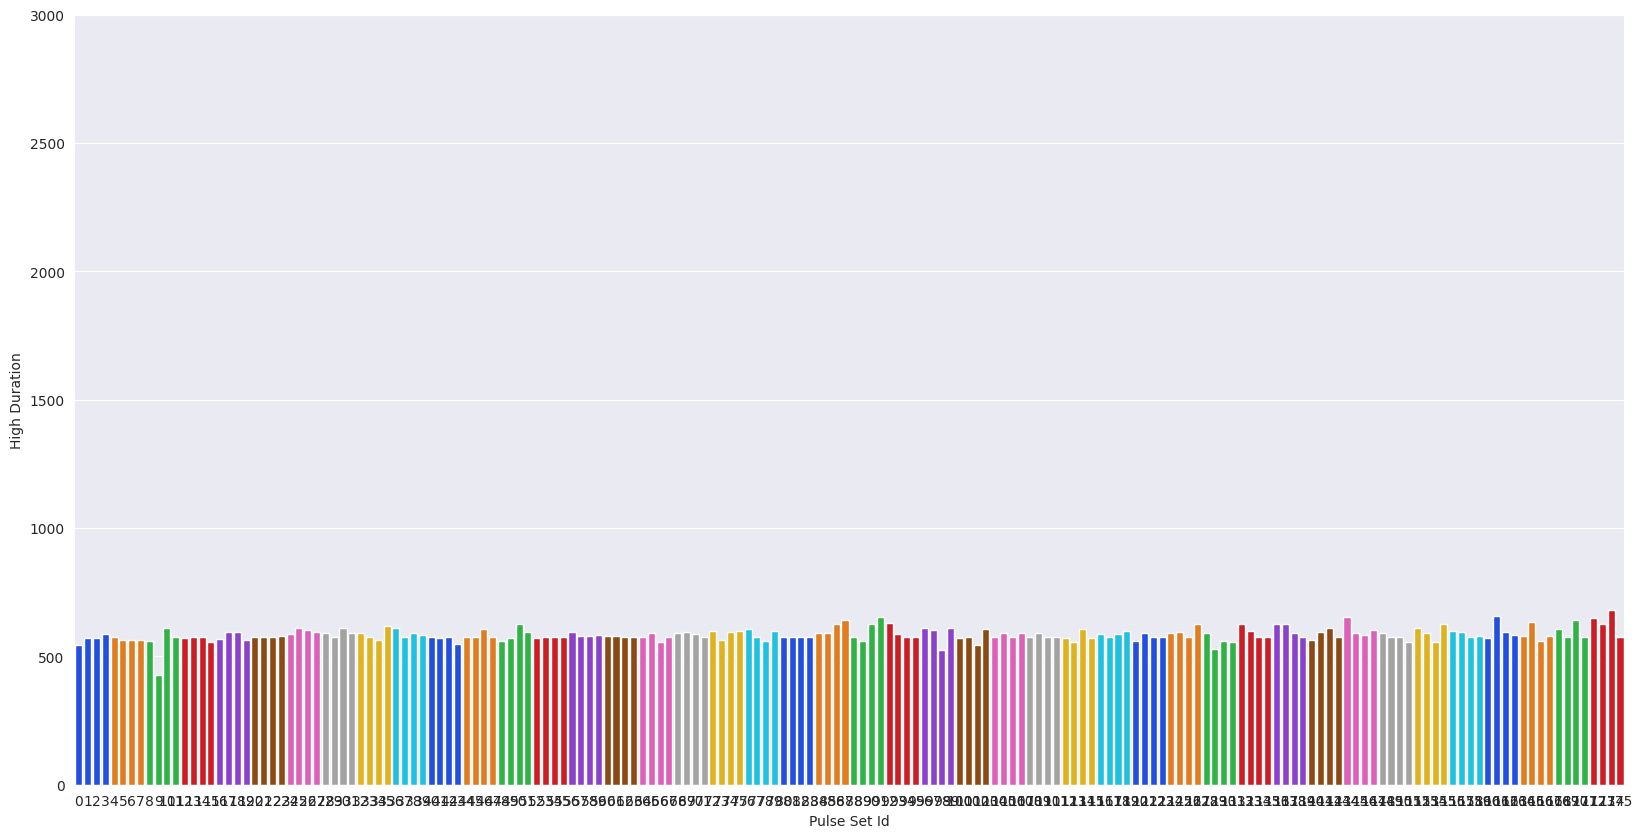

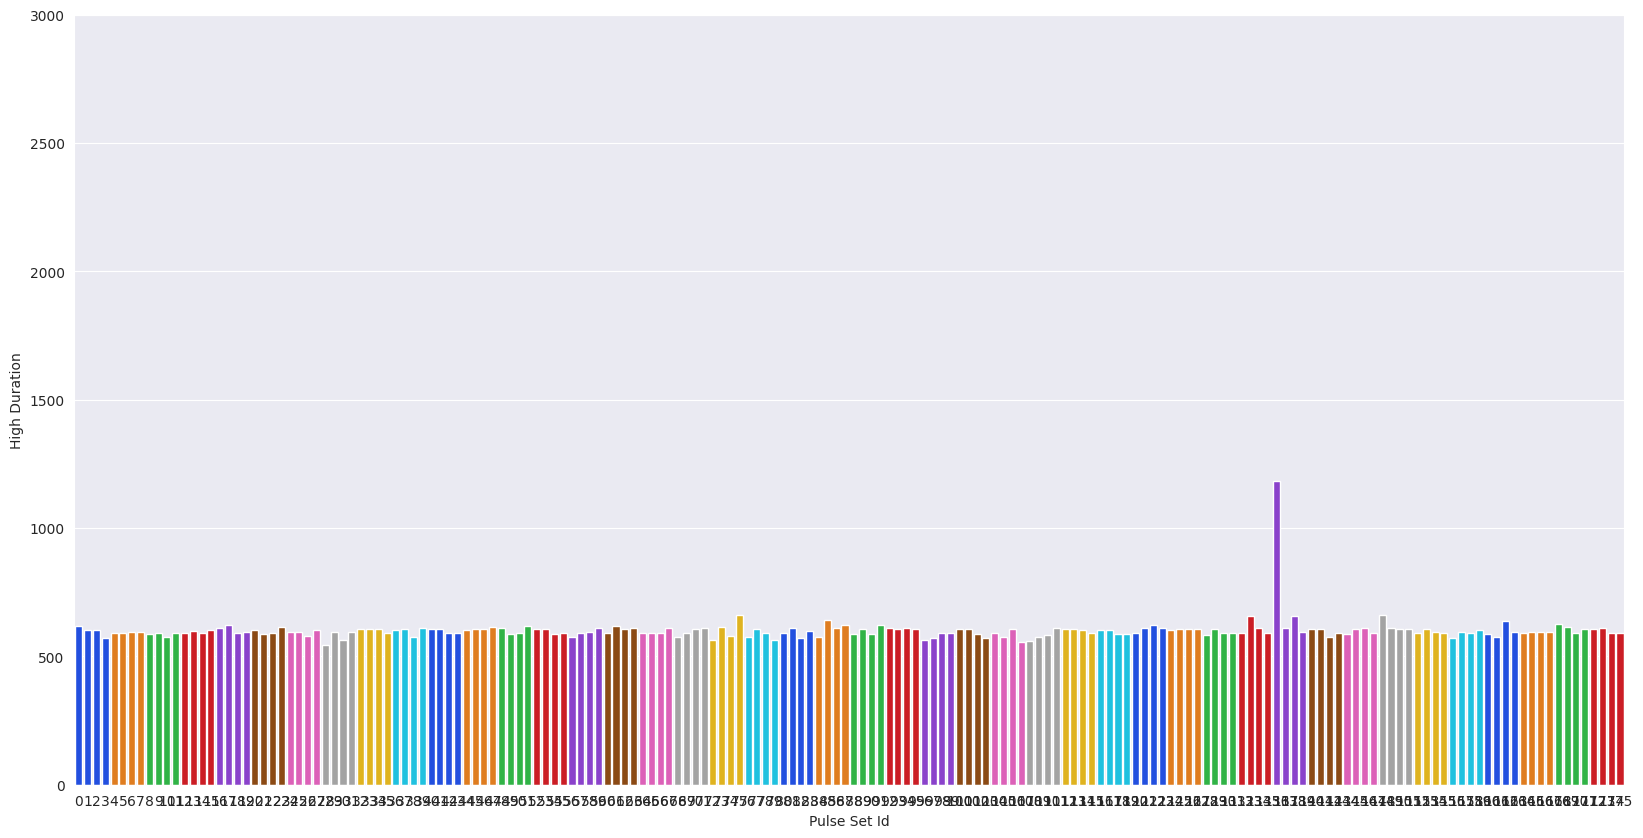

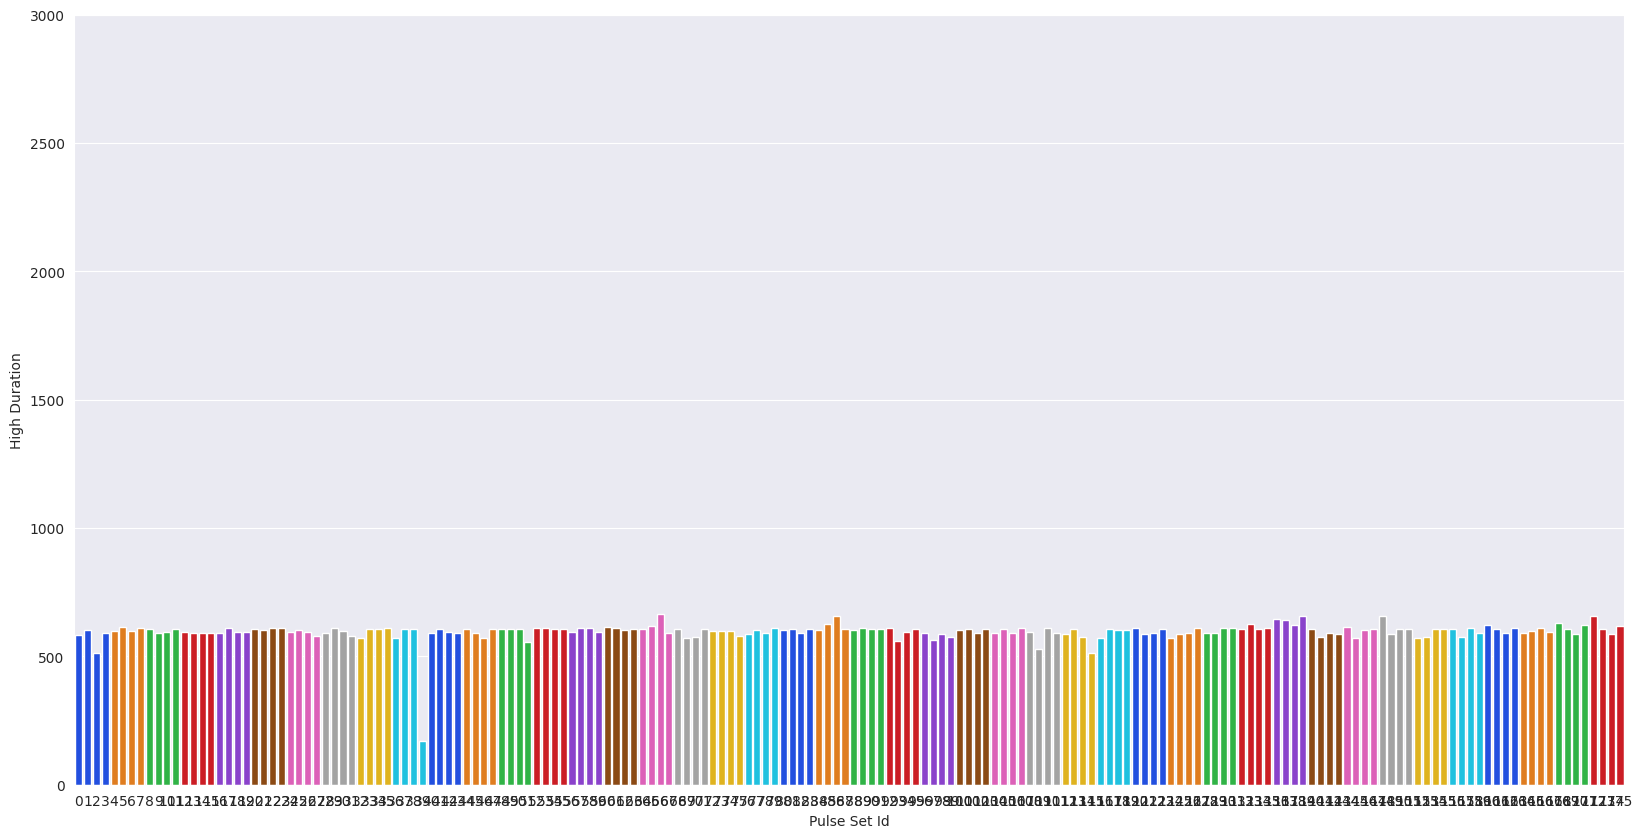

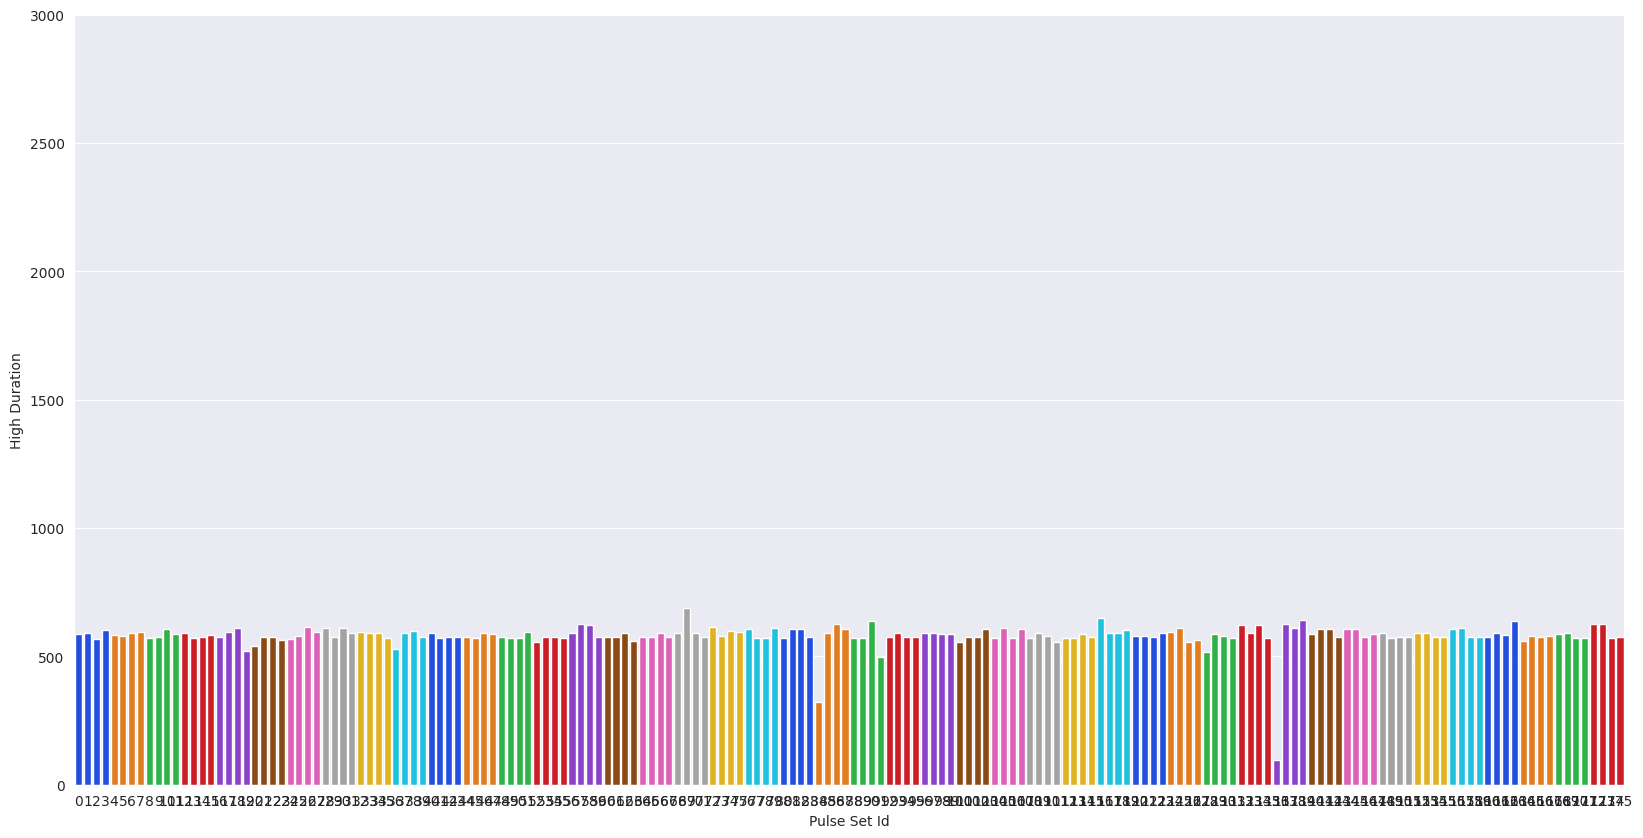

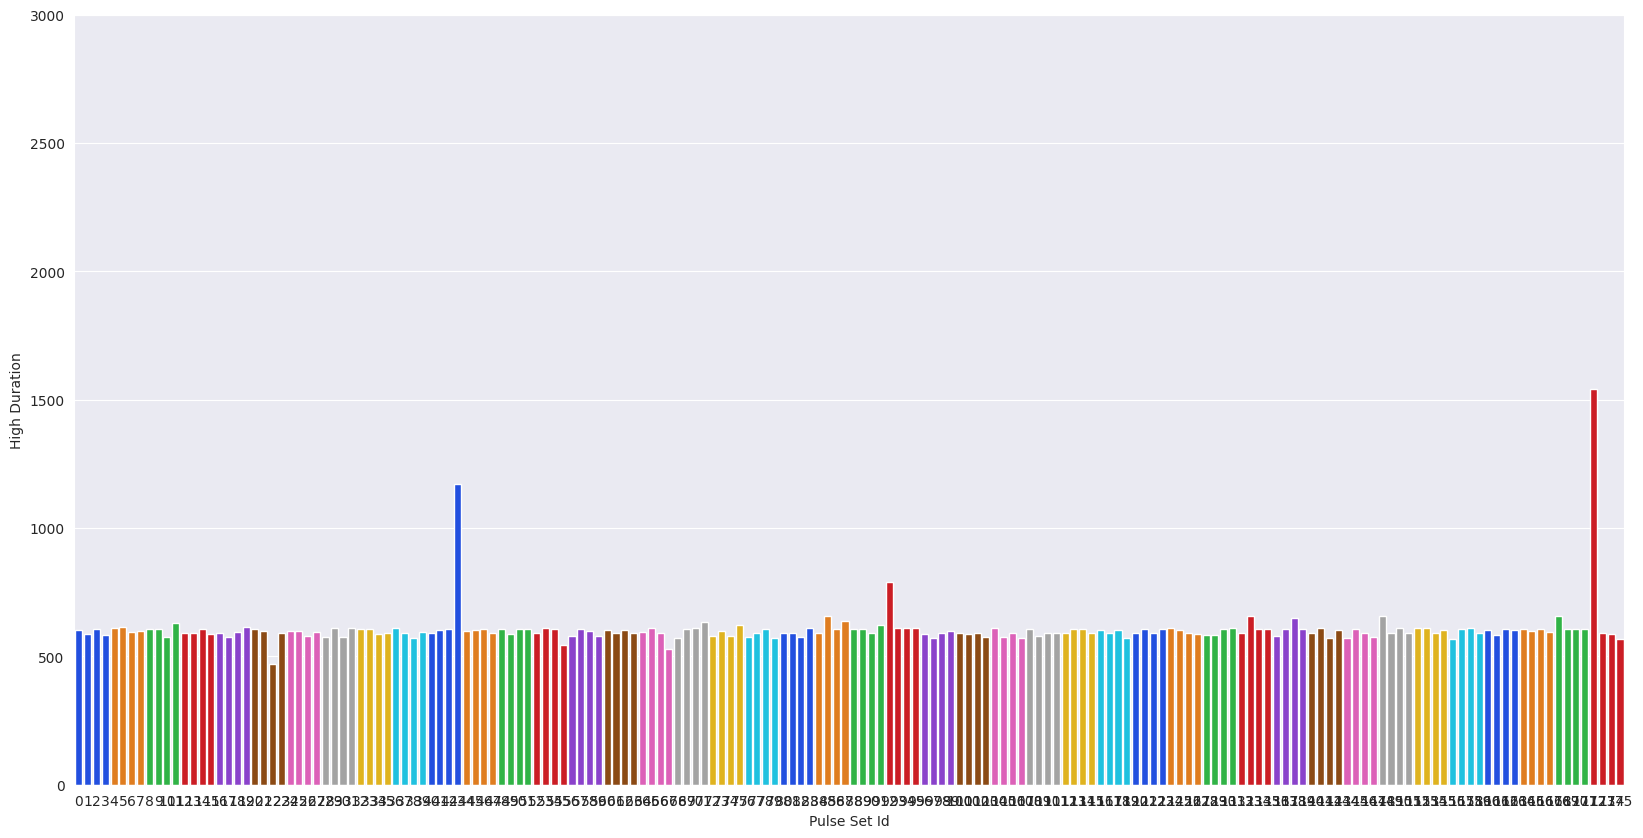

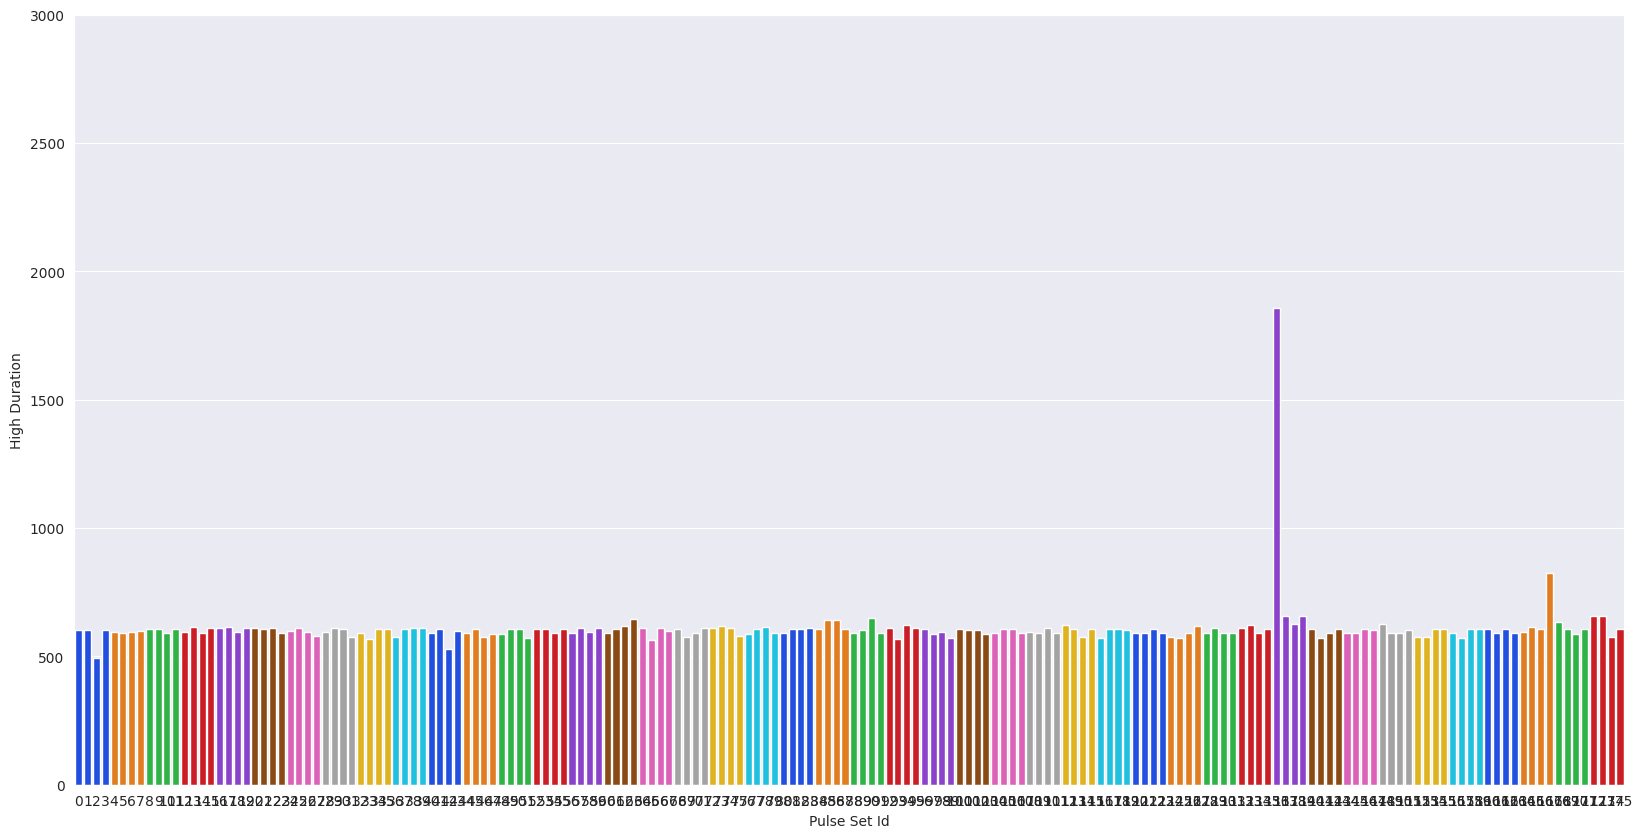

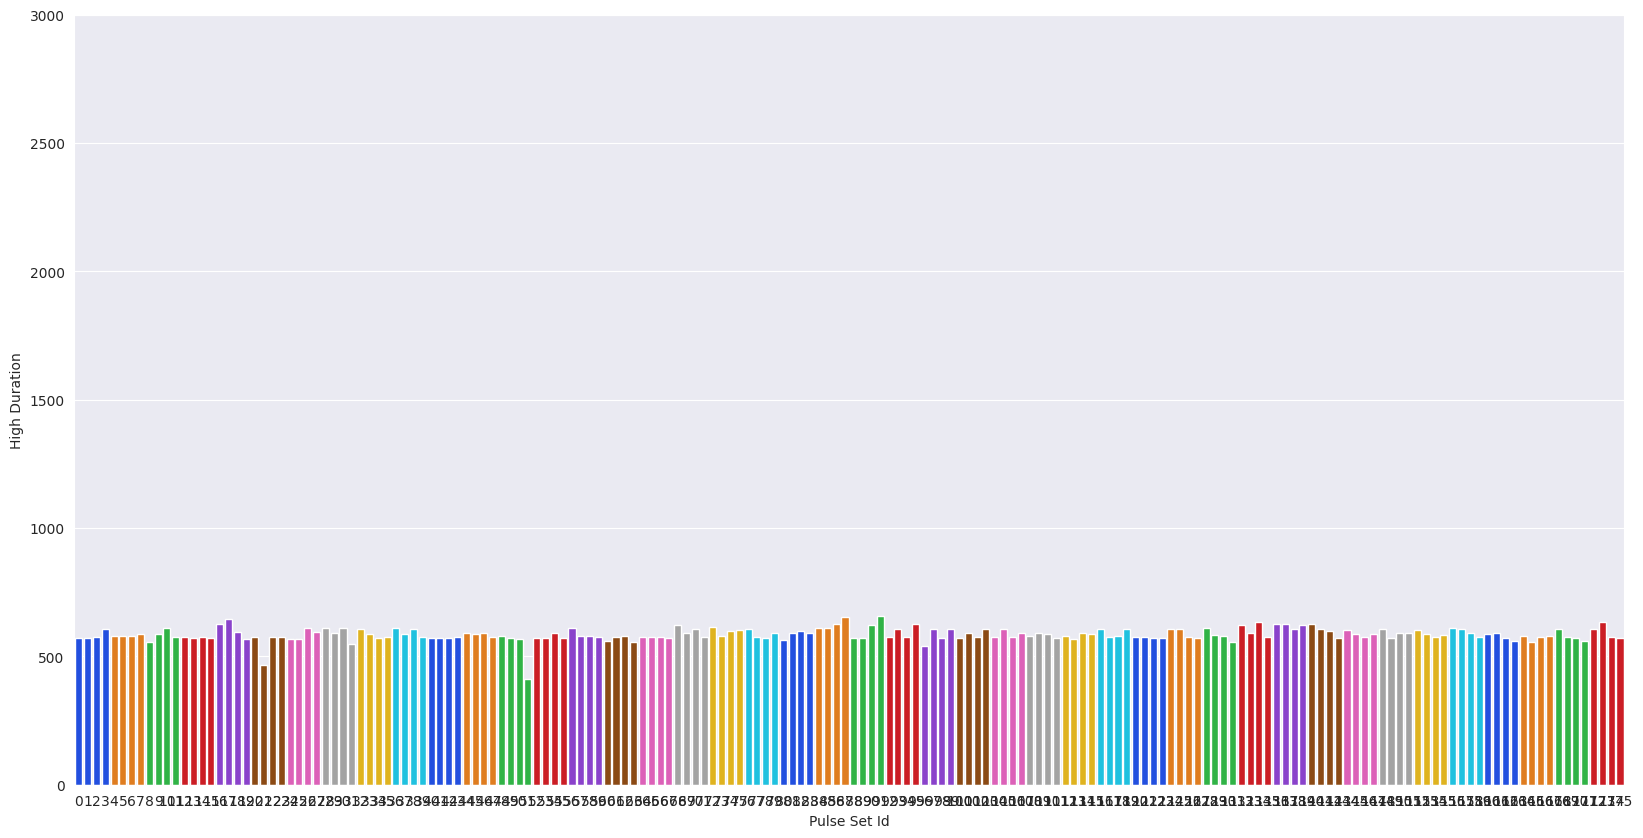

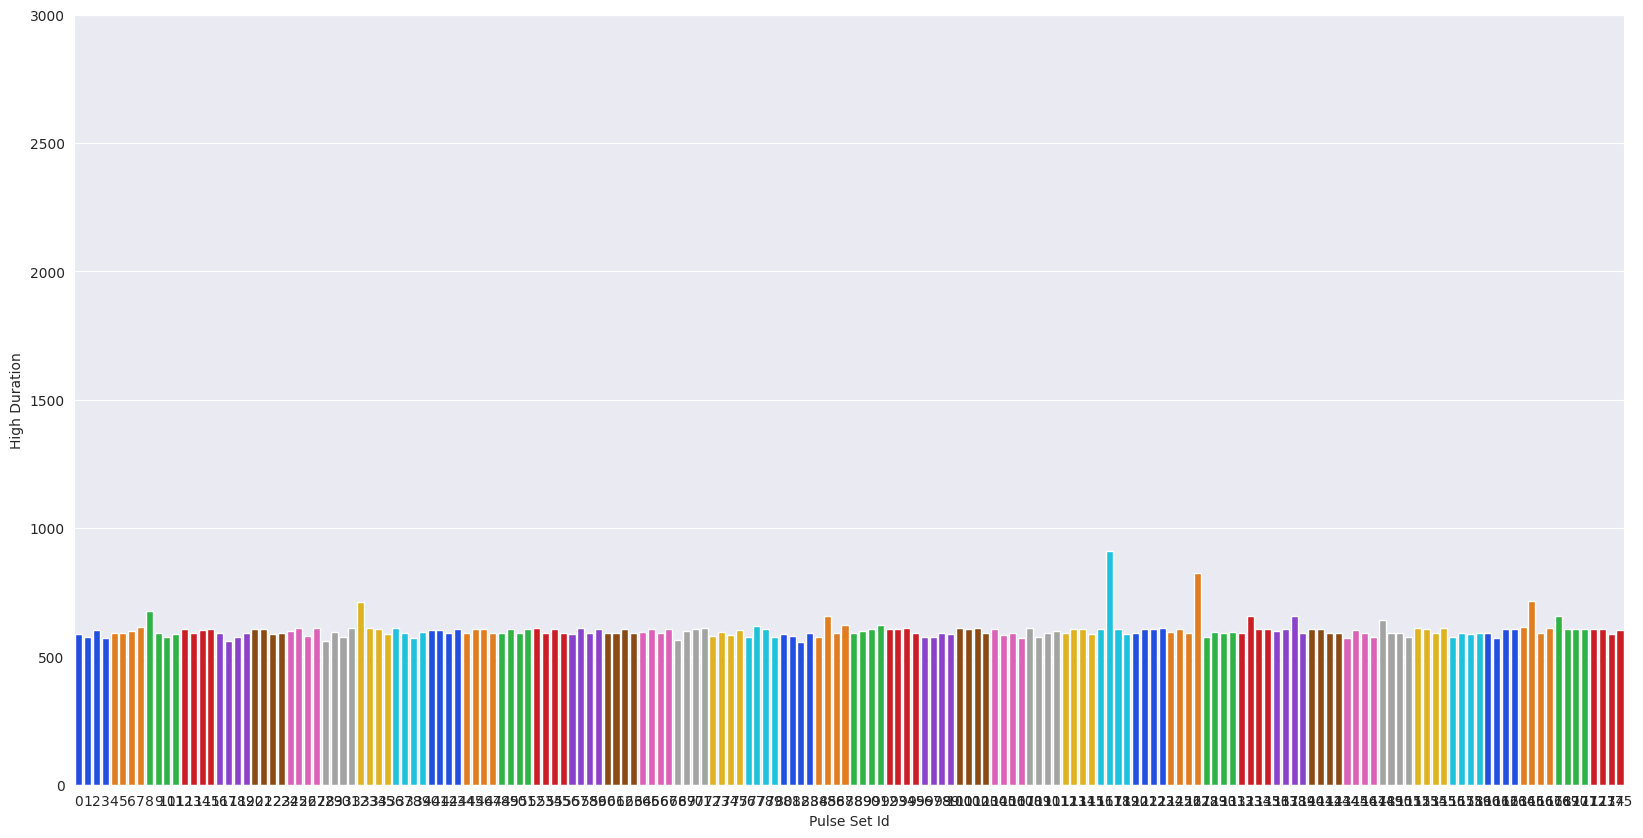

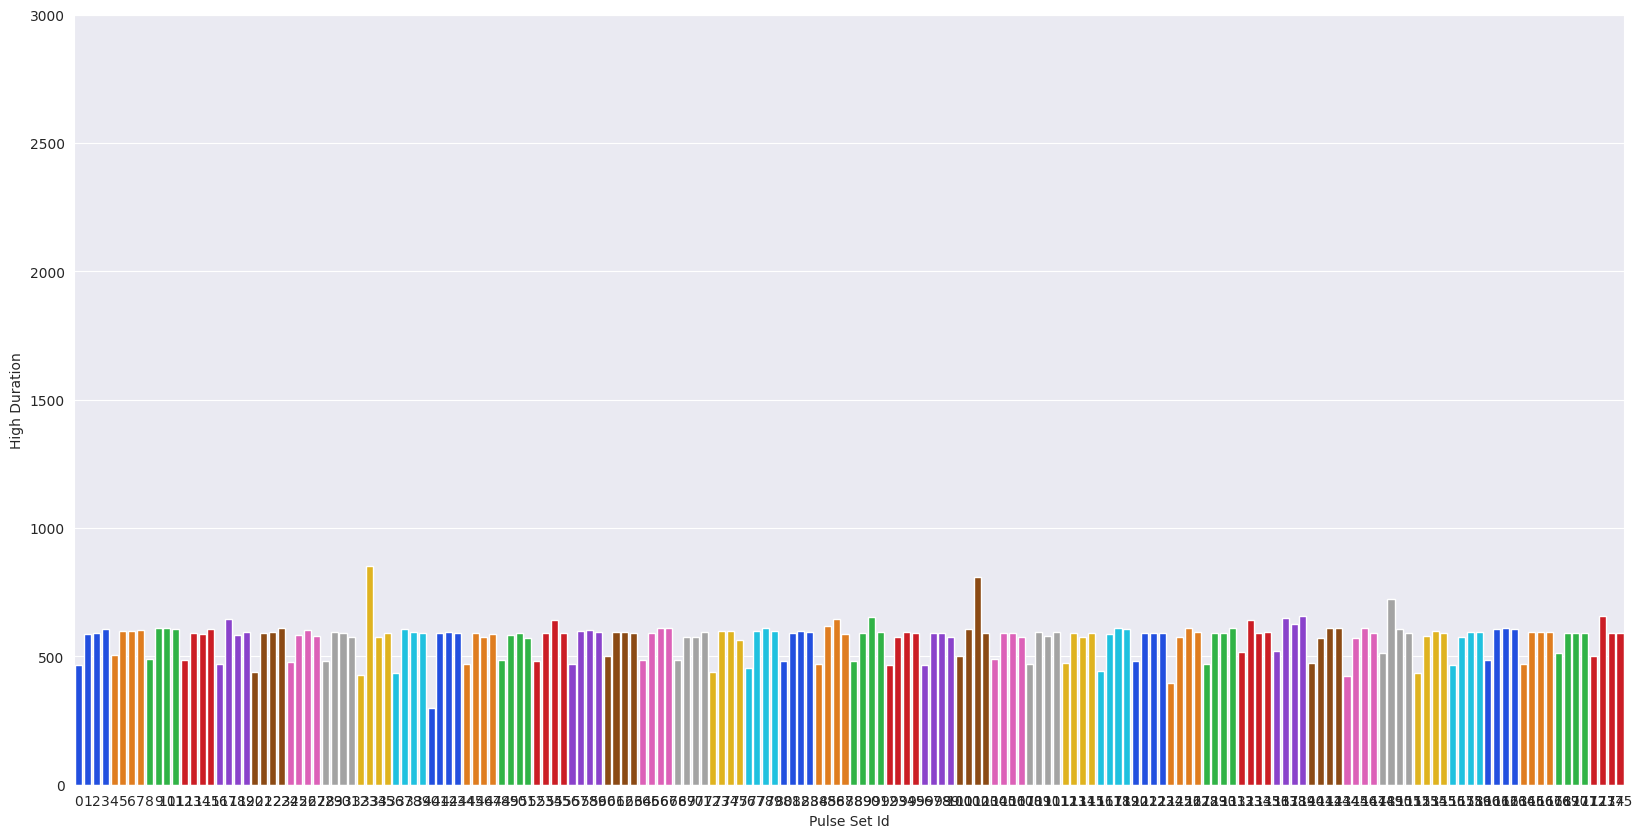

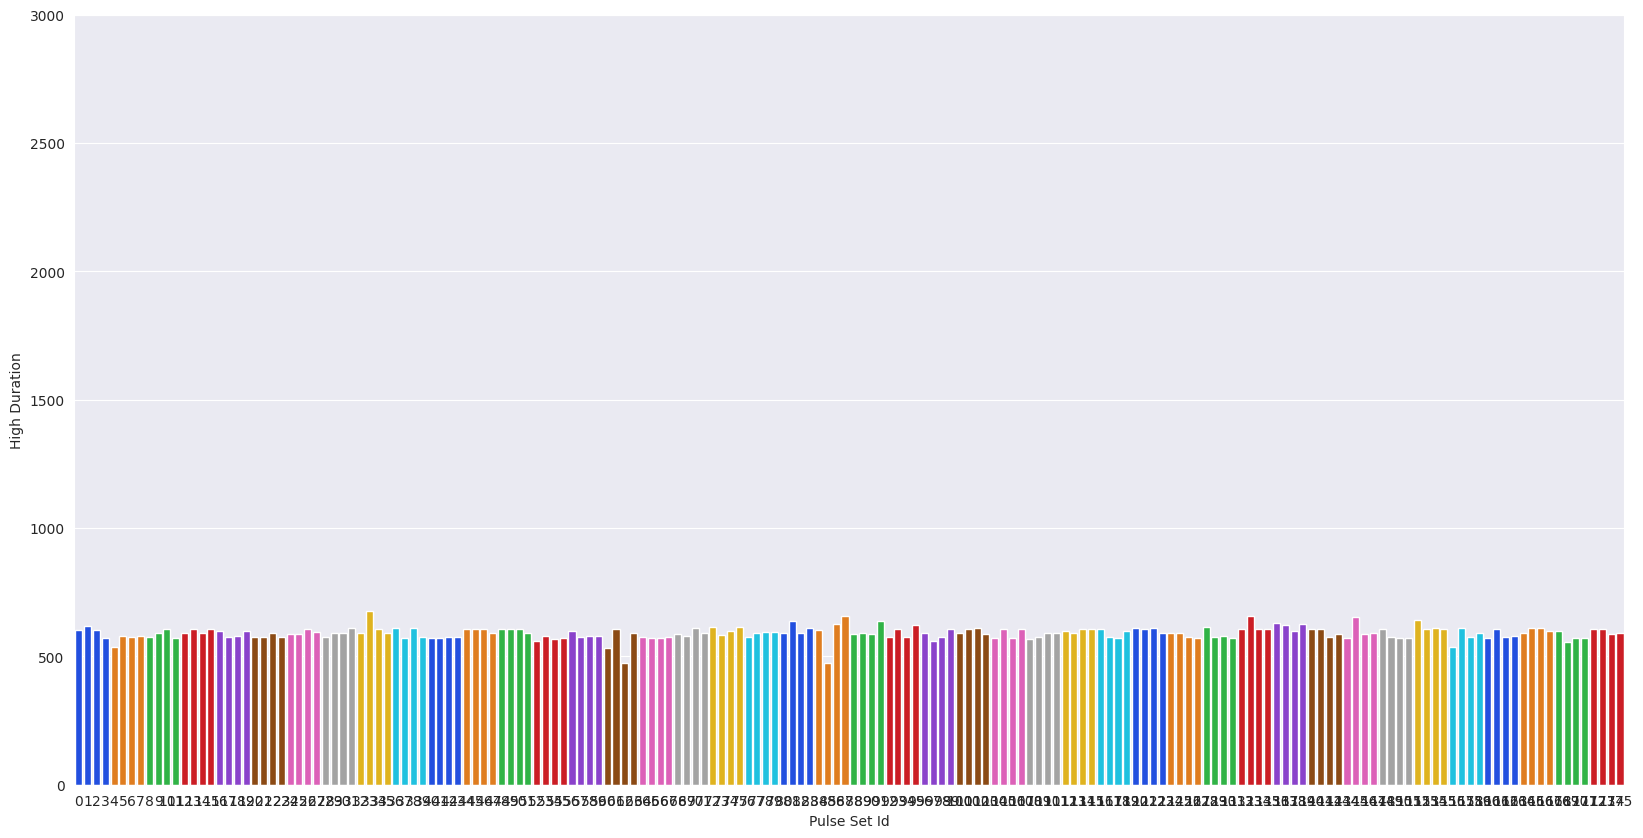

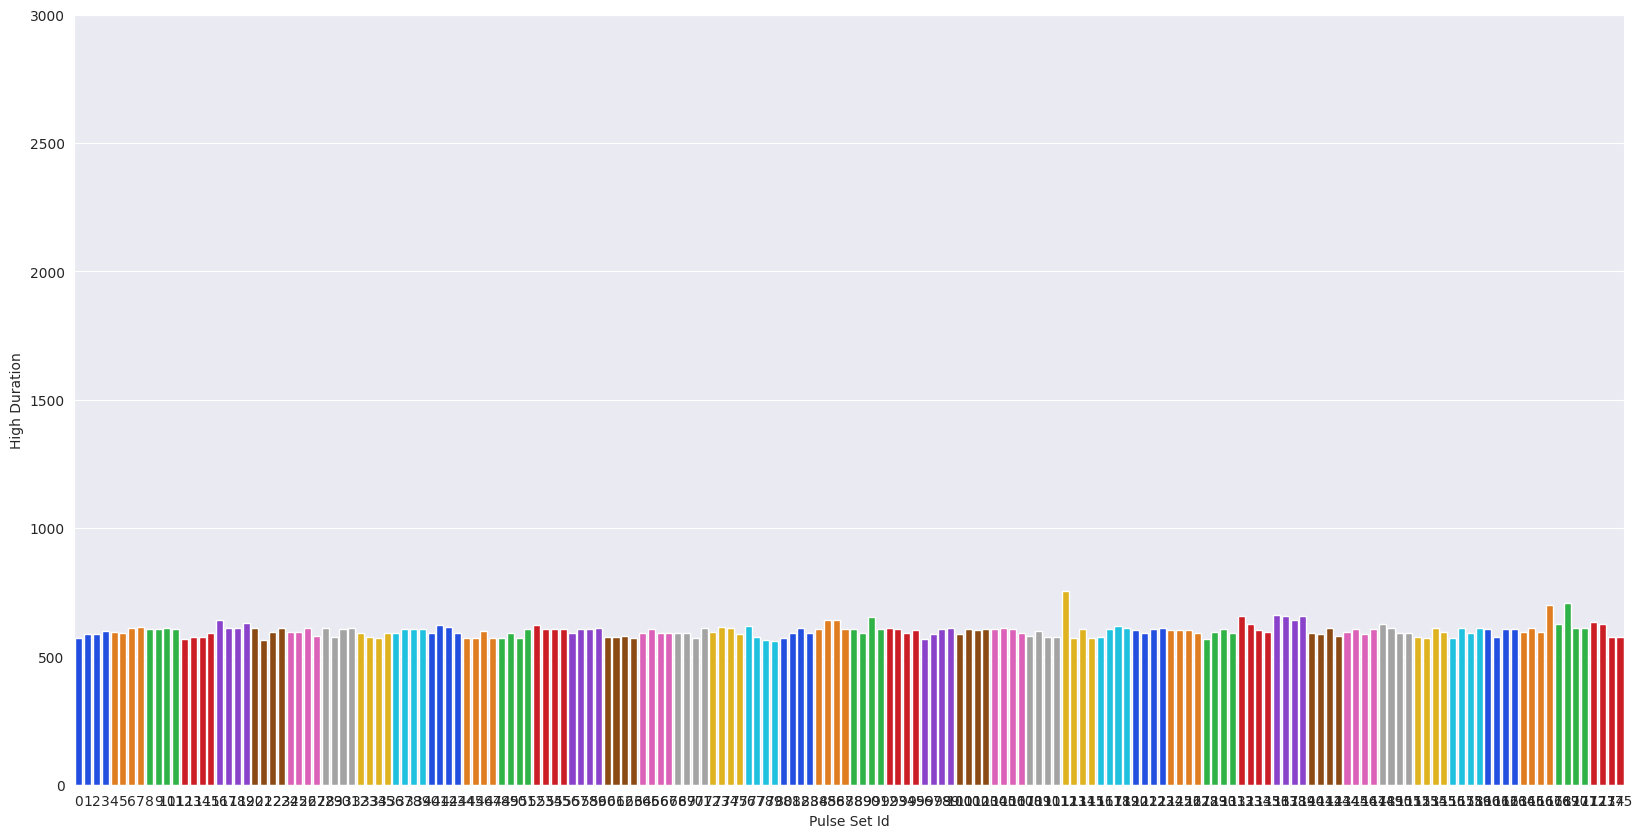

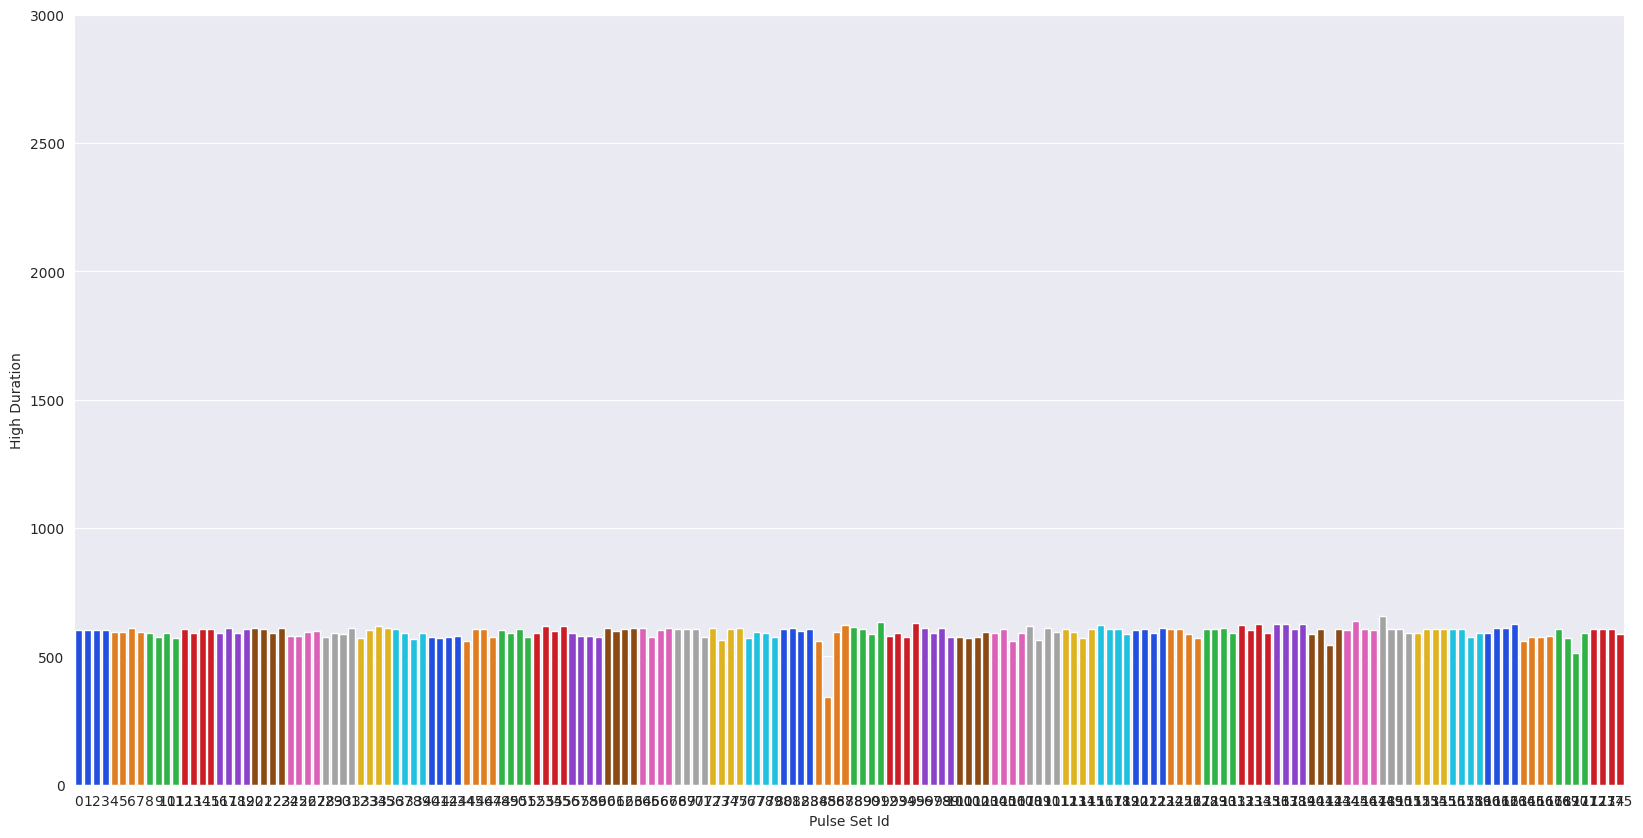

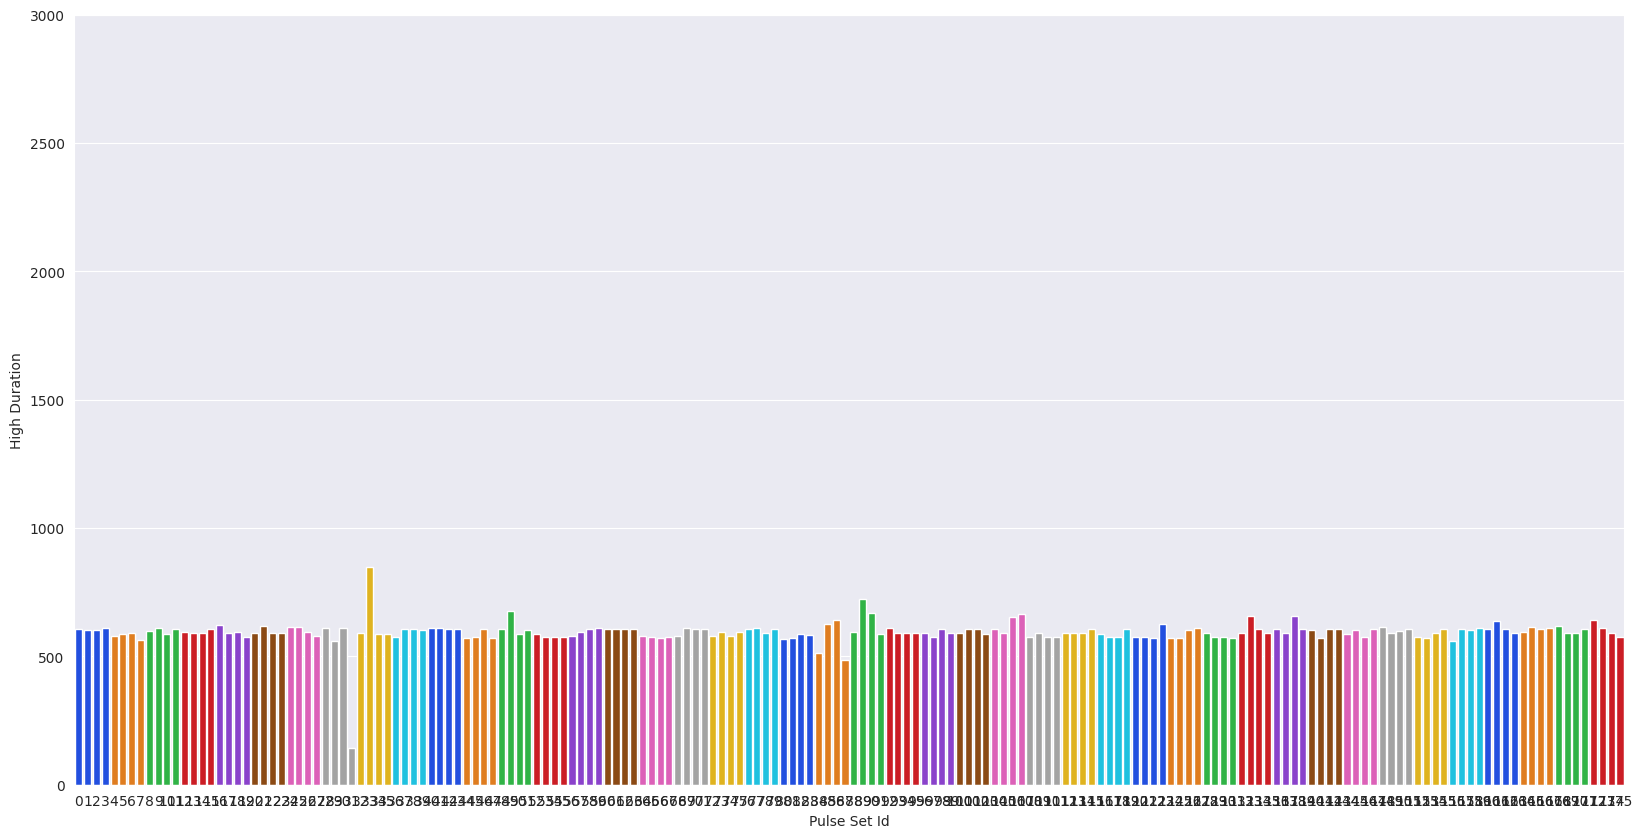

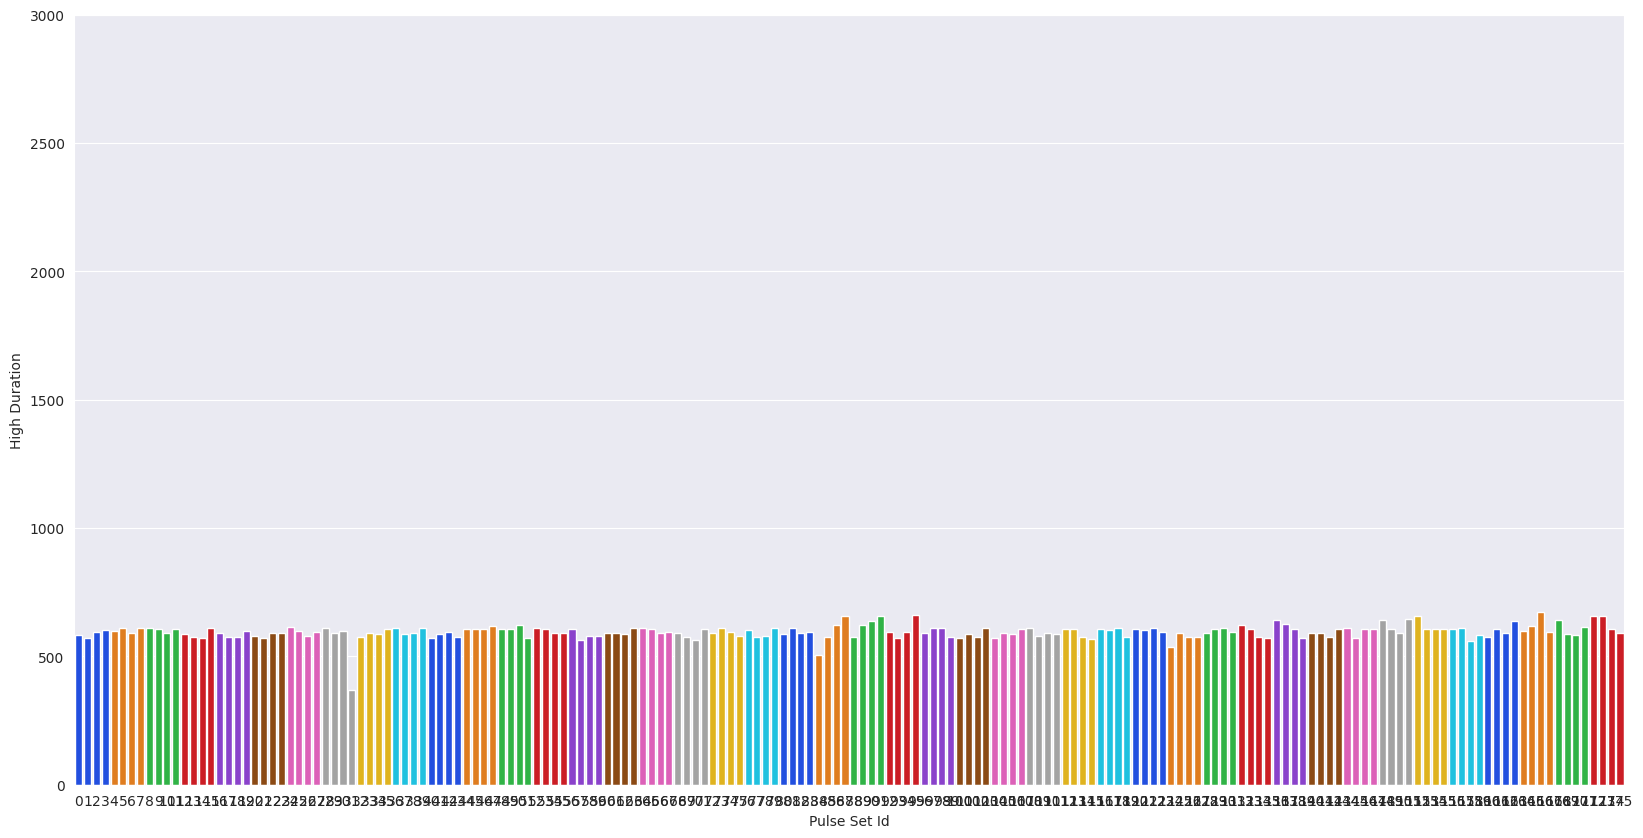

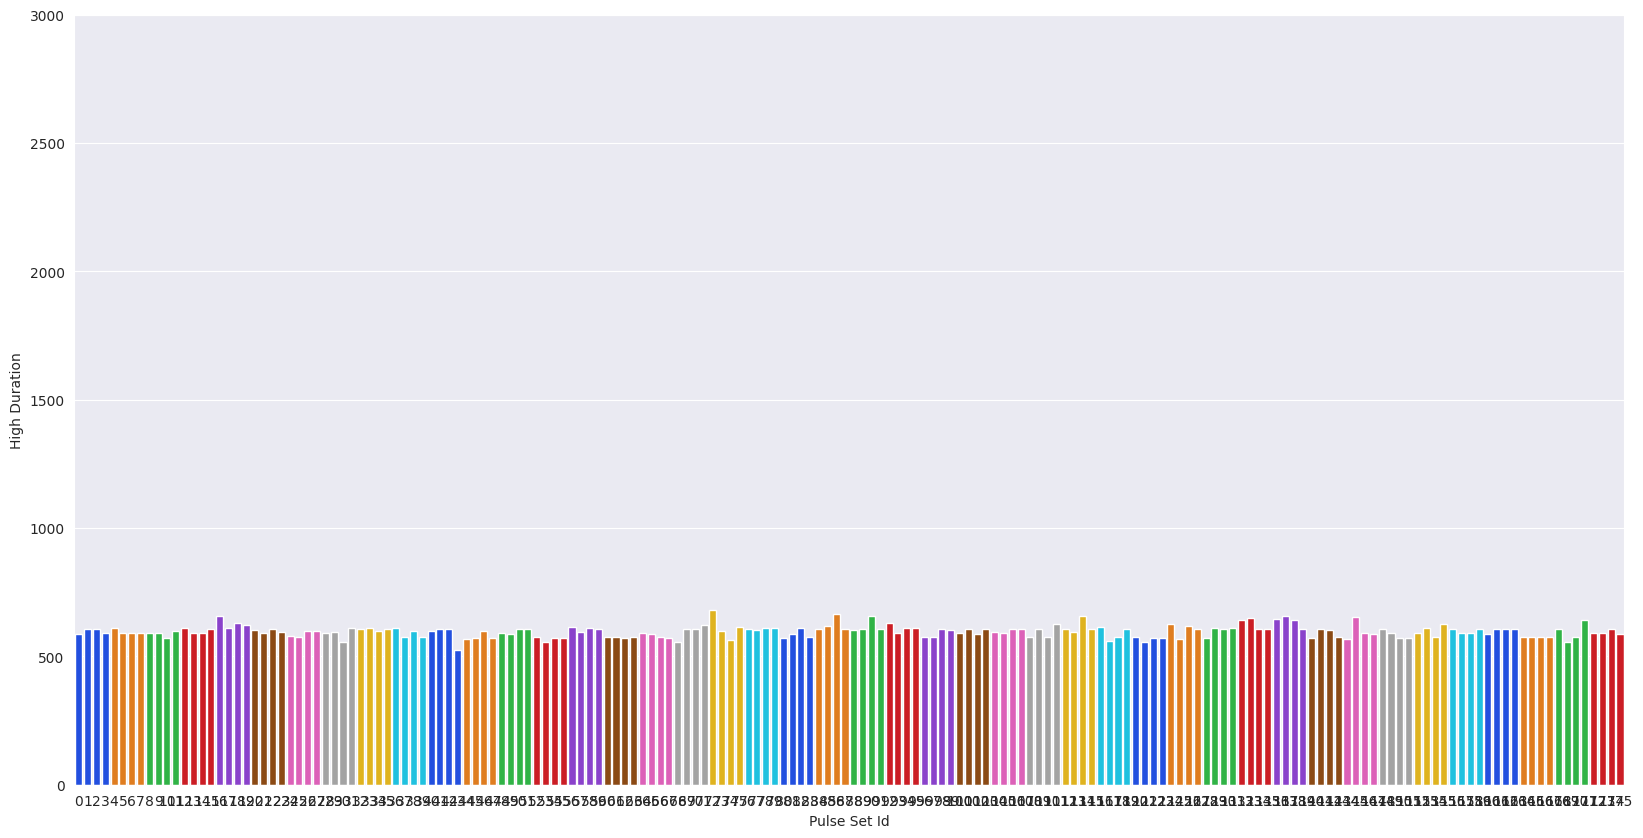

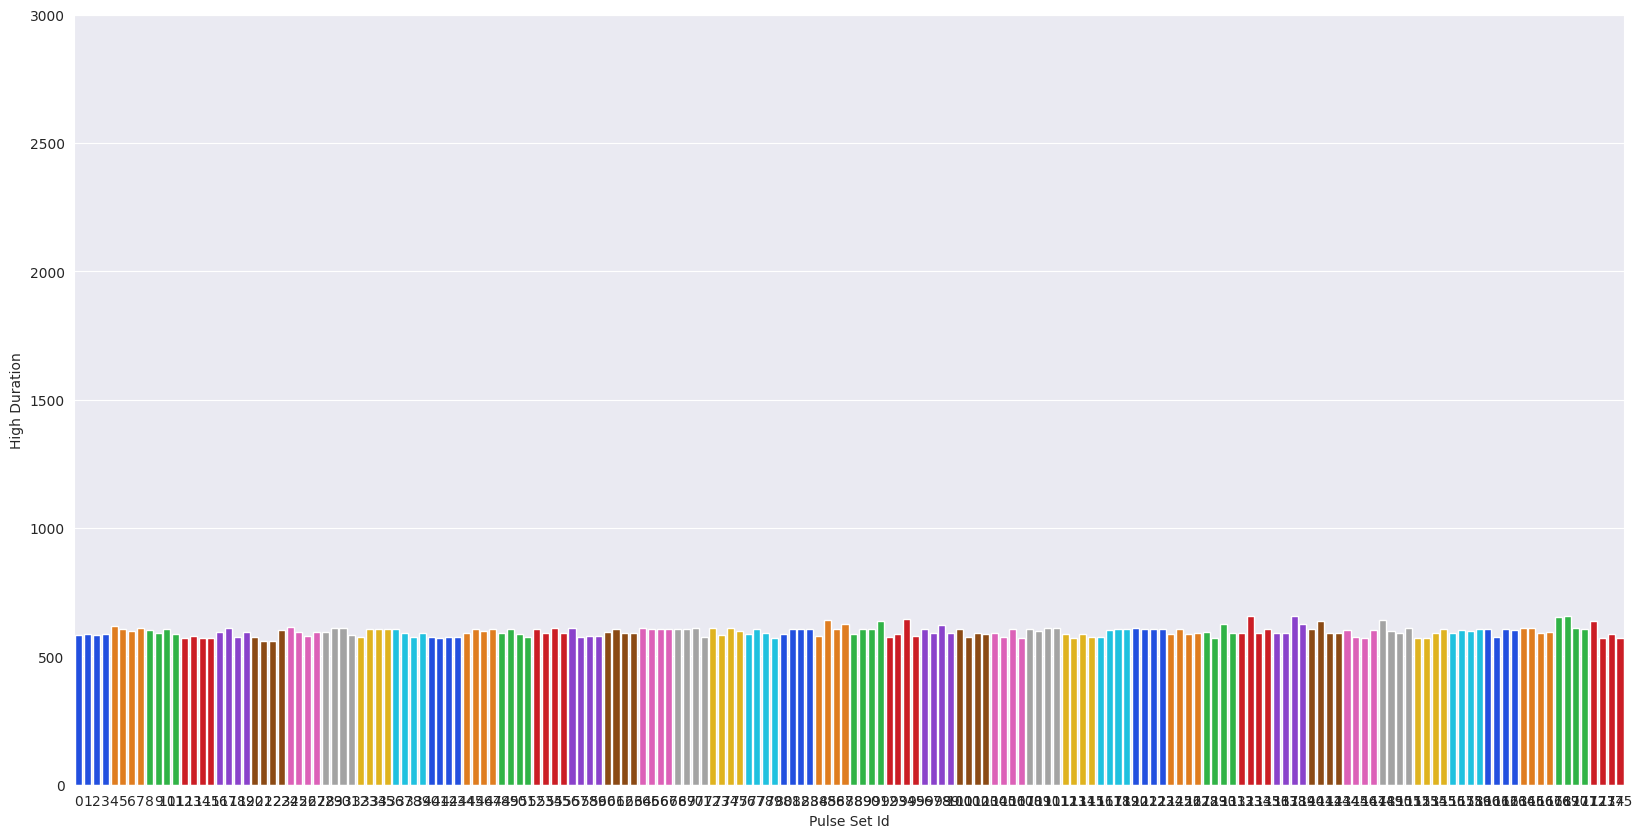

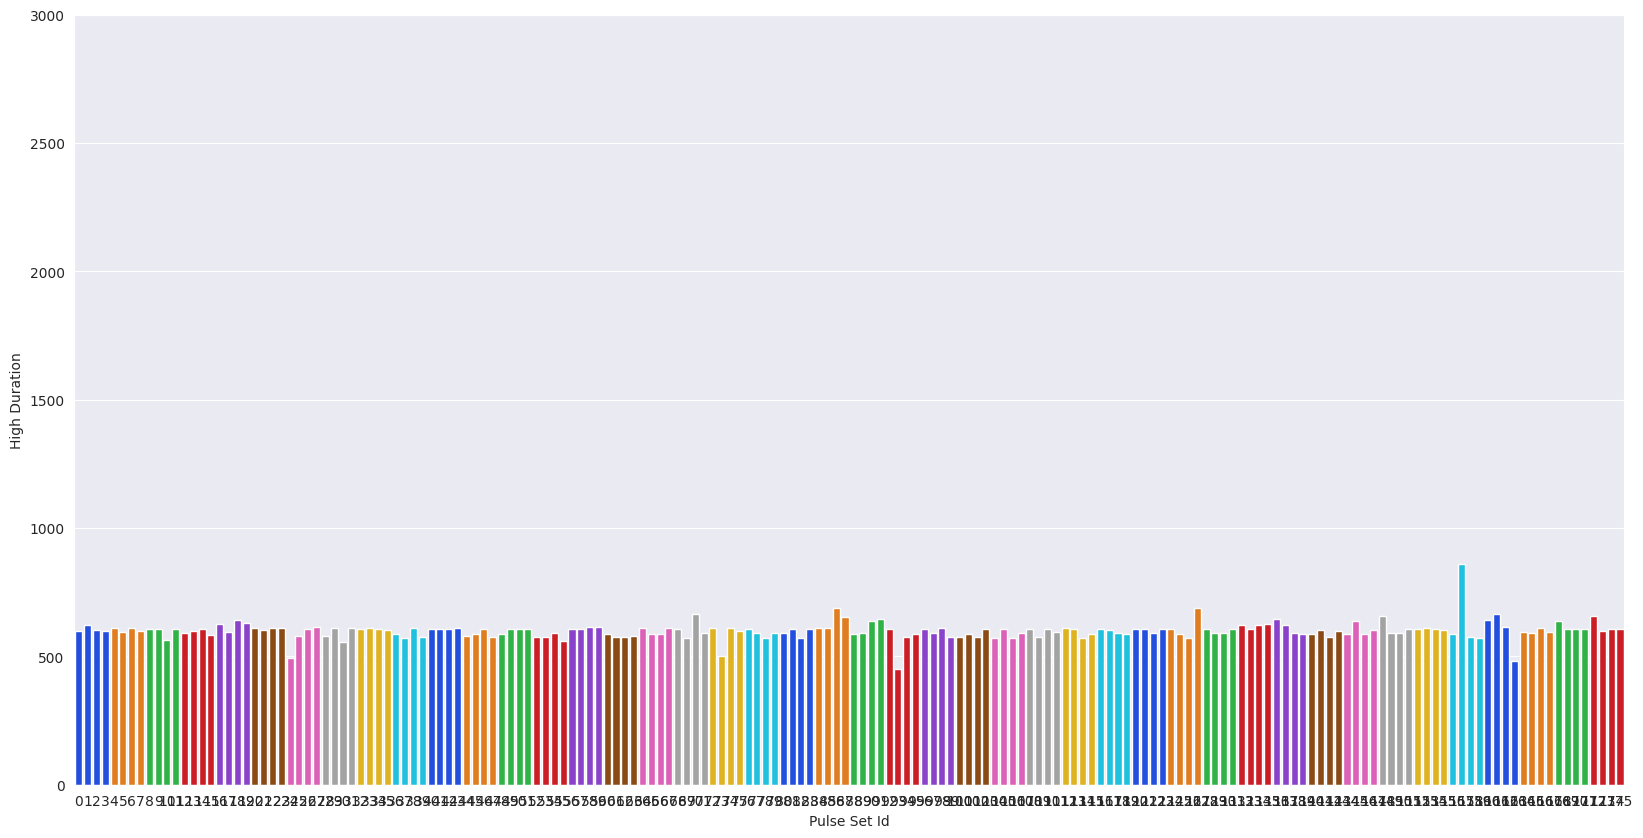

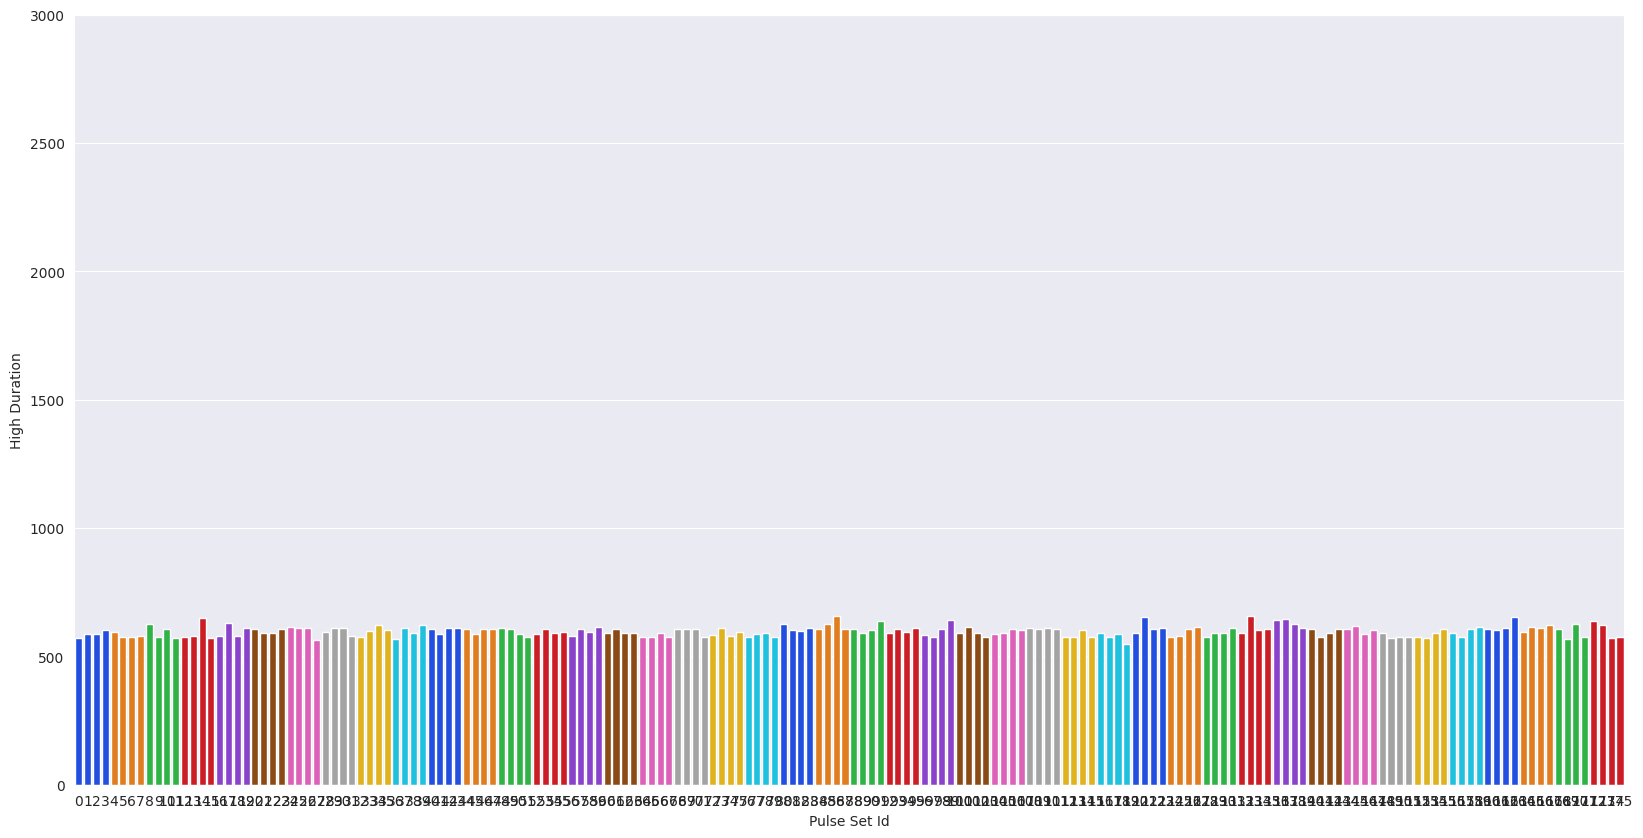

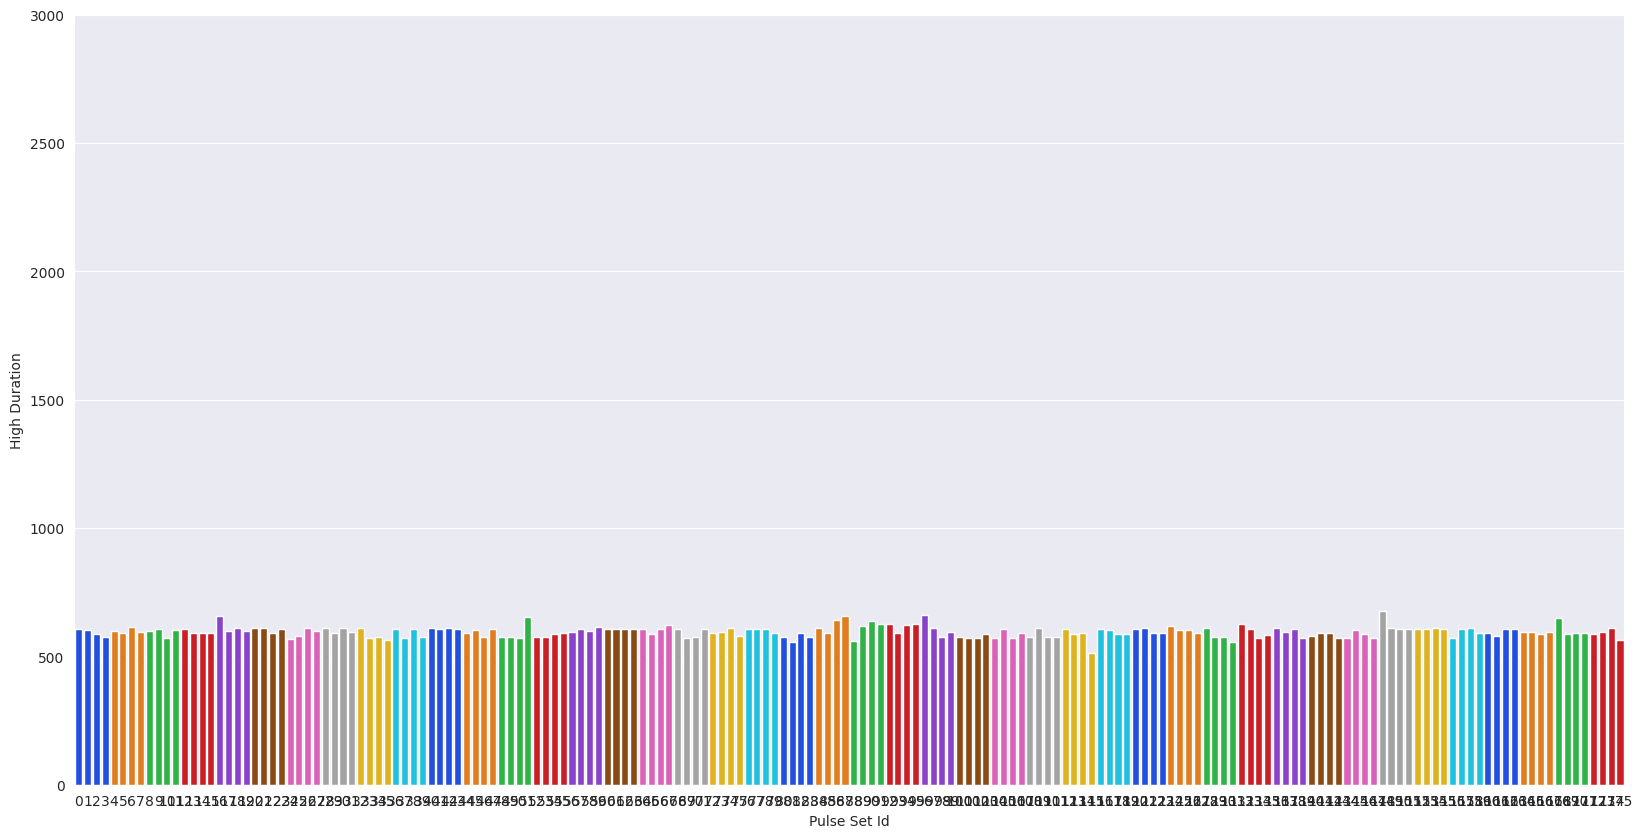

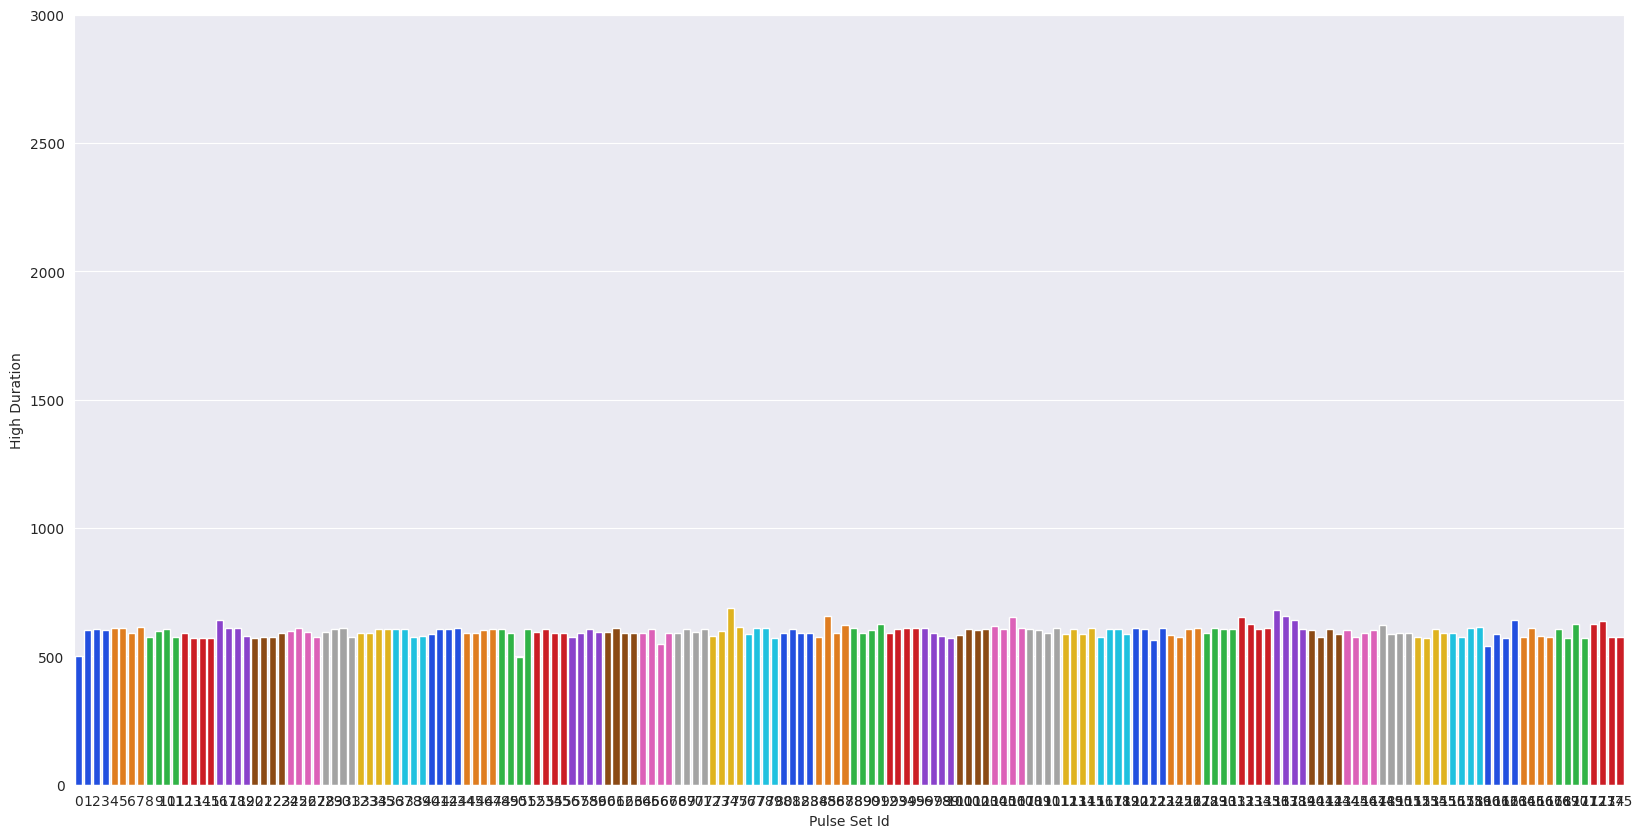

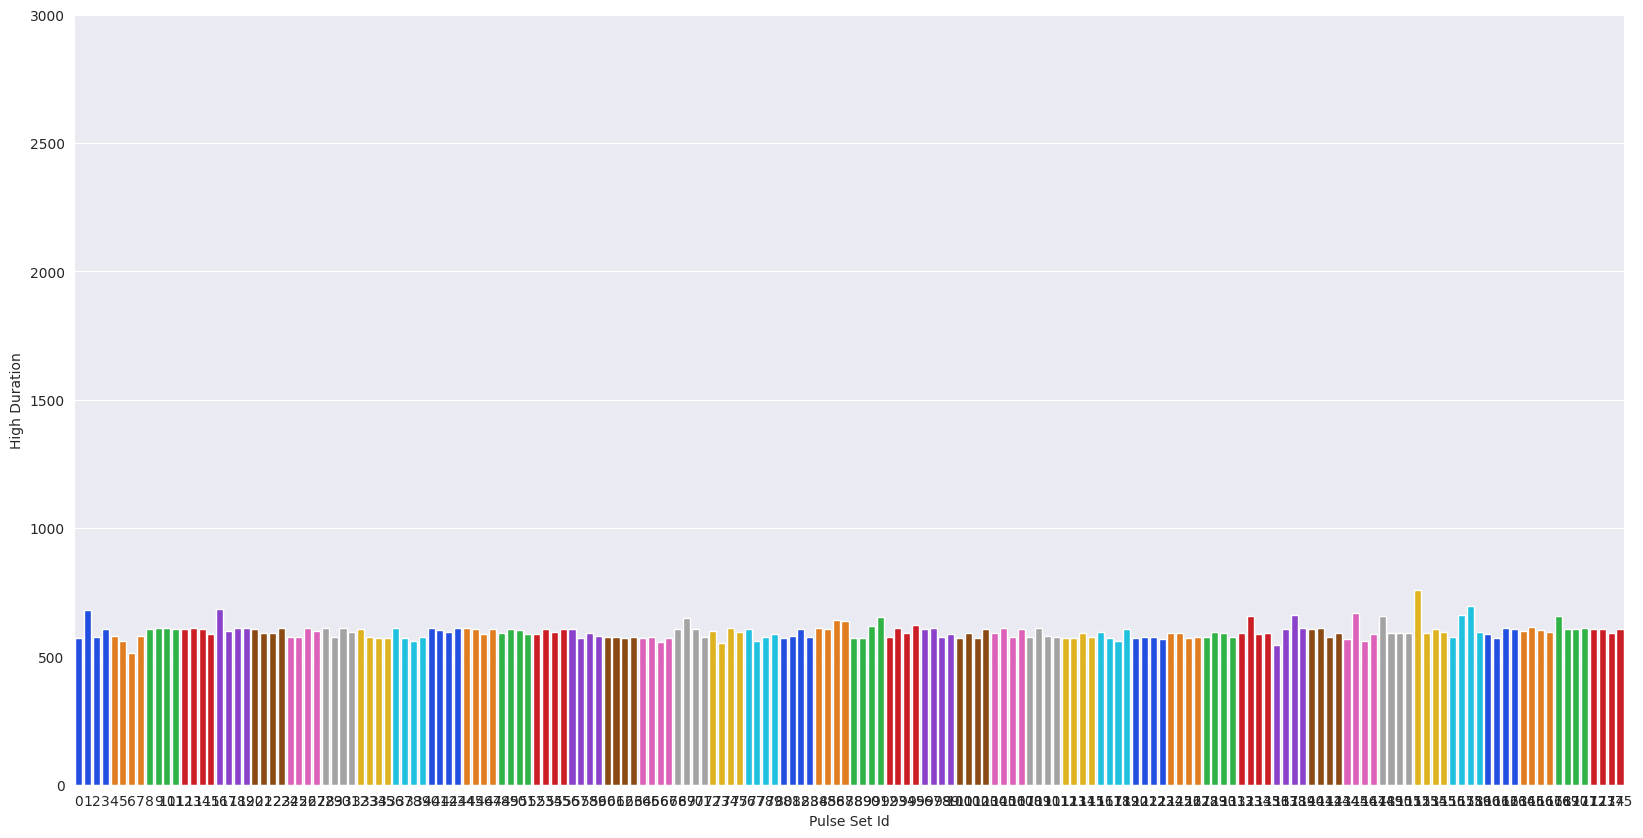

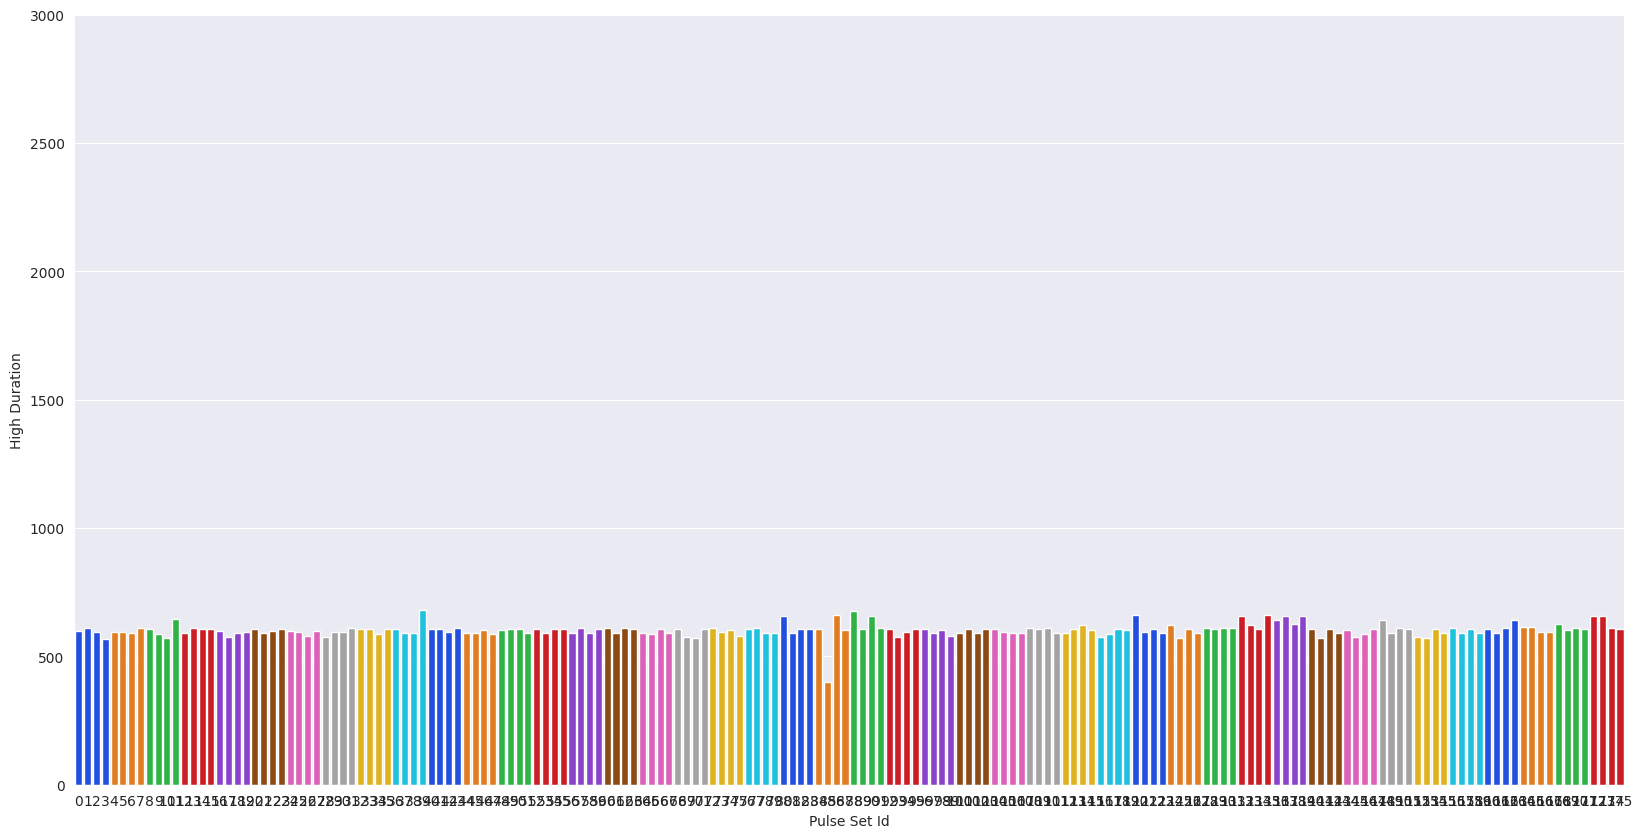

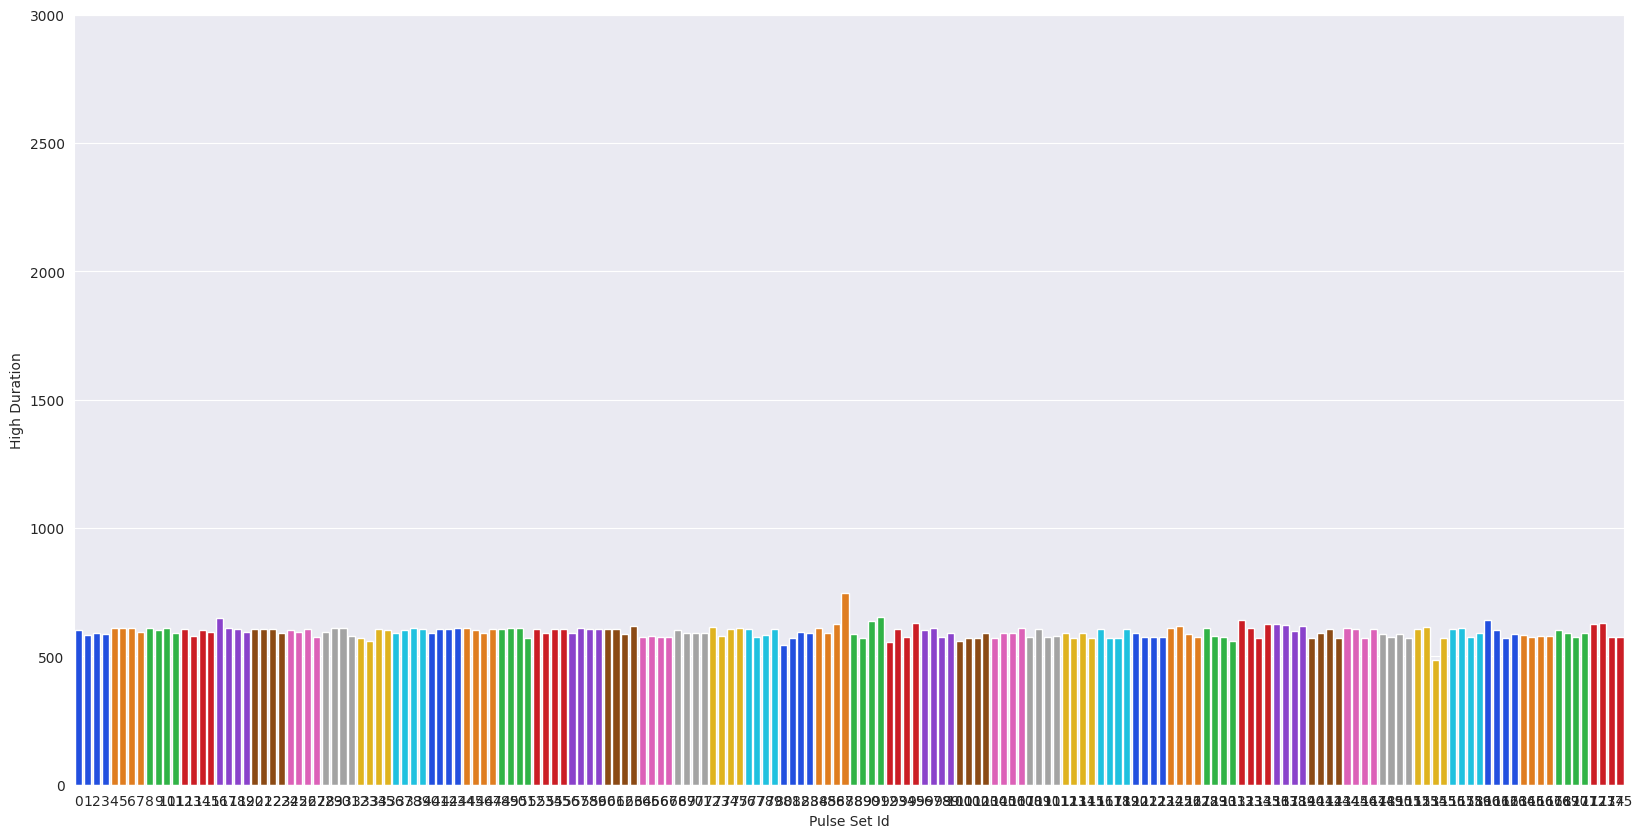

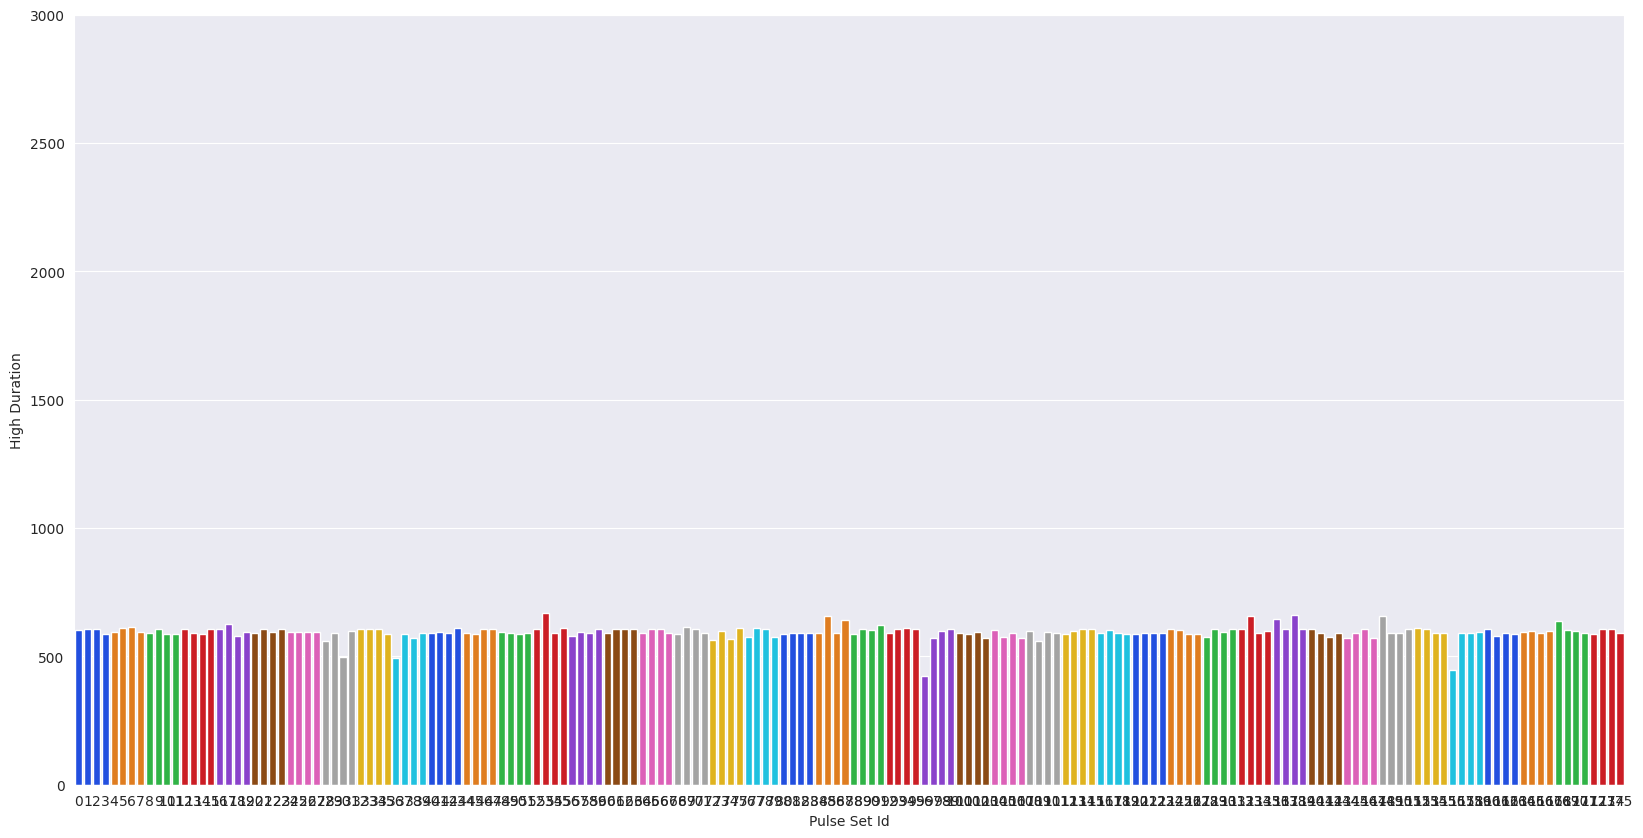

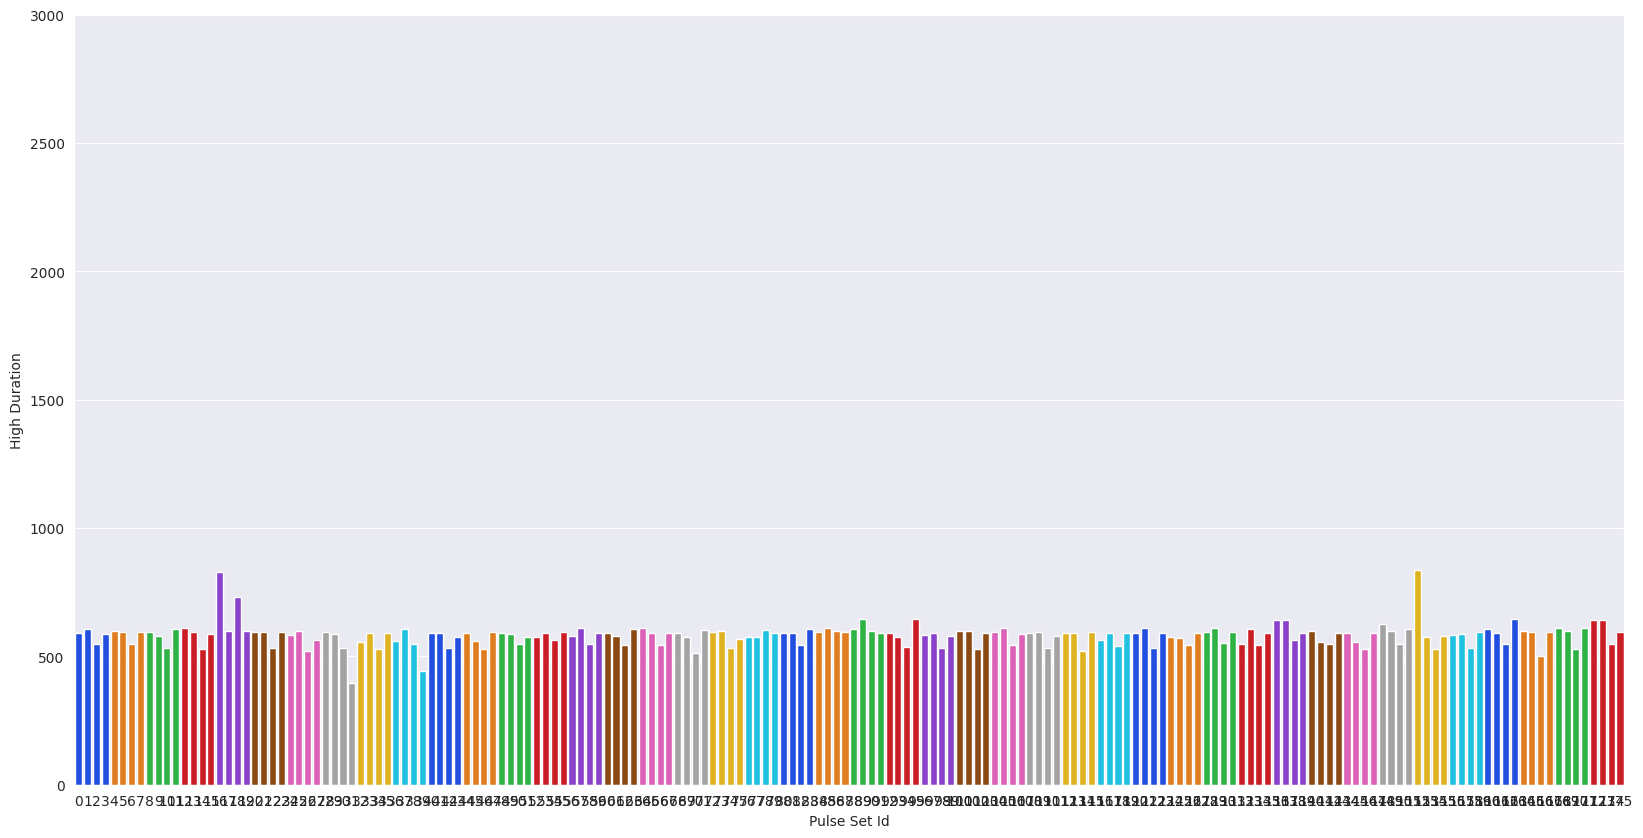

In [38]:

for i in df["Pulse Index"].unique():
    plt.figure(figsize=(20, 10))
    sns.barplot(df[df["Pulse Index"].apply(lambda x: x == i)], x="Pulse Set Id", y="High Duration", hue="Expected Button Group", palette="bright")
    plt.gca().set_ylim(0, 3000)
    plt.gca().get_legend().remove()
    plt.show()

In [61]:
df["Low Category"] = df["Low Duration"].apply(lambda x: 0 if x < 1000 else 1)

In [62]:
gp = df.pivot(index="Pulse Set Id", columns="Pulse Index", values="Low Category")

<Axes: xlabel='Pulse Index', ylabel='Pulse Set Id'>

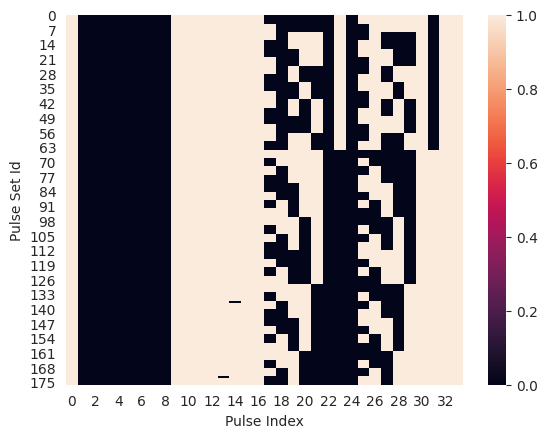

In [63]:
sns.heatmap(gp)